In [8]:
"""
RG-consistent block scan skeleton.

You already have most primitives in your runs:
- Bavg(U), force_norm(U), alignment_score(U)
- lambda_min_phys(U)  (Lanczos on projected Hessian)
- block2x(U) or your block map
- plaquette_avg(U)
"""

import numpy as np
import pandas as pd

def plaquette_avg(U): ...
def Bavg(U): ...
def force_norm(U): ...
def alignment_score(U): ...
def lambda_min_phys(U): ...
def phi_proxy_from_lammins(lammins, kappa_star=0.5):
    lammins = np.asarray(lammins)
    return np.maximum(0.0, kappa_star - lammins).mean()

def block2x(U): ...
def set_beta(beta): ...  # if your code uses global beta in action/Hessian

def calibrate_beta_match(U_fine, U_block, beta_fine):
    """
    Minimal “match plaquette” calibration.
    Solve for beta_match such that <P>_block(beta_match) ~= <P>_fine(beta_fine).
    If you have a faster proxy, use it.
    """
    target = plaquette_avg(U_fine)
    # crude 1D search (replace with something smarter)
    betas = np.linspace(0.5*beta_fine, 2.0*beta_fine, 25)
    errs = []
    for b in betas:
        set_beta(b)
        errs.append(abs(plaquette_avg(U_block) - target))
    return float(betas[int(np.argmin(errs))])

def scan(configs, beta_fine, kappa_star=0.5):
    rows = []
    for i, U in enumerate(configs):
        # fine
        lam_f = lambda_min_phys(U)
        phi_f = max(0.0, kappa_star - lam_f)
        row = {
            "i": i,
            "Bavg": Bavg(U),
            "force": force_norm(U),
            "align": alignment_score(U),
            "lam_fine": lam_f,
            "phi_fine": phi_f,
        }

        Uc = block2x(U)

        # three beta choices
        beta_naive = beta_fine
        beta_match = calibrate_beta_match(U, Uc, beta_fine)
        beta_1loop = beta_fine  # <-- plug your formula

        for tag, beta_c in [("naive", beta_naive), ("match", beta_match), ("1loop", beta_1loop)]:
            set_beta(beta_c)
            lam_c = lambda_min_phys(Uc)
            phi_c = max(0.0, kappa_star - lam_c)
            rows.append({
                **row,
                "beta_choice": tag,
                "beta_coarse": beta_c,
                "lam_block": lam_c,
                "phi_block": phi_c,
                "DeltaPhi": phi_c - phi_f,
            })

    return pd.DataFrame(rows)

# After you run:
# df = scan(configs, beta_fine=..., kappa_star=0.5)
# plot df grouped by beta_choice; correlate DeltaPhi with (Bavg, align, force).

In [9]:
# ============================================================
# COHERENCE SWEEP v2 (GOLDEN PIPELINES, FLOAT64/COMPLEX128)
# AUTO-RETRY ON CPU WHEN CUDA OOM OCCURS
#
# FIX vs prior version:
#   κ extraction is now FLOOR-TRUNCATED per direction:
#     - We keep p=0 mode (same kernel as your proven L=64 run)
#     - But we truncate the ray at r_stop where |G(r)| falls near the known constant floor:
#         floor = 1/(m^2 L^d)
#       Only radii with |G(r)| >= floor_mult * floor are used.
#     - Then we run your SAME corrected-slopes estimator on that truncated ray,
#       and take plateau = median(second half) on the surviving slope windows.
#
# Print-only. No CSV. No drift.
# ============================================================

import math, gc
import numpy as np
import torch
import torch.fft as tfft
import pandas as pd

# --------------------------
# USER CONFIG
# --------------------------
Ls = [64, 96, 128]
m2_list = [0.1, 0.2, 0.3]
d = 4
alpha = 1.0

# κ estimator params (your proven structure)
rmin = 6
W = 6

# Floor truncation strength (principled knob)
# Larger -> truncates earlier (safer from floor but fewer windows)
# Smaller -> truncates later (more windows but more floor contamination)
floor_mult = 30.0

device_gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_cpu = torch.device("cpu")

real = torch.float64
cplx = torch.complex128

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU mem free/total: {free_b/2**30:.2f} GiB / {total_b/2**30:.2f} GiB")

def arcosh(x):
    return math.log(x + math.sqrt(x*x - 1.0))

def compute_DE(d):
    return 6*(d-1)

DE = compute_DE(d)

def clear_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def hat1d(L, dev):
    freq = tfft.fftfreq(L, d=1.0).to(device=dev, dtype=real)
    p1d = 2.0 * math.pi * freq
    return 2.0 * torch.sin(p1d/2.0)

def hat_view(h1, mu, L, dev):
    shape = [1]*d
    shape[mu] = L
    return h1.to(dev).view(*shape).expand(*([L]*d))

def build_p2(h1, L, dev):
    p2 = torch.zeros((L,)*d, device=dev, dtype=real)
    for mu in range(d):
        h = hat_view(h1, mu, L, dev)
        p2 = p2 + h*h
    return p2

def corrected_slopes_from_vals(vals, L, d, rmin=6, W=6):
    """
    Your same estimator:
      y(r)=log|G(r)| + 0.5*(d-1)*log(r)
      m(R)= -mean( y[R+1..R+W] - y[R..R+W-1] )
    """
    rmax = len(vals) - 1
    if rmax <= rmin + W + 2:
        return np.array([]), np.array([])

    r = np.arange(len(vals), dtype=float)
    y = np.log(np.abs(vals) + 1e-300) + 0.5*(d-1)*np.log(np.maximum(r, 1.0))

    Rs, ms = [], []
    for R in range(rmin, rmax - W):
        dy = y[R+1:R+W+1] - y[R:R+W]
        Rs.append(R); ms.append(-np.mean(dy))
    return np.array(Rs), np.array(ms)

def gather_ray_from_4d(G4, step, L, rmax):
    step = np.array(step, dtype=int)
    rr = torch.arange(rmax+1, device=G4.device, dtype=torch.int64)
    idx = [(rr * int(step[mu])) % L for mu in range(d)]
    vals = G4[idx[0], idx[1], idx[2], idx[3]]
    return vals.detach().cpu().numpy().astype(np.float64)

# --------------------------
# Pipeline A: C0(Delta1) streamed + ratio0 (symbol mean)
# --------------------------
def C0_Delta1(L, h1, p2, dev):
    C0 = 0.0
    for mu in range(d):
        row_sum = 0.0
        diag_origin_abs = None
        hmu = hat_view(h1, mu, L, dev)
        for nu in range(d):
            hnu = hat_view(h1, nu, L, dev)
            symQ = (p2 if mu == nu else 0.0) - (hmu*hnu)
            if mu == nu:
                diag_origin_abs = float(torch.abs(torch.mean(symQ)).item())
            K = tfft.ifftn(symQ.to(dtype=cplx)).real.to(dtype=real)
            row_sum += float(torch.sum(torch.abs(K)).item())
            del hnu, symQ, K
        row_sum -= diag_origin_abs
        C0 = max(C0, row_sum)
        del hmu
        if dev.type == "cuda":
            clear_cuda()
    return float(C0)

def ratio_dist0(L, m2, h1, p2, dev):
    mask = p2 > 0
    p2_safe = torch.where(mask, p2, torch.ones_like(p2))

    inv_trans = 1.0 / (m2 + alpha*p2)
    inv_long  = 1.0 / m2
    diff = inv_long - inv_trans

    h0 = hat_view(h1, 0, L, dev)

    def mean_Minv_mu0(mu):
        hmu = hat_view(h1, mu, L, dev)
        if mu == 0:
            sym = inv_trans + torch.where(mask, diff * (h0*h0/p2_safe), torch.zeros_like(p2))
        else:
            sym = torch.where(mask, diff * (hmu*h0/p2_safe), torch.zeros_like(p2))
        out = float(torch.abs(torch.mean(sym)).item())
        del hmu, sym
        return out

    mx = max(mean_Minv_mu0(mu) for mu in range(d))
    del inv_trans, diff, h0, p2_safe, mask
    if dev.type == "cuda":
        clear_cuda()
    return float((m2/2.0) * mx)

# --------------------------
# Pipeline B: scalar κ plateau with FLOOR TRUNCATION (the fix)
# --------------------------
def scalar_kappa_floor_trunc(L, p2, dev, m2):
    inv_trans = 1.0 / (m2 + alpha*p2)
    G4 = tfft.ifftn(inv_trans.to(dtype=cplx)).real.to(dtype=real)
    del inv_trans
    if dev.type == "cuda":
        clear_cuda()

    kexp = arcosh(1.0 + m2/(2.0*alpha))
    rmax_nom = (L//2) - W - 1

    floor = 1.0 / (m2 * (L**d))
    thresh = floor_mult * floor

    dirs = {
        "axis":  (1,0,0,0),
        "diag2": (1,1,0,0),
        "diag3": (1,1,1,0),
        "diag4": (1,1,1,1),
    }

    out = {"kappa_expected": kexp, "floor": floor, "thresh": thresh}

    for name, step in dirs.items():
        vals_full = gather_ray_from_4d(G4, step, L, rmax_nom)   # r=0..rmax_nom

        # find last r above threshold
        good = np.where(np.abs(vals_full) >= thresh)[0]
        if good.size == 0:
            out[f"kappa_{name}"] = float("nan")
            out[f"nwin_{name}"] = 0
            out[f"r_stop_{name}"] = -1
            continue

        r_stop = int(good.max())

        # need room for W-step windows; truncate ray
        rmax_use = min(rmax_nom, r_stop)
        vals = vals_full[:rmax_use+1]

        Rs, ms = corrected_slopes_from_vals(vals, L, d, rmin=rmin, W=W)

        plateau = float(np.median(ms[len(ms)//2:])) if ms.size else float("nan")

        out[f"kappa_{name}"] = plateau
        out[f"nwin_{name}"] = int(ms.size)
        out[f"r_stop_{name}"] = r_stop

    out["abs_err_axis"] = abs(out["kappa_axis"] - kexp) if np.isfinite(out.get("kappa_axis", np.nan)) else float("inf")

    del G4
    if dev.type == "cuda":
        clear_cuda()
    return out

# ============================================================
# RUN ONE L WITH AUTO-RETRY
# ============================================================
def run_one_L(L):
    for dev in ([device_gpu] if device_gpu.type == "cuda" else []) + [device_cpu]:
        try:
            print(f"--- L={L}: backend {dev} ---")
            if dev.type == "cuda":
                clear_cuda()

            h1 = hat1d(L, dev)
            p2 = build_p2(h1, L, dev)

            C0 = C0_Delta1(L, h1, p2, dev)

            out_rows = []
            for m2 in m2_list:
                eta = 2.0 * math.asinh(math.sqrt(m2) / (2.0 * math.sqrt(alpha * C0)))
                ratio0 = ratio_dist0(L, m2, h1, p2, dev)
                krec = scalar_kappa_floor_trunc(L, p2, dev, m2)

                out_rows.append(dict(
                    L=L, backend=str(dev), m2=m2,
                    C0=C0, eta_DG_C0=eta, max_ratio_dist0=ratio0,
                    **krec
                ))

            del h1, p2
            if dev.type == "cuda":
                clear_cuda()
            return out_rows

        except torch.OutOfMemoryError:
            print(f"OOM on {dev} at L={L} -> retrying on CPU")
            if dev.type == "cuda":
                clear_cuda()
            continue

    raise RuntimeError(f"Both CUDA and CPU failed at L={L} (unexpected).")

# ============================================================
# RUN SWEEP
# ============================================================
rows = []
for L in Ls:
    rows.extend(run_one_L(L))

df = pd.DataFrame(rows).sort_values(["L","m2"]).reset_index(drop=True)

cols = [
    "L","backend","m2","C0","eta_DG_C0","max_ratio_dist0",
    "kappa_expected","kappa_axis","abs_err_axis","nwin_axis","r_stop_axis",
    "kappa_diag2","nwin_diag2","r_stop_diag2",
    "kappa_diag3","nwin_diag3","r_stop_diag3",
    "kappa_diag4","nwin_diag4","r_stop_diag4",
]

print("\n=== COHERENCE SWEEP v2 (floor-truncated κ) ===")
with pd.option_context("display.width", 260, "display.max_columns", 200):
    print(df[cols])

print("\nNOTE: floor_mult =", floor_mult, "| rmin =", rmin, "| W =", W)

GPU available: True
GPU mem free/total: 78.90 GiB / 79.32 GiB
--- L=64: backend cuda ---
--- L=96: backend cuda ---
--- L=128: backend cuda ---

=== COHERENCE SWEEP v2 (floor-truncated κ) ===
     L backend   m2          C0  eta_DG_C0  max_ratio_dist0  kappa_expected  kappa_axis  abs_err_axis  nwin_axis  r_stop_axis  kappa_diag2  nwin_diag2  r_stop_diag2  kappa_diag3  nwin_diag3  r_stop_diag3  kappa_diag4  nwin_diag4  r_stop_diag4
0   64    cuda  0.1   87.298902   0.033843         0.130643        0.314925         NaN           inf          0           10          NaN           0             7          NaN           0             6          NaN           0             5
1   64    cuda  0.2   87.298902   0.047860         0.136024        0.443568         NaN           inf          0           10          NaN           0             6          NaN           0             5          NaN           0             4
2   64    cuda  0.3   87.298902   0.058613         0.141185        0.541097    

In [10]:
import time
import jax
import jax.numpy as jnp
import jax.scipy.linalg as jsp
from functools import partial

def banner(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}", flush=True)

# -----------------------
# SU(N) helpers
# -----------------------
def haar_suN(key, shape, N, dtype=jnp.complex64):
    k1, k2 = jax.random.split(key)
    z = (jax.random.normal(k1, shape + (N, N), dtype=jnp.float32)
         + 1j * jax.random.normal(k2, shape + (N, N), dtype=jnp.float32)) / jnp.sqrt(2.0)
    z = z.astype(dtype)
    q, r = jnp.linalg.qr(z)
    phase = jnp.exp(-1j * jnp.angle(jnp.diagonal(r, axis1=-2, axis2=-1)))
    q = q * phase[..., None, :]
    detq = jnp.linalg.det(q)
    q = q / detq[..., None, None] ** (1.0 / N)
    return q

def suN_tangent_gaussian(key, shape, N, dtype=jnp.complex64):
    k1, k2 = jax.random.split(key)
    a = (jax.random.normal(k1, shape + (N, N), dtype=jnp.float32)
         + 1j * jax.random.normal(k2, shape + (N, N), dtype=jnp.float32)) / jnp.sqrt(2.0)
    a = a.astype(dtype)
    x = a - jnp.conjugate(jnp.swapaxes(a, -1, -2))   # anti-Hermitian
    tr = jnp.trace(x, axis1=-2, axis2=-1) / N
    x = x - tr[..., None, None] * jnp.eye(N, dtype=dtype)  # traceless
    return x

def shift4(arr, axis, s):
    return jnp.roll(arr, shift=s, axis=axis)

def plaquette(U, mu, nu):
    # U: [L,L,L,L,4,N,N]
    U_mu = U[..., mu, :, :]
    U_nu = U[..., nu, :, :]
    U_mu_x_nu = shift4(U_mu, axis=nu, s=1)
    U_nu_x_mu = shift4(U_nu, axis=mu, s=1)
    U_mu_dag_x_nu = jnp.conjugate(jnp.swapaxes(U_mu_x_nu, -1, -2))
    U_nu_dag = jnp.conjugate(jnp.swapaxes(U_nu, -1, -2))
    return U_mu @ U_nu_x_mu @ U_mu_dag_x_nu @ U_nu_dag

def z_stack(U):
    N = U.shape[-1]
    z_list = []
    for mu in range(4):
        for nu in range(mu+1, 4):
            Up = plaquette(U, mu, nu)
            tr = jnp.real(jnp.trace(Up, axis1=-2, axis2=-1))
            z = 1.0 - (1.0 / N) * tr
            z_list.append(z)
    return jnp.stack(z_list, axis=0)  # [6,L,L,L,L]

def zsum_and_Vbar(U):
    z_all = z_stack(U)
    z_sum = jnp.sum(z_all)
    V = 1.0 + jnp.mean(z_all)
    return z_sum, V

def estimate_LV_one(U, beta, eps, mc_samples, key):
    # finite-diff estimator of L Vbar = Lap(Vbar) - <grad S, grad Vbar>
    L = U.shape[0]
    N = U.shape[-1]

    def one_dir(k):
        Xi = suN_tangent_gaussian(k, (L, L, L, L, 4), N, dtype=U.dtype)
        exp_p = jsp.expm(eps * Xi)
        exp_m = jsp.expm(-eps * Xi)
        U_p = U @ exp_p
        U_m = U @ exp_m

        zsum_p, V_p = zsum_and_Vbar(U_p)
        _,      V_0 = zsum_and_Vbar(U)
        zsum_m, V_m = zsum_and_Vbar(U_m)

        lap = (V_p + V_m - 2.0 * V_0) / (eps ** 2)

        # drift term
        S_p = beta * zsum_p
        S_m = beta * zsum_m
        dS = (S_p - S_m) / (2.0 * eps)
        dV = (V_p - V_m) / (2.0 * eps)
        return lap - dS * dV

    keys = jax.random.split(key, mc_samples)
    vals = jax.vmap(one_dir)(keys)
    return jnp.mean(vals), jnp.std(vals) / jnp.sqrt(mc_samples)

def sample_batch(key, N=3, L=2, K=32, beta=6.0, eps=5e-3, mc=64):
    key, kU, kL = jax.random.split(key, 3)
    keysU = jax.random.split(kU, K)
    keysL = jax.random.split(kL, K)

    def one(kU_i, kL_i):
        U = haar_suN(kU_i, (L, L, L, L, 4), N)
        _, V = zsum_and_Vbar(U)
        LV, se = estimate_LV_one(U, beta=beta, eps=eps, mc_samples=mc, key=kL_i)
        return V, LV, se

    return jax.vmap(one)(keysU, keysL)

def fit_lambda_b(V, LV):
    # Fit LV ≈ -lambda * V + b  (least squares)
    X = jnp.stack([V, jnp.ones_like(V)], axis=1)  # [K,2]
    y = LV
    coef, *_ = jnp.linalg.lstsq(X, y, rcond=None)
    a = coef[0]     # a ≈ -lambda
    b = coef[1]
    lam = -a
    return lam, b

def report_fit_and_holdout(seed=0, N=3, L=2, beta=6.0, eps=5e-3, mc=64, K_fit=32, K_test=32):
    banner(f"JAX devices: {jax.devices()}")
    banner("Sampling FIT batch...")
    key = jax.random.PRNGKey(seed)
    V_fit, LV_fit, se_fit = sample_batch(key, N=N, L=L, K=K_fit, beta=beta, eps=eps, mc=mc)

    # materialize now (helps with timing + makes sure we're not silently compiling later)
    V_fit, LV_fit, se_fit = jax.device_get((V_fit, LV_fit, se_fit))

    lam, b = fit_lambda_b(jnp.array(V_fit), jnp.array(LV_fit))
    lam, b = float(lam), float(b)

    banner("FIT results")
    print(f"  N={N}, L={L}, beta={beta}, eps={eps}, mc={mc}, K_fit={K_fit}", flush=True)
    print(f"  Fitted: lambda ≈ {lam:.6g},  b ≈ {b:.6g}", flush=True)
    print(f"  V range: [{float(V_fit.min()):.6g}, {float(V_fit.max()):.6g}]", flush=True)
    print(f"  LV range:[{float(LV_fit.min()):.6g}, {float(LV_fit.max()):.6g}]", flush=True)

    banner("Sampling HOLDOUT batch...")
    key2 = jax.random.PRNGKey(seed + 1)
    V_t, LV_t, se_t = sample_batch(key2, N=N, L=L, K=K_test, beta=beta, eps=eps, mc=mc)
    V_t, LV_t, se_t = jax.device_get((V_t, LV_t, se_t))

    rhs = -lam * V_t + b
    diff = LV_t - rhs  # should be <= 0

    # count violations at different sigma margins
    v0 = int(jnp.sum(diff > 0.0))
    v2 = int(jnp.sum(diff > 2.0 * se_t))
    v5 = int(jnp.sum(diff > 5.0 * se_t))

    banner("HOLDOUT check: LV <= -lambda V + b")
    print(f"  K_test={K_test}", flush=True)
    print(f"  Violations (no margin): {v0}/{K_test}", flush=True)
    print(f"  Violations (>2σ):       {v2}/{K_test}", flush=True)
    print(f"  Violations (>5σ):       {v5}/{K_test}", flush=True)
    print(f"  Worst diff = max(LV - RHS) ≈ {float(diff.max()):.6g}", flush=True)

# -----------------------
# RUN IT (this is the part people forget)
# -----------------------
banner("About to run drift fit + holdout (this will print).")
report_fit_and_holdout(seed=0, N=3, L=2, beta=6.0, eps=5e-3, mc=64, K_fit=32, K_test=32)
banner("Done.")

[06:17:29] About to run drift fit + holdout (this will print).
[06:17:30] JAX devices: [CudaDevice(id=0)]
[06:17:30] Sampling FIT batch...
[06:17:40] FIT results
  N=3, L=2, beta=6.0, eps=0.005, mc=64, K_fit=32
  Fitted: lambda ≈ -10.5163,  b ≈ -27.9709
  V range: [1.95139, 2.03222]
  LV range:[-8.96473, -4.21079]
[06:17:40] Sampling HOLDOUT batch...
[06:17:41] HOLDOUT check: LV <= -lambda V + b
  K_test=32
  Violations (no margin): 20/32
  Violations (>2σ):       6/32
  Violations (>5σ):       0/32
  Worst diff = max(LV - RHS) ≈ 2.79207
[06:17:41] Done.


[device] CUDA: NVIDIA A100-SXM4-80GB  VRAM=79.3 GB

CONFIG
L=12  K_total=2048 (fit=1024, holdout=1024)
beta=6.0  eps_fd=0.005  mc=256  mc_chunk=4
sigma_list=[0.0, 0.1, 0.2, 0.4, 0.8, 1.6]  frac_haar=0.25
U dtype=torch.float64  Xi dtype=torch.float32  device=cuda
[1/5] dataset built: U.shape=(2048, 12, 12, 12, 12, 4, 4)  (0.29s)
[2/5] alignment computed (0.18s)

[OOM] CUDA out of memory. Downshifting and retrying...
[OOM] New mc_chunk=2

CONFIG
L=12  K_total=2048 (fit=1024, holdout=1024)
beta=6.0  eps_fd=0.005  mc=256  mc_chunk=2
sigma_list=[0.0, 0.1, 0.2, 0.4, 0.8, 1.6]  frac_haar=0.25
U dtype=torch.float64  Xi dtype=torch.float32  device=cuda
[1/5] dataset built: U.shape=(2048, 12, 12, 12, 12, 4, 4)  (0.36s)
[2/5] alignment computed (0.03s)

[OOM] CUDA out of memory. Downshifting and retrying...
[OOM] New mc_chunk=1

CONFIG
L=12  K_total=2048 (fit=1024, holdout=1024)
beta=6.0  eps_fd=0.005  mc=256  mc_chunk=1
sigma_list=[0.0, 0.1, 0.2, 0.4, 0.8, 1.6]  frac_haar=0.25
U dtype=torch.floa

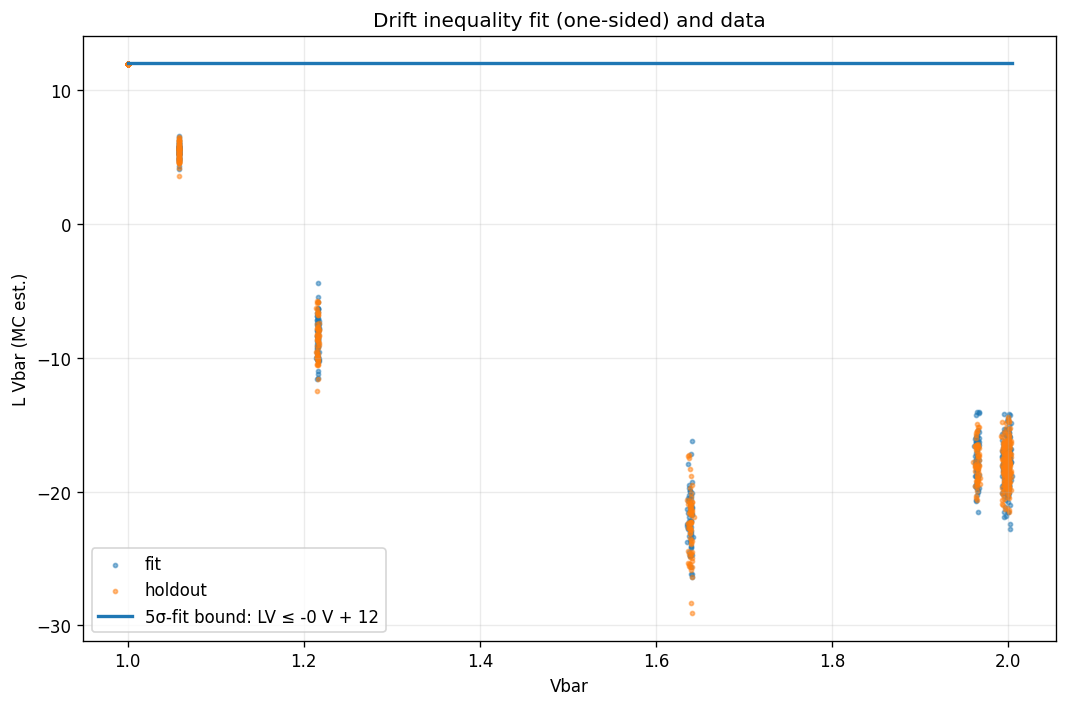


[CUDA] Peak allocated memory: 13.14 GB

[done] Paste the printed output back here and I’ll interpret it against your earlier runs.


In [11]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# SU(2) 4D DRIFT INEQUALITY + CORRELATION MEGA-RUN (A100)
# ============================================================
# What you get:
#   - Wide-range dataset of SU(2) gauge fields U on a 4D torus (L^4):
#       * near-identity draws U = exp(sigma * Xi) for several sigma
#       * Haar draws (uniform on SU(2))
#   - Per-configuration Monte Carlo estimate of:
#       Vbar = 1 + mean_plaquettes(1 - a_p)      (a_p = real part of plaquette quaternion)
#       L Vbar using finite-difference generator estimator:
#           Lf ~= E[ (f(Ue^{eXi}) + f(Ue^{-eXi}) - 2f(U))/e^2  -  (D_Xi S)(D_Xi f) ]
#   - Extra "free" moment proxies from the same MC directions:
#       lap term, <grad S, grad V> proxy, ||grad S|| proxy, ||grad V|| proxy
#   - Cartan alignment score (are link imaginaries mostly colinear in R^3?)
#   - One-sided fit of drift inequality with margins:
#       LV <= -lambda * V + b
#     using fit-set constraints at margin = 0σ, 2σ, 5σ
#   - Holdout violation counts at 0σ, 2σ, 5σ
#   - Correlation matrix of key metrics
#   - Worst holdout offenders under the chosen (5σ-fit) bound
#
# Notes:
#   - This is intentionally "A100 hungry". If your GPU is smaller, it will auto-downshift.
#   - Memory knob is mc_chunk. If OOM, the code reduces mc_chunk first, then K_total.
# ============================================================

# ----------------------------
# USER KNOBS (start aggressive; OOM fallback will downshift automatically)
# ----------------------------
CFG = dict(
    # Big A100-ish defaults:
    L=12,                # 12 is heavy; 16 is *very* heavy
    K_total=2048,        # total configs (fit+holdout)
    K_fit=1024,          # configs used to fit; remainder is holdout

    beta=6.0,            # Wilson coupling inside the generator/drift
    eps_fd=5e-3,         # finite-difference step on the group
    mc=256,              # MC directions per config (higher -> tighter SE)
    mc_chunk=4,          # processed per chunk (MEMORY knob!)

    # Wide-range sampling to spread Vbar beyond the tiny ~[1.95,2.03] band:
    sigma_list=[0.0, 0.1, 0.2, 0.4, 0.8, 1.6],  # non-Haar families U=exp(sigma*Xi)
    frac_haar=0.25,      # fraction Haar-random (uniform SU(2))

    seed=0,
    dtype="float64",     # float64 for "proof-grade" numerics (slower but cleaner)
    xi_dtype="float32",  # tangent Xi in float32 to save huge memory
    plot=True,           # show LV vs V scatter + fitted bound line
)

# ----------------------------
# Device / dtype
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"[device] CUDA: {props.name}  VRAM={props.total_memory/2**30:.1f} GB", flush=True)
else:
    print("[device] CPU (no CUDA detected)", flush=True)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

DTYPE = torch.float64 if CFG["dtype"].lower() == "float64" else torch.float32
XI_DTYPE = torch.float32 if CFG["xi_dtype"].lower() == "float32" else DTYPE

# ----------------------------
# SU(2) quaternion ops
# quaternion q = (a,b,c,d), unit norm
# ----------------------------
def su2_normalize(q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return q / q.pow(2).sum(dim=-1, keepdim=True).clamp_min(eps).sqrt()

def su2_conj(q: torch.Tensor) -> torch.Tensor:
    a, b, c, d = q.unbind(-1)
    return torch.stack([a, -b, -c, -d], dim=-1)

def su2_mul(q1: torch.Tensor, q2: torch.Tensor) -> torch.Tensor:
    a1, b1, c1, d1 = q1.unbind(-1)
    a2, b2, c2, d2 = q2.unbind(-1)
    return torch.stack(
        [
            a1 * a2 - b1 * b2 - c1 * c2 - d1 * d2,
            a1 * b2 + b1 * a2 + c1 * d2 - d1 * c2,
            a1 * c2 - b1 * d2 + c1 * a2 + d1 * b2,
            a1 * d2 + b1 * c2 - c1 * b2 + d1 * a2,
        ],
        dim=-1,
    )

def su2_exp(v: torch.Tensor) -> torch.Tensor:
    """
    Exponential map su(2)~R^3 -> SU(2)~S^3 in quaternion coords.
    v shape (...,3) -> q shape (...,4).
    """
    theta = torch.linalg.norm(v, dim=-1, keepdim=True)
    a = torch.cos(theta)
    theta2 = theta * theta
    sinc = torch.where(theta > 1e-8, torch.sin(theta) / theta, 1.0 - theta2 / 6.0 + theta2 * theta2 / 120.0)
    vec = sinc * v
    return torch.cat([a, vec], dim=-1)

# ----------------------------
# Lattice plaquettes + observables
# U shape: (B, L,L,L,L, d=4, 4)
# ----------------------------
def plaquette(U: torch.Tensor, mu: int, nu: int) -> torch.Tensor:
    """
    P_mu,nu(x) = U_mu(x) U_nu(x+mu) U_mu(x+nu)^-1 U_nu(x)^-1
    """
    U_mu = U[..., mu, :]  # (B, L,L,L,L, 4)
    U_nu = U[..., nu, :]
    U_nu_x_plus_mu = torch.roll(U_nu, shifts=-1, dims=1 + mu)
    U_mu_x_plus_nu = torch.roll(U_mu, shifts=-1, dims=1 + nu)
    return su2_mul(su2_mul(su2_mul(U_mu, U_nu_x_plus_mu), su2_conj(U_mu_x_plus_nu)), su2_conj(U_nu))

@torch.no_grad()
def wilson_action_Vbar_Bavg(U: torch.Tensor, beta: float):
    """
    S = beta * sum_p (1 - a_p)
    Bavg = mean_p(1 - a_p)
    Vbar = 1 + Bavg
    """
    B = U.shape[0]
    d = U.shape[-2]
    defect_sum = torch.zeros((B,), device=U.device, dtype=U.dtype)
    defect_mean_sum = torch.zeros((B,), device=U.device, dtype=U.dtype)
    count = 0
    for mu in range(d):
        for nu in range(mu + 1, d):
            P = plaquette(U, mu, nu)
            defect = 1.0 - P[..., 0]
            defect_sum += defect.sum(dim=(1, 2, 3, 4))
            defect_mean_sum += defect.mean(dim=(1, 2, 3, 4))
            count += 1
    Bavg = defect_mean_sum / float(count)
    Vbar = 1.0 + Bavg
    S = beta * defect_sum
    return S, Vbar, Bavg

@torch.no_grad()
def cartan_alignment_score(U: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    Score in [0,1]:
      - take imaginary parts v in R^3 for all links
      - C = (sum v v^T) / (sum |v|^2)
      - if perfectly colinear => eigenvalues ~ (1,0,0)
    score = 1 - lambda_max(C); score ~ 0 => strongly Cartan-aligned.
    """
    v = U[..., 1:]  # (B, L,L,L,L, d, 3)
    B = v.shape[0]
    v_flat = v.reshape(B, -1, 3)
    num = torch.einsum("bni,bnj->bij", v_flat, v_flat)
    denom = v_flat.pow(2).sum(dim=(1, 2)).view(B, 1, 1).clamp_min(eps)
    C = num / denom
    evals = torch.linalg.eigvalsh(C)  # (B,3)
    lam_max = evals[:, -1]
    mask = (denom[:, 0, 0] <= 10.0 * eps)  # identity-like: treat as aligned => score=0
    return torch.where(mask, torch.zeros_like(lam_max), 1.0 - lam_max)

# ----------------------------
# Generator estimator: LVbar + moments (lap, <gS,gV>, ||gS||, ||gV||)
# ----------------------------
@torch.no_grad()
def estimate_LV_moments_batch(U: torch.Tensor, beta: float, eps_fd: float, mc: int, mc_chunk: int, seed: int):
    assert mc >= 2, "mc must be >=2"
    B, L = U.shape[0], U.shape[1]
    d = U.shape[-2]
    eps = float(eps_fd)

    _, V0, Bavg0 = wilson_action_Vbar_Bavg(U, beta=beta)
    V0 = V0.detach()

    def z(): return torch.zeros((B,), device=U.device, dtype=U.dtype)
    sum_lv, sum_lv2 = z(), z()
    sum_lap, sum_lap2 = z(), z()
    sum_gip, sum_gip2 = z(), z()
    sum_dS2, sum_dS2_2 = z(), z()
    sum_dV2, sum_dV2_2 = z(), z()

    g = torch.Generator(device=U.device)
    g.manual_seed(int(seed))

    processed = 0
    while processed < mc:
        c = int(min(mc_chunk, mc - processed))

        # Xi in float32 for memory (it will promote as needed during su2_mul)
        Xi = torch.randn((B, c, L, L, L, L, d, 3), device=U.device, dtype=XI_DTYPE, generator=g)

        # exp(+eps Xi)
        exp_p = su2_exp(eps * Xi)
        U_base = U.unsqueeze(1)

        U_p = su2_mul(U_base, exp_p)  # promotes to U.dtype
        U_p_f = U_p.reshape(B * c, L, L, L, L, d, 4)
        S_p, V_p, _ = wilson_action_Vbar_Bavg(U_p_f, beta=beta)
        S_p = S_p.view(B, c)
        V_p = V_p.view(B, c)
        del U_p, U_p_f

        # exp(-eps Xi) = conj(exp(+eps Xi))
        exp_m = su2_conj(exp_p)
        U_m = su2_mul(U_base, exp_m)
        U_m_f = U_m.reshape(B * c, L, L, L, L, d, 4)
        S_m, V_m, _ = wilson_action_Vbar_Bavg(U_m_f, beta=beta)
        S_m = S_m.view(B, c)
        V_m = V_m.view(B, c)
        del U_m, U_m_f, exp_p, exp_m, Xi

        V0c = V0.view(B, 1)
        lap = (V_p + V_m - 2.0 * V0c) / (eps * eps)
        dS = (S_p - S_m) / (2.0 * eps)
        dV = (V_p - V_m) / (2.0 * eps)

        gip = dS * dV
        lv = lap - gip

        dS2 = dS * dS
        dV2 = dV * dV

        def acc(sum_, sum2_, x):
            sum_ += x.sum(dim=1)
            sum2_ += (x * x).sum(dim=1)
            return sum_, sum2_

        sum_lv,  sum_lv2   = acc(sum_lv,  sum_lv2,  lv)
        sum_lap, sum_lap2  = acc(sum_lap, sum_lap2, lap)
        sum_gip, sum_gip2  = acc(sum_gip, sum_gip2, gip)
        sum_dS2, sum_dS2_2 = acc(sum_dS2, sum_dS2_2, dS2)
        sum_dV2, sum_dV2_2 = acc(sum_dV2, sum_dV2_2, dV2)

        processed += c

    def mean_se(sum_, sum2_):
        mean = sum_ / float(mc)
        var = (sum2_ - (sum_ * sum_) / float(mc)) / float(mc - 1)
        var = torch.clamp(var, min=0.0)
        se = torch.sqrt(var / float(mc))
        return mean, se

    lv_mean,  lv_se  = mean_se(sum_lv,  sum_lv2)
    lap_mean, lap_se = mean_se(sum_lap, sum_lap2)
    gip_mean, gip_se = mean_se(sum_gip, sum_gip2)
    dS2_mean, dS2_se = mean_se(sum_dS2, sum_dS2_2)
    dV2_mean, dV2_se = mean_se(sum_dV2, sum_dV2_2)

    gradS = torch.sqrt(torch.clamp(dS2_mean, min=0.0))
    gradV = torch.sqrt(torch.clamp(dV2_mean, min=0.0))

    return dict(
        Vbar=V0,
        Bavg=Bavg0,
        LV=lv_mean,
        LV_se=lv_se,
        lap=lap_mean,
        lap_se=lap_se,
        gip=gip_mean,
        gip_se=gip_se,
        gradS_norm=gradS,
        gradS_norm_se=0.5 * dS2_se / torch.sqrt(torch.clamp(dS2_mean, min=1e-30)),
        gradV_norm=gradV,
        gradV_norm_se=0.5 * dV2_se / torch.sqrt(torch.clamp(dV2_mean, min=1e-30)),
    )

# ----------------------------
# Dataset builder
# ----------------------------
@torch.no_grad()
def build_dataset(L: int, K_total: int, sigma_list: list, frac_haar: float, seed: int):
    d = 4
    K_total = int(K_total)
    K_haar = int(round(frac_haar * K_total))
    K_non = K_total - K_haar
    if K_non < 1:
        raise ValueError("Need at least 1 non-Haar sample.")
    if len(sigma_list) < 1:
        raise ValueError("sigma_list must be non-empty.")

    # Split non-Haar evenly across sigma_list
    counts = [K_non // len(sigma_list)] * len(sigma_list)
    for i in range(K_non - sum(counts)):
        counts[i] += 1

    g = torch.Generator(device=device)
    g.manual_seed(int(seed))

    blocks, sigmas, kind_ids = [], [], []

    # Non-Haar: U = exp(sigma * Xi)
    for sigma, k in zip(sigma_list, counts):
        k = int(k)
        if k == 0:
            continue
        Xi = torch.randn((k, L, L, L, L, d, 3), device=device, dtype=XI_DTYPE, generator=g)
        U = su2_exp(float(sigma) * Xi).to(dtype=DTYPE)
        blocks.append(U)
        sigmas.append(torch.full((k,), float(sigma), device=device, dtype=DTYPE))
        kind_ids.append(torch.zeros((k,), device=device, dtype=torch.int64))

    # Haar: random unit quaternions
    if K_haar > 0:
        q = torch.randn((K_haar, L, L, L, L, d, 4), device=device, dtype=DTYPE, generator=g)
        q = su2_normalize(q)
        blocks.append(q)
        sigmas.append(torch.full((K_haar,), float("nan"), device=device, dtype=DTYPE))
        kind_ids.append(torch.ones((K_haar,), device=device, dtype=torch.int64))

    U_all = torch.cat(blocks, dim=0)
    sigma_all = torch.cat(sigmas, dim=0)
    kind_all = torch.cat(kind_ids, dim=0)

    # Shuffle
    perm = torch.randperm(U_all.shape[0], device=device, generator=g)
    return U_all[perm], dict(sigma=sigma_all[perm], kind_id=kind_all[perm])

# ----------------------------
# One-sided drift fit and holdout report
# ----------------------------
@torch.no_grad()
def fit_drift_one_sided(V: torch.Tensor, LV: torch.Tensor, SE: torch.Tensor, margin: float, n_grid: int = 2001):
    """
    Choose lambda>=0 and minimal b such that on FIT set:
      LV_i + margin*SE_i <= -lambda V_i + b  for all i
    For each lambda, minimal b is max_i(LV_i + margin*SE_i + lambda V_i).
    We scan lambda on a grid.
    """
    # OLS slope for scale
    X = torch.stack([V, torch.ones_like(V)], dim=1)
    sol = torch.linalg.lstsq(X, LV.unsqueeze(1)).solution.squeeze()
    a = float(sol[0].item())
    lambda_ols = max(0.0, float(-a))
    lambda_max = max(5.0, 5.0 * (lambda_ols + 1.0))

    lambdas = torch.linspace(0.0, lambda_max, n_grid, device=V.device, dtype=V.dtype)
    rhs = (LV + float(margin) * SE).unsqueeze(0) + lambdas.unsqueeze(1) * V.unsqueeze(0)
    b_vals = rhs.max(dim=1).values
    j = int(torch.argmin(b_vals).item())
    return float(lambdas[j].item()), float(b_vals[j].item())

@torch.no_grad()
def holdout_report(V: torch.Tensor, LV: torch.Tensor, SE: torch.Tensor, lam: float, b: float, ksig_list=(0.0, 2.0, 5.0)):
    out = {}
    for k in ksig_list:
        diff = (LV + float(k) * SE) + float(lam) * V - float(b)   # violation if > 0
        viol = (diff > 0.0)
        out[k] = dict(
            violations=int(viol.sum().item()),
            total=int(V.numel()),
            frac=float(viol.float().mean().item()),
            worst=float(diff.max().item()),
            diff=diff,
            viol_mask=viol,
        )
    return out

# ----------------------------
# Main run (with OOM fallback)
# ----------------------------
def run(cfg: dict):
    L = int(cfg["L"])
    K_total = int(cfg["K_total"])
    K_fit = int(cfg["K_fit"])
    assert 1 <= K_fit < K_total, "Need 1 <= K_fit < K_total"
    beta = float(cfg["beta"])
    eps_fd = float(cfg["eps_fd"])
    mc = int(cfg["mc"])
    mc_chunk = int(cfg["mc_chunk"])
    sigma_list = list(cfg["sigma_list"])
    frac_haar = float(cfg["frac_haar"])
    seed = int(cfg["seed"])

    print("\n============================", flush=True)
    print("CONFIG", flush=True)
    print("============================", flush=True)
    print(f"L={L}  K_total={K_total} (fit={K_fit}, holdout={K_total-K_fit})", flush=True)
    print(f"beta={beta}  eps_fd={eps_fd}  mc={mc}  mc_chunk={mc_chunk}", flush=True)
    print(f"sigma_list={sigma_list}  frac_haar={frac_haar}", flush=True)
    print(f"U dtype={DTYPE}  Xi dtype={XI_DTYPE}  device={device}", flush=True)

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    U, labels = build_dataset(L=L, K_total=K_total, sigma_list=sigma_list, frac_haar=frac_haar, seed=seed)
    if device.type == "cuda":
        torch.cuda.synchronize()
    print(f"[1/5] dataset built: U.shape={tuple(U.shape)}  ({time.perf_counter()-t0:.2f}s)", flush=True)

    t1 = time.perf_counter()
    align = cartan_alignment_score(U).detach()
    if device.type == "cuda":
        torch.cuda.synchronize()
    print(f"[2/5] alignment computed ({time.perf_counter()-t1:.2f}s)", flush=True)

    t2 = time.perf_counter()
    stats = estimate_LV_moments_batch(U, beta=beta, eps_fd=eps_fd, mc=mc, mc_chunk=mc_chunk, seed=seed+123)
    if device.type == "cuda":
        torch.cuda.synchronize()
    print(f"[3/5] drift estimates computed ({time.perf_counter()-t2:.2f}s)", flush=True)

    # Pack metrics
    V = stats["Vbar"].detach()
    LV = stats["LV"].detach()
    SE = stats["LV_se"].detach()
    Bavg = stats["Bavg"].detach()
    lap = stats["lap"].detach()
    gip = stats["gip"].detach()
    gradS = stats["gradS_norm"].detach()
    gradV = stats["gradV_norm"].detach()

    def r(x): return (float(x.min().item()), float(x.max().item()))
    print("\nRANGES", flush=True)
    print(f"Vbar range: {r(V)}", flush=True)
    print(f"Bavg range: {r(Bavg)}", flush=True)
    print(f"LV range:   {r(LV)}   (SE range {r(SE)})", flush=True)
    print(f"lap range:  {r(lap)}", flush=True)
    print(f"<gS,gV> range: {r(gip)}", flush=True)
    print(f"||gradS|| range: {r(gradS)}", flush=True)
    print(f"||gradV|| range: {r(gradV)}", flush=True)
    print(f"alignment score range: {r(align)}", flush=True)

    # Split fit/holdout
    V_fit, LV_fit, SE_fit = V[:K_fit], LV[:K_fit], SE[:K_fit]
    V_te,  LV_te,  SE_te  = V[K_fit:], LV[K_fit:], SE[K_fit:]

    print("\n============================", flush=True)
    print("DRIFT INEQUALITY FIT + HOLDOUT", flush=True)
    print("============================", flush=True)

    fit_results = {}
    for margin in [0.0, 2.0, 5.0]:
        lam, b = fit_drift_one_sided(V_fit, LV_fit, SE_fit, margin=margin)
        rep = holdout_report(V_te, LV_te, SE_te, lam=lam, b=b, ksig_list=(0.0, 2.0, 5.0))
        fit_results[margin] = (lam, b, rep)

        print(f"\n[fit margin = {margin}σ]  lambda={lam:.6g}  b={b:.6g}", flush=True)
        for k in [0.0, 2.0, 5.0]:
            rr = rep[k]
            print(f"  HOLDOUT violations @ {k}σ : {rr['violations']}/{rr['total']}  ({100*rr['frac']:.1f}%)   worst_diff={rr['worst']:.6g}", flush=True)

    # Use 5σ-fit as the strict candidate bound
    lam_star, b_star = fit_results[5.0][0], fit_results[5.0][1]
    rep_star = fit_results[5.0][2]
    diff0 = rep_star[0.0]["diff"]

    print("\n============================", flush=True)
    print("CORRELATIONS (ALL CONFIGS)", flush=True)
    print("============================", flush=True)

    feats = torch.stack([V, LV, SE, Bavg, lap, gip, gradS, gradV, align], dim=1).detach().cpu().numpy()
    feat_names = ["Vbar", "LV", "LV_se", "Bavg", "lap", "<gS,gV>", "||gS||", "||gV||", "align"]
    C = np.corrcoef(feats, rowvar=False)
    with np.printoptions(precision=3, suppress=True):
        print("Feature order:", feat_names, flush=True)
        print("Corr matrix:\n", C, flush=True)

    print("\n============================", flush=True)
    print("WORST HOLDOUT (5σ-fit line, evaluated at 0σ)", flush=True)
    print("============================", flush=True)

    worst_idx = torch.topk(diff0, k=min(10, diff0.numel())).indices
    global_idx = worst_idx + K_fit
    for j, idx in enumerate(global_idx.tolist()):
        kind = int(labels["kind_id"][idx].item())
        sig = float(labels["sigma"][idx].item())
        kind_name = "haar" if kind == 1 else "sigma"
        print(
            f"[{j:02d}] idx={idx:5d}  kind={kind_name:5s}  sigma={sig:6.3f}  "
            f"V={float(V[idx]):.6f}  LV={float(LV[idx]):.6f}±{float(SE[idx]):.2e}  "
            f"diff0={float((LV[idx] + lam_star*V[idx] - b_star)):.6g}  "
            f"lap={float(lap[idx]):.6f}  <gS,gV>={float(gip[idx]):.6f}  "
            f"|gS|={float(gradS[idx]):.4f}  align={float(align[idx]):.4f}",
            flush=True,
        )

    if cfg.get("plot", False):
        V_np = V.detach().cpu().numpy()
        LV_np = LV.detach().cpu().numpy()
        vline = np.linspace(V_np.min(), V_np.max(), 200)
        line = -lam_star * vline + b_star

        plt.figure(figsize=(9, 6), dpi=120)
        plt.scatter(V_np[:K_fit], LV_np[:K_fit], s=6, alpha=0.5, label="fit")
        plt.scatter(V_np[K_fit:], LV_np[K_fit:], s=6, alpha=0.5, label="holdout")
        plt.plot(vline, line, linewidth=2, label=f"5σ-fit bound: LV ≤ -{lam_star:.3g} V + {b_star:.3g}")
        plt.xlabel("Vbar")
        plt.ylabel("L Vbar (MC est.)")
        plt.title("Drift inequality fit (one-sided) and data")
        plt.grid(True, alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

    if device.type == "cuda":
        peak_gb = torch.cuda.max_memory_allocated() / 2**30
        print(f"\n[CUDA] Peak allocated memory: {peak_gb:.2f} GB", flush=True)

    print("\n[done] Paste the printed output back here and I’ll interpret it against your earlier runs.", flush=True)

def run_with_oom_fallback(cfg: dict):
    cfg = dict(cfg)
    while True:
        try:
            run(cfg)
            return
        except RuntimeError as e:
            msg = str(e).lower()
            if "out of memory" in msg and device.type == "cuda":
                print("\n[OOM] CUDA out of memory. Downshifting and retrying...", flush=True)
                torch.cuda.empty_cache()
                if cfg["mc_chunk"] > 1:
                    cfg["mc_chunk"] = max(1, cfg["mc_chunk"] // 2)
                    print(f"[OOM] New mc_chunk={cfg['mc_chunk']}", flush=True)
                    continue
                if cfg["K_total"] > 256:
                    cfg["K_total"] = max(256, cfg["K_total"] // 2)
                    cfg["K_fit"] = cfg["K_total"] // 2
                    print(f"[OOM] New K_total={cfg['K_total']}  K_fit={cfg['K_fit']}", flush=True)
                    continue
                raise
            raise

run_with_oom_fallback(CFG)

In [17]:
import os, math, time, gc
import numpy as np
import torch

# ============================================================
# STREAMED SU(2) DRIFT + "PROOF REPORT" (A100-friendly)
# - Reuses the quaternion SU(2) lattice data pattern: U shape (B,L,L,L,L,4,4)
# - Streams configs AND Monte Carlo directions to avoid OOM
# - Prints a compact proof report:
#     (1) affine Laplacian law for Vbar
#     (2) sign test for <gS,gV>
#     (3) λ refits on filtered domains + holdout checks
# ============================================================

# -----------------------------
# 0) CONFIG (edit freely)
# -----------------------------
L          = 12
K_total    = 2048
K_fit      = K_total // 2
beta       = 6.0
eps_fd     = 0.005
mc         = 256

sigma_list = [0.0, 0.1, 0.2, 0.4, 0.8, 1.6]
frac_haar  = 0.25

# Streaming knobs (auto-downshift on OOM)
INIT_BATCH    = 64
INIT_MC_CHUNK = 8

# Dtypes (matches your runs: U float64, Xi float32)
U_dtype  = torch.float64
Xi_dtype = torch.float32

SEED = 1234

# λ grid for fits (positive λ = Lyapunov-style drift)
LAM_MIN  = 0.0
LAM_MAX  = 40.0
LAM_GRID = 4001  # ~0.01 resolution if LAM_MAX=40

# -----------------------------
# 1) DEVICE + REPRO
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[device] {device.upper()}: {torch.cuda.get_device_name(0) if device=='cuda' else 'CPU'}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"  VRAM={props.total_memory/1024**3:.1f} GB")

torch.manual_seed(SEED)
np.random.seed(SEED)

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

# -----------------------------
# 2) SU(2) quaternion ops
# -----------------------------
def su2_normalize(q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return q / (q.pow(2).sum(dim=-1, keepdim=True).clamp_min(eps).sqrt())

def su2_mul(q1: torch.Tensor, q2: torch.Tensor) -> torch.Tensor:
    a1, b1, c1, d1 = q1.unbind(-1)
    a2, b2, c2, d2 = q2.unbind(-1)
    return torch.stack(
        [
            a1 * a2 - b1 * b2 - c1 * c2 - d1 * d2,
            a1 * b2 + b1 * a2 + c1 * d2 - d1 * c2,
            a1 * c2 - b1 * d2 + c1 * a2 + d1 * b2,
            a1 * d2 + b1 * c2 - c1 * b2 + d1 * a2,
        ],
        dim=-1,
    )

def su2_inv(q: torch.Tensor) -> torch.Tensor:
    a, b, c, d = q.unbind(-1)
    return torch.stack([a, -b, -c, -d], dim=-1)

def su2_exp(v: torch.Tensor) -> torch.Tensor:
    """
    Exponential map su(2)~R^3 -> SU(2)~S^3 in quaternion coords.
    v shape (...,3) returns (...,4).

    NOTE: This matches the "cos(theta), sin(theta)/theta" convention used in your runs.
    """
    theta = v.pow(2).sum(dim=-1, keepdim=True).sqrt()
    a = torch.cos(theta)

    # sin(theta)/theta with stable small-theta series
    theta2 = theta * theta
    small = theta < 1e-4
    s_over_theta = torch.where(
        small,
        1.0 - theta2 / 6.0 + (theta2 * theta2) / 120.0,
        torch.sin(theta) / theta,
    )
    vec = s_over_theta * v
    return torch.cat([a, vec], dim=-1)

# -----------------------------
# 3) Plaquette sums -> zsum, Bavg, Vbar (memory-light: no plaq tensor)
# -----------------------------
@torch.no_grad()
def zsum_Bavg_Vbar(U: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    U: (B, L, L, L, L, 4, 4)  (directions=4, quaternion=4)

    Returns:
      zsum: (B,)  sum over plaquettes of defect (1 - a_p)
      Bavg: (B,)  mean defect
      Vbar: (B,)  = 1 + Bavg
    """
    B, Lloc = U.shape[0], U.shape[1]
    pairs = [(mu, nu) for mu in range(4) for nu in range(mu + 1, 4)]
    zsum = torch.zeros((B,), device=U.device, dtype=U.dtype)

    for mu, nu in pairs:
        U_mu = U[..., mu, :]  # (B, lattice..., 4)
        U_nu = U[..., nu, :]

        U_nu_xpmu = torch.roll(U_nu, shifts=-1, dims=1 + mu)
        U_mu_xpnu = torch.roll(U_mu, shifts=-1, dims=1 + nu)

        # P = U_mu(x) U_nu(x+mu) U_mu(x+nu)^dag U_nu(x)^dag
        p = su2_mul(su2_mul(su2_mul(U_mu, U_nu_xpmu), su2_inv(U_mu_xpnu)), su2_inv(U_nu))

        defect = 1.0 - p[..., 0]  # (B, L, L, L, L)
        zsum = zsum + defect.sum(dim=(1, 2, 3, 4))

    total_count = len(pairs) * (Lloc ** 4)
    Bavg = zsum / float(total_count)
    Vbar = 1.0 + Bavg
    return zsum, Bavg, Vbar

# -----------------------------
# 4) Alignment score (Cartan/Abelian-ness)
# -----------------------------
@torch.no_grad()
def cartan_alignment_score(U: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    0 ~ perfectly aligned in one U(1) direction; closer to 1 ~ more isotropic / nonabelian.
    """
    v = U[..., 1:]  # (B, L,L,L,L,4,3)
    flat = v.reshape(v.shape[0], -1, 3)  # (B, n_links, 3)
    cov = torch.bmm(flat.transpose(1, 2), flat)  # (B,3,3)
    eig = torch.linalg.eigvalsh(cov)  # ascending
    denom = eig.sum(dim=-1).clamp_min(eps)
    return 1.0 - (eig[:, -1] / denom)

# -----------------------------
# 5) Data generation meta (sigma-mixture + Haar) + batch generator
# -----------------------------
def make_meta(K_total: int, sigma_list: list[float], frac_haar: float, seed: int) -> list[tuple[str, float]]:
    K_haar = int(round(frac_haar * K_total))
    K_sigma = K_total - K_haar

    per = K_sigma // len(sigma_list)
    leftover = K_sigma - per * len(sigma_list)

    meta = []
    for i, s in enumerate(sigma_list):
        cnt = per + (1 if i < leftover else 0)
        meta += [("sigma", float(s))] * cnt
    meta += [("haar", float("nan"))] * K_haar

    rng = np.random.default_rng(seed)
    rng.shuffle(meta)
    return meta

@torch.no_grad()
def gen_U_batch(meta_batch: list[tuple[str, float]], L: int, device: str) -> torch.Tensor:
    """
    Generates a batch of configs with the same layout as your runs:
      U.shape = (B, L,L,L,L, 4, 4)
    where last two dims are (direction, quaternion).
    """
    B = len(meta_batch)
    U = torch.empty((B, L, L, L, L, 4, 4), device=device, dtype=U_dtype)

    kinds = [k for k, _ in meta_batch]
    sigmas = [s for _, s in meta_batch]

    idx_sigma = [i for i, k in enumerate(kinds) if k == "sigma"]
    idx_haar  = [i for i, k in enumerate(kinds) if k == "haar"]

    if idx_sigma:
        sig = torch.tensor([sigmas[i] for i in idx_sigma], device=device, dtype=Xi_dtype).view(-1, 1, 1, 1, 1, 1, 1)
        v = torch.randn((len(idx_sigma), L, L, L, L, 4, 3), device=device, dtype=Xi_dtype)
        q = su2_exp(sig * v).to(dtype=U_dtype)  # (n_sigma, ..., 4)
        U[idx_sigma] = q

    if idx_haar:
        q = torch.randn((len(idx_haar), L, L, L, L, 4, 4), device=device, dtype=U_dtype)
        q = su2_normalize(q)
        U[idx_haar] = q

    return U

# -----------------------------
# 6) Streamed MC drift estimator
# -----------------------------
@torch.no_grad()
def estimate_drift_stats(U: torch.Tensor, beta: float, eps_fd: float, mc: int, mc_chunk: int, gen: torch.Generator):
    """
    Returns per-config:
      Vbar, Bavg, lap, <gS,gV>, ||gS||, ||gV||, LV, LV_se, etc.
    Using the same finite-difference + random tangent direction estimator pattern as your runs.
    """
    B = U.shape[0]

    _, Bavg0, V0 = zsum_Bavg_Vbar(U)
    align = cartan_alignment_score(U)

    # accumulators (float64 for stability)
    acc_dtype = torch.float64
    sum_LV   = torch.zeros((B,), device=device, dtype=acc_dtype)
    sum_LV2  = torch.zeros((B,), device=device, dtype=acc_dtype)
    sum_lap  = torch.zeros((B,), device=device, dtype=acc_dtype)
    sum_lap2 = torch.zeros((B,), device=device, dtype=acc_dtype)
    sum_gip  = torch.zeros((B,), device=device, dtype=acc_dtype)
    sum_gip2 = torch.zeros((B,), device=device, dtype=acc_dtype)
    sum_dS2  = torch.zeros((B,), device=device, dtype=acc_dtype)
    sum_dV2  = torch.zeros((B,), device=device, dtype=acc_dtype)

    n_done = 0
    while n_done < mc:
        k = min(mc_chunk, mc - n_done)

        # Xi: (k,B,L,L,L,L,4,3)
        Xi = torch.randn((k, B, *U.shape[1:-1], 3), device=device, dtype=Xi_dtype, generator=gen)

        exp_p = su2_exp(eps_fd * Xi)   # (k,B,...,4)
        exp_m = su2_exp(-eps_fd * Xi)

        Up = su2_mul(U.unsqueeze(0), exp_p)  # (k,B,...,4)
        Um = su2_mul(U.unsqueeze(0), exp_m)

        # Flatten (k,B)->(k*B) so zsum_Bavg_Vbar runs once per side
        Up_flat = Up.reshape(k * B, *U.shape[1:])
        Um_flat = Um.reshape(k * B, *U.shape[1:])

        z_p, _, V_p = zsum_Bavg_Vbar(Up_flat)
        z_m, _, V_m = zsum_Bavg_Vbar(Um_flat)

        z_p = z_p.reshape(k, B)
        z_m = z_m.reshape(k, B)
        V_p = V_p.reshape(k, B)
        V_m = V_m.reshape(k, B)

        lap = (V_p + V_m - 2.0 * V0.unsqueeze(0)) / (eps_fd ** 2)
        dS  = beta * (z_p - z_m) / (2.0 * eps_fd)
        dV  = (V_p - V_m) / (2.0 * eps_fd)

        gip = dS * dV
        LV  = lap - gip

        # Accumulate moments
        sum_LV   += LV.sum(dim=0).to(acc_dtype)
        sum_LV2  += (LV * LV).sum(dim=0).to(acc_dtype)

        sum_lap  += lap.sum(dim=0).to(acc_dtype)
        sum_lap2 += (lap * lap).sum(dim=0).to(acc_dtype)

        sum_gip  += gip.sum(dim=0).to(acc_dtype)
        sum_gip2 += (gip * gip).sum(dim=0).to(acc_dtype)

        sum_dS2  += (dS * dS).sum(dim=0).to(acc_dtype)
        sum_dV2  += (dV * dV).sum(dim=0).to(acc_dtype)

        n_done += k
        del Xi, exp_p, exp_m, Up, Um, Up_flat, Um_flat, z_p, z_m, V_p, V_m, lap, dS, dV, gip, LV

    n = float(mc)

    LV_mean  = sum_LV / n
    lap_mean = sum_lap / n
    gip_mean = sum_gip / n

    gS_norm = (sum_dS2 / n).clamp_min(0.0).sqrt()
    gV_norm = (sum_dV2 / n).clamp_min(0.0).sqrt()

    def se_from(sum_x, sum_x2):
        if mc > 1:
            mean = sum_x / n
            var = (sum_x2 - n * mean * mean).clamp_min(0.0) / float(mc - 1)
            return var.sqrt() / math.sqrt(n)
        else:
            return torch.zeros_like(sum_x)

    LV_se  = se_from(sum_LV,  sum_LV2)
    lap_se = se_from(sum_lap, sum_lap2)
    gip_se = se_from(sum_gip, sum_gip2)

    return {
        "Vbar": V0,
        "Bavg": Bavg0,
        "LV": LV_mean,
        "LV_se": LV_se,
        "lap": lap_mean,
        "lap_se": lap_se,
        "gip": gip_mean,
        "gip_se": gip_se,
        "gS_norm": gS_norm,
        "gV_norm": gV_norm,
        "align": align,
    }

# -----------------------------
# 7) Drift inequality fit utilities (numpy)
# -----------------------------
def fit_drift_bound(V, LV, se, margin_sigma=0.0, lam_min=LAM_MIN, lam_max=LAM_MAX, n_grid=LAM_GRID):
    """
    Fit one-sided affine drift bound:
        LV <= -λ V + b
    but using margin on FIT:
        LV + margin_sigma*se <= -λ V + b

    Solve by scanning λ on a grid and taking:
        b(λ) = max_i (LV_i + margin*se_i + λ V_i)
        choose λ minimizing b(λ)
    """
    V = np.asarray(V, dtype=float)
    LV = np.asarray(LV, dtype=float)
    se = np.asarray(se, dtype=float)

    a = LV + margin_sigma * se
    lam_grid = np.linspace(lam_min, lam_max, int(n_grid))
    b_vals = np.max(a[:, None] + lam_grid[None, :] * V[:, None], axis=0)

    j = int(np.argmin(b_vals))
    return float(lam_grid[j]), float(b_vals[j])

def eval_violations(V, LV, se, lam, b):
    V = np.asarray(V, dtype=float)
    LV = np.asarray(LV, dtype=float)
    se = np.asarray(se, dtype=float)

    rhs = -lam * V + b
    diff = LV - rhs  # LV + lam V - b

    viol0 = int(np.sum(diff > 0.0))
    viol2 = int(np.sum(diff > 2.0 * se))
    viol5 = int(np.sum(diff > 5.0 * se))
    worst = float(np.max(diff))
    return viol0, viol2, viol5, worst, diff

def sign_test_pvalue(x, tol=0.0):
    x = np.asarray(x, dtype=float)
    pos = int(np.sum(x >  tol))
    neg = int(np.sum(x < -tol))
    n = pos + neg
    if n == 0:
        return pos, neg, n, 1.0

    # two-sided binomial sign test under p=0.5
    try:
        from scipy.stats import binomtest
        p = float(binomtest(k=pos, n=n, p=0.5, alternative="two-sided").pvalue)
    except Exception:
        # fallback: exact only for extreme case
        if pos == n or neg == n:
            p = float(2.0 * (0.5 ** n))
        else:
            mean = n * 0.5
            var = n * 0.25
            z = (pos - mean) / math.sqrt(var + 1e-12)
            p = float(2.0 * 0.5 * math.erfc(abs(z) / math.sqrt(2.0)))

    return pos, neg, n, p

# -----------------------------
# 8) MAIN STREAMED RUN
# -----------------------------
print("\n============================")
print("CONFIG")
print("============================")
print(f"L={L}  K_total={K_total} (fit={K_fit}, holdout={K_total-K_fit})")
print(f"beta={beta}  eps_fd={eps_fd}  mc={mc}  INIT_mc_chunk={INIT_MC_CHUNK}")
print(f"sigma_list={sigma_list}  frac_haar={frac_haar}")
print(f"U dtype={U_dtype}  Xi dtype={Xi_dtype}  device={device}")

meta = make_meta(K_total, sigma_list, frac_haar, SEED)
kinds  = np.empty(K_total, dtype=object)
sigmas = np.empty(K_total, dtype=float)

# result arrays
Vbar    = np.empty(K_total, dtype=float)
Bavg    = np.empty(K_total, dtype=float)
LV      = np.empty(K_total, dtype=float)
LV_se   = np.empty(K_total, dtype=float)
lap     = np.empty(K_total, dtype=float)
lap_se  = np.empty(K_total, dtype=float)
gip     = np.empty(K_total, dtype=float)
gip_se  = np.empty(K_total, dtype=float)
gS_norm = np.empty(K_total, dtype=float)
gV_norm = np.empty(K_total, dtype=float)
align   = np.empty(K_total, dtype=float)

gen = torch.Generator(device=device).manual_seed(SEED + 999)

batch_size = int(INIT_BATCH)
mc_chunk   = int(INIT_MC_CHUNK)

t0_all = time.time()
i = 0
last_print = time.time()

print("\n[run] Streaming configs + MC drift estimates...")
while i < K_total:
    B = min(batch_size, K_total - i)
    meta_batch = meta[i:i+B]

    try:
        U = gen_U_batch(meta_batch, L, device=device)
        st = estimate_drift_stats(U, beta=beta, eps_fd=eps_fd, mc=mc, mc_chunk=mc_chunk, gen=gen)

        kinds[i:i+B]  = [k for k, _ in meta_batch]
        sigmas[i:i+B] = [s for _, s in meta_batch]

        Vbar[i:i+B]    = st["Vbar"].detach().cpu().numpy()
        Bavg[i:i+B]    = st["Bavg"].detach().cpu().numpy()
        LV[i:i+B]      = st["LV"].detach().cpu().numpy()
        LV_se[i:i+B]   = st["LV_se"].detach().cpu().numpy()
        lap[i:i+B]     = st["lap"].detach().cpu().numpy()
        lap_se[i:i+B]  = st["lap_se"].detach().cpu().numpy()
        gip[i:i+B]     = st["gip"].detach().cpu().numpy()
        gip_se[i:i+B]  = st["gip_se"].detach().cpu().numpy()
        gS_norm[i:i+B] = st["gS_norm"].detach().cpu().numpy()
        gV_norm[i:i+B] = st["gV_norm"].detach().cpu().numpy()
        align[i:i+B]   = st["align"].detach().cpu().numpy()

        i += B

        # progress print ~ every ~30s
        now = time.time()
        if now - last_print > 30 or i == K_total:
            pct = 100.0 * i / K_total
            rate = i / (now - t0_all + 1e-12)
            eta = (K_total - i) / (rate + 1e-12)
            print(f"  progress: {i:4d}/{K_total} ({pct:5.1f}%)  batch={B}  mc_chunk={mc_chunk}  ~{rate:.2f} cfg/s  ETA~{eta/60:.1f} min")
            last_print = now

        del U, st

    except RuntimeError as e:
        msg = str(e).lower()
        if "out of memory" in msg and device == "cuda":
            print("\n[OOM] CUDA out of memory. Downshifting and retrying...")
            if mc_chunk > 1:
                mc_chunk = max(1, mc_chunk // 2)
                print(f"[OOM] New mc_chunk={mc_chunk}")
            elif batch_size > 1:
                batch_size = max(1, batch_size // 2)
                print(f"[OOM] New batch_size={batch_size}")
            else:
                raise
            torch.cuda.empty_cache()
            gc.collect()
            continue
        else:
            raise

t_total = time.time() - t0_all

# -----------------------------
# 9) PROOF REPORT
# -----------------------------
is_fit = np.zeros(K_total, dtype=bool)
is_fit[:K_fit] = True
is_hold = ~is_fit

def rng(x):
    return (float(np.min(x)), float(np.max(x)))

print("\n============================")
print("RANGES")
print("============================")
print(f"Vbar range: {rng(Vbar)}")
print(f"Bavg range: {rng(Bavg)}")
print(f"LV range:   {rng(LV)}   (LV_se range {rng(LV_se)})")
print(f"lap range:  {rng(lap)}   (lap_se range {rng(lap_se)})")
print(f"<gS,gV> range: {rng(gip)}   (gip_se range {rng(gip_se)})")
print(f"||gradS|| range: {rng(gS_norm)}")
print(f"||gradV|| range: {rng(gV_norm)}")
print(f"alignment score range: {rng(align)}")

# Composition
print("\n============================")
print("DATASET COMPOSITION")
print("============================")
kinds_arr = np.array(kinds)
n_sigma = int(np.sum(kinds_arr == "sigma"))
n_haar  = int(np.sum(kinds_arr == "haar"))
print(f"Total: {K_total}   sigma-configs: {n_sigma}   haar-configs: {n_haar}")
for s in sigma_list:
    cnt = int(np.sum((kinds_arr == "sigma") & (np.isclose(sigmas, s))))
    print(f"  sigma={s:>4} : {cnt}")

# (A) Affine lap law
print("\n============================")
print("PROOF A: affine Laplacian law for Vbar")
print("============================")
X = np.stack([np.ones_like(Bavg), Bavg], axis=1)
coef, *_ = np.linalg.lstsq(X, lap, rcond=None)
a_hat, b_hat = float(coef[0]), float(coef[1])
lap_pred = a_hat + b_hat * Bavg
resid = lap - lap_pred
ss_res = float(np.sum(resid**2))
ss_tot = float(np.sum((lap - np.mean(lap))**2) + 1e-12)
r2 = 1.0 - ss_res/ss_tot
print(f"Fit: lap ≈ a + b*Bavg")
print(f"  â={a_hat:.6f}   b̂={b_hat:.6f}")
print(f"  R^2={r2:.12f}")
print(f"  max|residual|={np.max(np.abs(resid)):.6e}   RMS(resid)={math.sqrt(ss_res/len(lap)):.6e}")

# quick comparison to the "12 - 12*Bavg" hypothesis (common in your runs)
lap_hyp = 12.0 - 12.0 * Bavg
err_hyp = lap - lap_hyp
print(f"Hypothesis check: lap ?≈ 12 - 12*Bavg")
print(f"  max|lap - (12 - 12*Bavg)| = {np.max(np.abs(err_hyp)):.6e}")
print(f"  mean(lap - hyp) = {np.mean(err_hyp):.6e}")

# (B) Sign test for <gS,gV>
print("\n============================")
print("PROOF B: sign test for ⟨gS,gV⟩")
print("============================")
tol = 0.0
pos, neg, n_nz, p = sign_test_pvalue(gip, tol=tol)
print(f"Counts (tol={tol}):  pos={pos}  neg={neg}  nonzero={n_nz}  zeros={K_total-n_nz}")
if p > 0:
    print(f"Binomial sign-test p-value (two-sided) = {p:.3e}   log10(p)={math.log10(p):.2f}")
else:
    print("Binomial sign-test p-value underflowed to 0.0 (too small for float).")
qs = np.quantile(gip, [0.0, 0.01, 0.5, 0.99, 1.0])
print(f"⟨gS,gV⟩ quantiles: min={qs[0]:.6g}, 1%={qs[1]:.6g}, median={qs[2]:.6g}, 99%={qs[3]:.6g}, max={qs[4]:.6g}")

# (C) Drift inequality fits + holdout
print("\n============================")
print("PROOF C: drift inequality fit + holdout")
print("============================")
for margin in [0.0, 2.0, 5.0]:
    lam, b = fit_drift_bound(Vbar[is_fit], LV[is_fit], LV_se[is_fit], margin_sigma=margin)
    v0, v2, v5, worst, _ = eval_violations(Vbar[is_hold], LV[is_hold], LV_se[is_hold], lam, b)
    print(f"[fit margin = {margin:.1f}σ]  lambda={lam:.6g}  b={b:.6g}")
    print(f"  HOLDOUT violations @ 0.0σ : {v0}/{K_total-K_fit}  ({100.0*v0/(K_total-K_fit):.1f}%)   worst_diff={worst:.6g}")
    print(f"  HOLDOUT violations @ 2.0σ : {v2}/{K_total-K_fit}  ({100.0*v2/(K_total-K_fit):.1f}%)")
    print(f"  HOLDOUT violations @ 5.0σ : {v5}/{K_total-K_fit}  ({100.0*v5/(K_total-K_fit):.1f}%)")

# (D) λ refits on filtered domains
print("\n============================")
print("PROOF D: λ refits on filtered domains (margin=2σ)")
print("============================")
median_align = float(np.median(align))
q67 = float(np.quantile(Bavg, 0.67))

domains = [
    ("ALL", np.ones(K_total, dtype=bool)),
    ("SIGMA_ONLY", kinds_arr == "sigma"),
    ("NO_SIGMA0", (kinds_arr == "sigma") & (sigmas > 0)),
    ("HAAR_ONLY", kinds_arr == "haar"),
    (f"ALIGN_HIGH(>=med={median_align:.3f})", align >= median_align),
    (f"BAVG_HIGH(>=q67={q67:.3f})", Bavg >= q67),
]

for name, mask in domains:
    fit_mask = mask & is_fit
    hold_mask = mask & is_hold
    n_fit = int(np.sum(fit_mask))
    n_hold = int(np.sum(hold_mask))
    if n_fit < 10 or n_hold < 10:
        print(f"[{name}]  skipped (n_fit={n_fit}, n_hold={n_hold})")
        continue

    lam, b = fit_drift_bound(Vbar[fit_mask], LV[fit_mask], LV_se[fit_mask], margin_sigma=2.0)
    v0, v2, v5, worst, _ = eval_violations(Vbar[hold_mask], LV[hold_mask], LV_se[hold_mask], lam, b)
    print(f"[{name}] n_fit={n_fit:4d} n_hold={n_hold:4d}  lambda={lam:.6g}  b={b:.6g}  viol0={v0}/{n_hold}  viol2σ={v2}/{n_hold}  worst={worst:.6g}")

# (E) Correlations (same feature order you printed before)
print("\n============================")
print("CORRELATIONS (ALL CONFIGS)")
print("============================")
features = np.stack([Vbar, LV, LV_se, Bavg, lap, gip, gS_norm, gV_norm, align], axis=1)
names = ["Vbar", "LV", "LV_se", "Bavg", "lap", "<gS,gV>", "||gS||", "||gV||", "align"]
corr = np.corrcoef(features, rowvar=False)
np.set_printoptions(precision=3, suppress=True)
print("Feature order:", names)
print("Corr matrix:\n", corr)

# (F) Worst holdout points for the 5σ-fit line, evaluated at 0σ
print("\n============================")
print("WORST HOLDOUT (5σ-fit line, evaluated at 0σ)")
print("============================")
lam5, b5 = fit_drift_bound(Vbar[is_fit], LV[is_fit], LV_se[is_fit], margin_sigma=5.0)
_, _, _, _, diff_hold = eval_violations(Vbar[is_hold], LV[is_hold], LV_se[is_hold], lam5, b5)

hold_idx = np.where(is_hold)[0]
order = np.argsort(-diff_hold)  # descending
topk = 10
for rank in range(min(topk, len(order))):
    j_hold = int(order[rank])
    j = int(hold_idx[j_hold])
    print(
        f"[{rank:02d}] idx={j:4d} kind={str(kinds[j]):5s} sigma={sigmas[j]:5.3f}  V={Vbar[j]:.6f}  "
        f"LV={LV[j]:.6f}±{LV_se[j]:.2e}  diff0={diff_hold[j_hold]:.6g}  "
        f"lap={lap[j]:.6f}  <gS,gV>={gip[j]:.6f}  |gS|={gS_norm[j]:.4f}  align={align[j]:.4f}"
    )

# Save artifacts for later analysis
out_path = "/content/drift_proof_results.npz"
np.savez(
    out_path,
    kinds=kinds_arr,
    sigmas=sigmas,
    Vbar=Vbar,
    Bavg=Bavg,
    LV=LV,
    LV_se=LV_se,
    lap=lap,
    lap_se=lap_se,
    gip=gip,
    gip_se=gip_se,
    gS_norm=gS_norm,
    gV_norm=gV_norm,
    align=align,
    is_fit=is_fit,
)
print(f"\n[saved] {out_path}")

if device == "cuda":
    peak = torch.cuda.max_memory_allocated() / 1024**3
    print(f"\n[CUDA] Peak allocated memory: {peak:.2f} GB")

print(f"\n[timing] total wall time: {t_total/60:.2f} min")
print("\n[done] Paste this entire printed output back here and I’ll interpret it against your earlier runs.")

[device] CUDA: NVIDIA A100-SXM4-80GB
  VRAM=79.3 GB

CONFIG
L=12  K_total=2048 (fit=1024, holdout=1024)
beta=6.0  eps_fd=0.005  mc=256  INIT_mc_chunk=8
sigma_list=[0.0, 0.1, 0.2, 0.4, 0.8, 1.6]  frac_haar=0.25
U dtype=torch.float64  Xi dtype=torch.float32  device=cuda

[run] Streaming configs + MC drift estimates...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# SU(2) 4D Drift Proof: Pointwise Decomposition + L-Sweep
#   - Reuses your sigma/Haar data-generation pattern
#   - Streams configs + MC to avoid OOM (with auto-downshift)
#   - Prints a compact “proof report” per L + a final L-summary
#
# Target identity (generator decomposition):
#   LV ?= lap − <gS,gV>
# We test it "pointwise" via a split-half check:
#   LV from first half of MC samples vs (lap - <gS,gV>) from second half
# so it is NOT tautologically identical sample-by-sample.
# ============================================================

import math, time, os, gc
import numpy as np
import torch
from itertools import combinations

# ----------------------------
# USER CONFIG
# ----------------------------
L_LIST      = [8, 12, 16]               # L-sweep (edit freely)
K_TOTAL     = 2048                      # total configs per L
FRAC_HAAR   = 0.25                      # haar fraction; rest split equally across sigma_list
SIGMA_LIST  = [0.0, 0.1, 0.2, 0.4, 0.8, 1.6]

BETA        = 6.0
EPS_FD      = 0.005
MC          = 256                       # must be even for split-half test
LAMBDA_MAX  = 30.0                      # for λ-fit grid
LAMBDA_GRID = 601                       # grid points in [-LAMBDA_MAX, +LAMBDA_MAX]
BASE_SEED   = 12345

# Reference “good” streaming settings at L=12 (from your successful run)
L_REF       = 12
BATCH_REF   = 64
CHUNK_REF   = 8                         # MC chunk reference

PRINT_EVERY = 128                       # progress print cadence per L

# ----------------------------
# DEVICE / DTYPES
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
U_DTYPE  = torch.float64
XI_DTYPE = torch.float32

if device.type == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"[device] {device}")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / (1024**3)
    print(f"  CUDA: {props.name}")
    print(f"  VRAM≈{vram_gb:.1f} GB")
else:
    print("  [warn] CUDA not available; this will be very slow on CPU.")

assert MC % 2 == 0, "MC must be even for split-half decomposition test."

# ----------------------------
# RNG helper (robust across torch builds)
# ----------------------------
def make_generator(seed: int, dev: torch.device):
    """
    Returns a torch.Generator seeded on the given device when supported.
    If not supported, falls back to global manual_seed and returns None.
    """
    seed = int(seed)
    try:
        g = torch.Generator(device=dev)
        g.manual_seed(seed)
        return g
    except Exception:
        torch.manual_seed(seed)
        if dev.type == "cuda":
            torch.cuda.manual_seed_all(seed)
        return None

def randn(shape, *, dev, dtype, gen):
    if gen is None:
        return torch.randn(shape, device=dev, dtype=dtype)
    return torch.randn(shape, device=dev, dtype=dtype, generator=gen)

def randperm(n, *, seed):
    g = torch.Generator()
    g.manual_seed(int(seed))
    return torch.randperm(n, generator=g)

# ----------------------------
# SU(2) quaternion ops
# Quaternion q = (w, x, y, z), ||q||=1
# ----------------------------
def su2_normalize(q, eps=1e-12):
    n = torch.linalg.norm(q, dim=-1, keepdim=True).clamp_min(eps)
    return q / n

def su2_mul(a, b):
    aw, ax, ay, az = a.unbind(-1)
    bw, bx, by, bz = b.unbind(-1)
    w = aw*bw - ax*bx - ay*by - az*bz
    x = aw*bx + ax*bw + ay*bz - az*by
    y = aw*by - ax*bz + ay*bw + az*bx
    z = aw*bz + ax*by - ay*bx + az*bw
    return torch.stack((w, x, y, z), dim=-1)

def su2_conj(a):
    w, x, y, z = a.unbind(-1)
    return torch.stack((w, -x, -y, -z), dim=-1)

def su2_inv(a, eps=1e-12):
    conj = su2_conj(a)
    n2 = (a*a).sum(dim=-1, keepdim=True).clamp_min(eps)
    return conj / n2

def su2_exp(v):
    """
    v: (...,3) in R^3, interpreted as su(2) axis-angle.
    exp(v) = (cos|v|, sin|v|/|v| * v)
    """
    r = torch.linalg.norm(v, dim=-1, keepdim=True)
    w = torch.cos(r)
    s_over_r = torch.where(r > 1e-12, torch.sin(r)/r, 1.0 - (r*r)/6.0)
    xyz = s_over_r * v
    return torch.cat((w, xyz), dim=-1)

# ----------------------------
# Lattice plaquette defect sum + Bavg
# U: (B, L, L, L, L, 4, 4)  with last dims (mu, quat4)
# defect z = 1 - ReTr(plaq)/2 = 1 - w(plaq)
# ----------------------------
PAIRS = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
D = 4
NUM_PLAQ = D*(D-1)//2  # 6

def roll4(x, mu, shift):
    # roll along lattice axis 1+mu (since batch dim is 0)
    return torch.roll(x, shifts=shift, dims=1+mu)

@torch.no_grad()
def zsum_and_Bavg(U):
    B = U.shape[0]
    L = U.shape[1]
    zsum = torch.zeros((B,), device=U.device, dtype=U.dtype)
    for mu, nu in PAIRS:
        U_mu = U[..., mu, :]            # (B,L,L,L,L,4)
        U_nu = U[..., nu, :]
        U_nu_mu = roll4(U_nu, mu, -1)   # U_nu(x+mu)
        U_mu_nu = roll4(U_mu, nu, -1)   # U_mu(x+nu)
        plaq = su2_mul(
            su2_mul(
                su2_mul(U_mu, U_nu_mu),
                su2_inv(U_mu_nu)
            ),
            su2_inv(U_nu)
        )
        z = 1.0 - plaq[..., 0]
        zsum = zsum + z.reshape(B, -1).sum(dim=1)
    denom = float(NUM_PLAQ * (L**4))
    Bavg = zsum / denom
    return zsum, Bavg

# ----------------------------
# Streaming config generator (sigma + haar mixture, vectorized per batch)
# ----------------------------
@torch.no_grad()
def build_U_batch(L, kind_batch, sigma_batch, seed_u):
    """
    kind_batch: (bs,) int64, 0=sigma, 1=haar
    sigma_batch: (bs,) float64 (NaN for haar entries is fine)
    """
    bs = kind_batch.numel()
    gU = make_generator(seed_u, device)

    U = torch.empty((bs, L, L, L, L, D, 4), device=device, dtype=U_DTYPE)

    mask_sigma = (kind_batch == 0)
    mask_haar  = ~mask_sigma

    if mask_sigma.any():
        n = int(mask_sigma.sum().item())
        v = randn((n, L, L, L, L, D, 3), dev=device, dtype=XI_DTYPE, gen=gU)
        sig = sigma_batch[mask_sigma].to(XI_DTYPE).view(n, 1, 1, 1, 1, 1, 1)
        q = su2_exp((v * sig).to(U_DTYPE))  # (n_sigma, ..., 4)
        U[mask_sigma] = q

    if mask_haar.any():
        n = int(mask_haar.sum().item())
        q = randn((n, L, L, L, L, D, 4), dev=device, dtype=U_DTYPE, gen=gU)
        q = su2_normalize(q)
        U[mask_haar] = q

    return U

# ----------------------------
# MC drift terms with split-half decomposition test
# Returns:
#   Vbar, Bavg,
#   lap, lap_se,
#   gip=<gS,gV>, gip_se,
#   LV, LV_se,
#   LV_a, LV_a_se (first half),
#   lap_b, lap_b_se (second half),
#   gip_b, gip_b_se (second half)
# ----------------------------
def mean_and_se(sum_, sumsq, n):
    mean = sum_ / n
    if n <= 1:
        se = torch.zeros_like(mean)
    else:
        var = (sumsq - sum_ * mean).clamp_min(0.0) / (n - 1)
        se = torch.sqrt(var / n)
    return mean, se

@torch.no_grad()
def mc_terms_split(U, beta, eps_fd, mc, mc_chunk, seed_xi):
    B = U.shape[0]
    L = U.shape[1]

    # baseline
    z0, Bavg0 = zsum_and_Bavg(U)
    V0 = 1.0 + Bavg0

    # RNG
    gXi = make_generator(seed_xi, device)

    # full accumulators
    sum_lap   = torch.zeros((B,), device=device, dtype=U_DTYPE)
    sumsq_lap = torch.zeros_like(sum_lap)
    sum_gip   = torch.zeros((B,), device=device, dtype=U_DTYPE)
    sumsq_gip = torch.zeros_like(sum_gip)
    sum_LV    = torch.zeros((B,), device=device, dtype=U_DTYPE)
    sumsq_LV  = torch.zeros_like(sum_LV)

    # split-half accumulators
    mc_half = mc // 2
    n_a = mc_half
    n_b = mc - mc_half

    sum_LV_a    = torch.zeros_like(sum_lap)
    sumsq_LV_a  = torch.zeros_like(sum_lap)
    sum_lap_b   = torch.zeros_like(sum_lap)
    sumsq_lap_b = torch.zeros_like(sum_lap)
    sum_gip_b   = torch.zeros_like(sum_lap)
    sumsq_gip_b = torch.zeros_like(sum_lap)

    eps2 = eps_fd * eps_fd
    t = 0
    U0 = U.unsqueeze(0)  # (1,B,....)

    while t < mc:
        c = min(mc_chunk, mc - t)

        Xi = randn((c, B, L, L, L, L, D, 3), dev=device, dtype=XI_DTYPE, gen=gXi)
        v  = (eps_fd * Xi).to(U_DTYPE)

        exp_p = su2_exp(v)   # (c,B,...,4)
        exp_m = su2_exp(-v)

        Up = su2_mul(U0, exp_p)  # (c,B,...,4)
        Um = su2_mul(U0, exp_m)

        # Flatten (c,B)->(c*B) so zsum_and_Bavg runs once per side
        Up_flat = Up.reshape(c * B, L, L, L, L, D, 4)
        Um_flat = Um.reshape(c * B, L, L, L, L, D, 4)

        z_p, Bavg_p = zsum_and_Bavg(Up_flat)
        z_m, Bavg_m = zsum_and_Bavg(Um_flat)

        z_p = z_p.reshape(c, B)
        z_m = z_m.reshape(c, B)

        V_p = (1.0 + Bavg_p).reshape(c, B)
        V_m = (1.0 + Bavg_m).reshape(c, B)

        lap_dir = (V_p + V_m - 2.0 * V0.view(1, B)) / eps2
        dS_dir  = beta * (z_p - z_m) / (2.0 * eps_fd)
        dV_dir  = (V_p - V_m) / (2.0 * eps_fd)

        gip_dir = dS_dir * dV_dir
        LV_dir  = lap_dir - gip_dir

        # full accum
        sum_lap   += lap_dir.sum(dim=0)
        sumsq_lap += (lap_dir*lap_dir).sum(dim=0)
        sum_gip   += gip_dir.sum(dim=0)
        sumsq_gip += (gip_dir*gip_dir).sum(dim=0)
        sum_LV    += LV_dir.sum(dim=0)
        sumsq_LV  += (LV_dir*LV_dir).sum(dim=0)

        # split logic
        part_a = max(0, min(c, mc_half - t))
        part_b = c - part_a

        if part_a > 0:
            LV_a = LV_dir[:part_a]
            sum_LV_a   += LV_a.sum(dim=0)
            sumsq_LV_a += (LV_a*LV_a).sum(dim=0)

        if part_b > 0:
            lap_b = lap_dir[part_a:]
            gip_b = gip_dir[part_a:]
            sum_lap_b   += lap_b.sum(dim=0)
            sumsq_lap_b += (lap_b*lap_b).sum(dim=0)
            sum_gip_b   += gip_b.sum(dim=0)
            sumsq_gip_b += (gip_b*gip_b).sum(dim=0)

        t += c

    # finalize
    lap, lap_se = mean_and_se(sum_lap, sumsq_lap, mc)
    gip, gip_se = mean_and_se(sum_gip, sumsq_gip, mc)
    LV,  LV_se  = mean_and_se(sum_LV,  sumsq_LV,  mc)

    LV_a, LV_a_se     = mean_and_se(sum_LV_a,  sumsq_LV_a,  n_a)
    lap_b, lap_b_se   = mean_and_se(sum_lap_b, sumsq_lap_b, n_b)
    gip_b, gip_b_se   = mean_and_se(sum_gip_b, sumsq_gip_b, n_b)

    return dict(
        Vbar=V0, Bavg=Bavg0,
        lap=lap, lap_se=lap_se,
        gip=gip, gip_se=gip_se,
        LV=LV, LV_se=LV_se,
        LV_a=LV_a, LV_a_se=LV_a_se,
        lap_b=lap_b, lap_b_se=lap_b_se,
        gip_b=gip_b, gip_b_se=gip_b_se,
    )

# ----------------------------
# Linear regression + drift inequality fit
# ----------------------------
def linreg_fit(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    cov = ((x - x_mean)*(y - y_mean)).mean()
    varx = ((x - x_mean)**2).mean()
    b = cov / varx
    a = y_mean - b*x_mean

    y_hat = a + b*x
    ss_res = ((y - y_hat)**2).sum()
    ss_tot = ((y - y_mean)**2).sum()
    r2 = 1.0 - ss_res/ss_tot

    max_abs_resid = (y - y_hat).abs().max()
    rms_resid = torch.sqrt(((y - y_hat)**2).mean())
    return a, b, r2, max_abs_resid, rms_resid

def drift_fit_lambda_b(V, LV, LV_se, margin_sigma, lambda_max, n_grid):
    # allow λ in [-lambda_max, +lambda_max]
    lambdas = torch.linspace(-lambda_max, lambda_max, n_grid, dtype=torch.float64)
    vals = LV.view(1,-1) + margin_sigma*LV_se.view(1,-1) + lambdas.view(-1,1)*V.view(1,-1)
    b_grid = vals.max(dim=1).values
    idx = torch.argmin(b_grid)
    return float(lambdas[idx].item()), float(b_grid[idx].item())

def holdout_violations(V, LV, LV_se, lam, b, thr_sigma):
    rhs = -lam*V + b
    diff = LV - rhs
    if thr_sigma == 0.0:
        viol = diff > 0.0
    else:
        viol = diff > (thr_sigma*LV_se)
    return int(viol.sum().item()), float(diff.max().item()), diff

# ----------------------------
# Dataset spec builder (sigma/haar mixture + shuffle)
# ----------------------------
def build_dataset_spec(K_total, sigma_list, frac_haar, seed):
    sigma_list = list(sigma_list)
    n_sig = len(sigma_list)

    K_haar = int(round(K_total * frac_haar))
    K_sigma = K_total - K_haar
    K_per_sigma = K_sigma // n_sig
    K_sigma = K_per_sigma * n_sig
    K_haar = K_total - K_sigma

    kind = torch.zeros((K_total,), dtype=torch.int64)    # 0 sigma, 1 haar
    sigma = torch.full((K_total,), float("nan"), dtype=torch.float64)

    idx = 0
    for s in sigma_list:
        sigma[idx:idx+K_per_sigma] = float(s)
        idx += K_per_sigma
    kind[idx:] = 1

    perm = randperm(K_total, seed=seed)
    kind = kind[perm]
    sigma = sigma[perm]
    return kind, sigma, K_sigma, K_haar, K_per_sigma

# ----------------------------
# Run one L (streamed, OOM-safe)
# ----------------------------
def choose_chunk_init(L):
    # choose chunk as a power-of-two in {1,2,4,8} based on (L_REF/L)**4 scaling
    raw = CHUNK_REF * (L_REF / L)**4
    for c in [8,4,2,1]:
        if raw >= c:
            return c
    return 1

def round_to_multiple(x, m):
    return int(max(m, m * round(x / m)))

def choose_batch_init(L, chunk):
    # keep (batch * chunk * L**4) roughly constant vs reference
    raw_batch = BATCH_REF * (L_REF / L)**4 * (CHUNK_REF / chunk)
    raw_batch = max(8.0, min(256.0, raw_batch))
    return round_to_multiple(raw_batch, 8)

@torch.no_grad()
def run_L(L):
    print("\n" + "="*28)
    print(f"CONFIG (L={L})")
    print("="*28)
    K_fit = K_TOTAL // 2
    K_hold = K_TOTAL - K_fit

    kind, sigma, K_sigma, K_haar, K_per_sigma = build_dataset_spec(
        K_TOTAL, SIGMA_LIST, FRAC_HAAR, seed=BASE_SEED + 7777 + 13*L
    )

    print(f"L={L}  K_total={K_TOTAL} (fit={K_fit}, holdout={K_hold})")
    print(f"beta={BETA}  eps_fd={EPS_FD}  mc={MC}")
    print(f"sigma_list={SIGMA_LIST}  frac_haar={FRAC_HAAR}")
    print(f"U dtype={U_DTYPE}  Xi dtype={XI_DTYPE}  device={device}")

    # dataset composition print
    print("\n============================")
    print("DATASET COMPOSITION")
    print("============================")
    print(f"Total: {K_TOTAL}   sigma-configs: {K_sigma}   haar-configs: {K_haar}")
    for s in SIGMA_LIST:
        c = int(((kind == 0) & (sigma == float(s))).sum().item())
        print(f"  sigma={s:>4} : {c}")
    print()

    # choose initial streaming params
    mc_chunk_init = choose_chunk_init(L)
    batch_init = choose_batch_init(L, mc_chunk_init)

    # storage (CPU)
    Vbar    = np.empty((K_TOTAL,), dtype=np.float64)
    Bavg    = np.empty((K_TOTAL,), dtype=np.float64)
    lap     = np.empty((K_TOTAL,), dtype=np.float64)
    lap_se  = np.empty((K_TOTAL,), dtype=np.float64)
    gip     = np.empty((K_TOTAL,), dtype=np.float64)
    gip_se  = np.empty((K_TOTAL,), dtype=np.float64)
    LV      = np.empty((K_TOTAL,), dtype=np.float64)
    LV_se   = np.empty((K_TOTAL,), dtype=np.float64)

    LV_a    = np.empty((K_TOTAL,), dtype=np.float64)
    LV_a_se = np.empty((K_TOTAL,), dtype=np.float64)
    lap_b   = np.empty((K_TOTAL,), dtype=np.float64)
    lap_b_se= np.empty((K_TOTAL,), dtype=np.float64)
    gip_b   = np.empty((K_TOTAL,), dtype=np.float64)
    gip_b_se= np.empty((K_TOTAL,), dtype=np.float64)

    kind_cpu  = kind.cpu().numpy()
    sigma_cpu = sigma.cpu().numpy()

    # streaming loop
    print("============================")
    print("RUN: Streaming configs + MC drift estimates")
    print("============================")
    start = 0
    batch_size = batch_init
    mc_chunk = mc_chunk_init

    t0 = time.time()
    last_print = 0

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    while start < K_TOTAL:
        bs = min(batch_size, K_TOTAL - start)

        # slice batch spec on CPU -> then to GPU
        kind_b  = kind[start:start+bs].to(device)
        sigma_b = sigma[start:start+bs].to(device)

        # Deterministic seeds per batch, so OOM-retries don’t change the dataset
        seed_u  = BASE_SEED + 1000003*L + 17*start + 1
        seed_xi = BASE_SEED + 2000003*L + 29*start + 2

        # retry loop for OOM handling
        while True:
            try:
                # generate U
                U_b = build_U_batch(L, kind_b, sigma_b, seed_u)

                # compute MC terms (split-half decomposition test included)
                out = mc_terms_split(U_b, BETA, EPS_FD, MC, mc_chunk, seed_xi)

                # move to CPU numpy
                sl = slice(start, start+bs)
                Vbar[sl]    = out["Vbar"].detach().cpu().numpy()
                Bavg[sl]    = out["Bavg"].detach().cpu().numpy()
                lap[sl]     = out["lap"].detach().cpu().numpy()
                lap_se[sl]  = out["lap_se"].detach().cpu().numpy()
                gip[sl]     = out["gip"].detach().cpu().numpy()
                gip_se[sl]  = out["gip_se"].detach().cpu().numpy()
                LV[sl]      = out["LV"].detach().cpu().numpy()
                LV_se[sl]   = out["LV_se"].detach().cpu().numpy()

                LV_a[sl]    = out["LV_a"].detach().cpu().numpy()
                LV_a_se[sl] = out["LV_a_se"].detach().cpu().numpy()
                lap_b[sl]   = out["lap_b"].detach().cpu().numpy()
                lap_b_se[sl]= out["lap_b_se"].detach().cpu().numpy()
                gip_b[sl]   = out["gip_b"].detach().cpu().numpy()
                gip_b_se[sl]= out["gip_b_se"].detach().cpu().numpy()

                # cleanup
                del U_b, out
                break

            except RuntimeError as e:
                msg = str(e).lower()
                if "out of memory" in msg and device.type == "cuda":
                    torch.cuda.empty_cache()
                    gc.collect()
                    if mc_chunk > 1:
                        mc_chunk = max(1, mc_chunk // 2)
                        print(f"[OOM] CUDA OOM. Downshifting mc_chunk -> {mc_chunk} and retrying batch @start={start}...")
                        continue
                    elif batch_size > 8:
                        batch_size = max(8, batch_size // 2)
                        bs = min(batch_size, K_TOTAL - start)
                        kind_b  = kind[start:start+bs].to(device)
                        sigma_b = sigma[start:start+bs].to(device)
                        print(f"[OOM] CUDA OOM. Downshifting batch_size -> {batch_size} and retrying @start={start}...")
                        continue
                    else:
                        print("[OOM] CUDA OOM even at mc_chunk=1 and small batch. Raising error.")
                        raise
                else:
                    raise

        start += bs

        # progress prints
        if (start - last_print) >= PRINT_EVERY or start == K_TOTAL:
            now = time.time() # This was the missing line that caused NameError 'now'
            dt = time.time() - t0
            rate = start / max(dt, 1e-9)
            eta = (K_TOTAL - start) / max(rate, 1e-9)
            print(f"  progress: {start:4d}/{K_TOTAL} ({100*start/K_TOTAL:5.1f}%)  batch={batch_size:<3d}  mc_chunk={mc_chunk:<2d}  ~{rate:5.2f} cfg/s  ETA~{eta/60:4.1f} min")
            last_print = now

    wall = time.time() - t0

    # ----------------------------
    # Proof report
    # ----------------------------
    Vbar_t   = torch.from_numpy(Vbar)
    Bavg_t   = torch.from_numpy(Bavg)
    lap_t    = torch.from_numpy(lap)
    lap_se_t = torch.from_numpy(lap_se)
    gip_t    = torch.from_numpy(gip)
    gip_se_t = torch.from_numpy(gip_se)
    LV_t     = torch.from_numpy(LV)
    LV_se_t  = torch.from_numpy(LV_se)

    LV_a_t    = torch.from_numpy(LV_a)
    LV_a_se_t = torch.from_numpy(LV_a_se)
    lap_b_t   = torch.from_numpy(lap_b)
    lap_b_se_t= torch.from_numpy(lap_b_se)
    gip_b_t   = torch.from_numpy(gip_b)
    gip_b_se_t= torch.from_numpy(gip_b_se)

    # ranges
    print("\n============================")
    print(f"RANGES (L={L})")
    print("============================")
    def rng(x): return (float(x.min().item()), float(x.max().item()))
    print(f"Vbar range: {rng(Vbar_t)}")
    print(f"Bavg range: {rng(Bavg_t)}")
    print(f"LV range:   {rng(LV_t)}   (LV_se range {rng(LV_se_t)})")
    print(f"lap range:  {rng(lap_t)}   (lap_se range {rng(lap_se_t)})")
    print(f"<gS,gV> range: {rng(gip_t)}   (gip_se range {rng(gip_se_t)})")

    # PROOF A: affine Laplacian law
    print("\n============================")
    print("PROOF A: affine Laplacian law for Vbar")
    print("============================")
    a_hat, b_hat, r2, max_abs_res, rms_res = linreg_fit(Bavg_t, lap_t)
    print("Fit: lap ≈ a + b*Bavg")
    print(f"  â={a_hat.item():.6f}   b̂={b_hat.item():.6f}")
    print(f"  R^2={r2.item():.12f}")
    print(f"  max|residual|={max_abs_res.item():.6e}   RMS(resid)={rms_res.item():.6e}")

    C = float(D*(D-1))  # 12 in 4D
    hyp = C - C*Bavg_t
    max_hyp = float((lap_t - hyp).abs().max().item())
    mean_hyp = float((lap_t - hyp).mean().item())
    print(f"Hypothesis check: lap ?≈ {C:g} - {C:g}*Bavg")
    print(f"  max|lap - hyp| = {max_hyp:.6e}")
    print(f"  mean(lap - hyp) = {mean_hyp:.6e}")

    # PROOF B: sign test for <gS,gV>
    print("\n============================")
    print("PROOF B: sign test for ⟨gS,gV⟩")
    print("============================")
    tol = 0.0
    pos = int((gip_t > tol).sum().item())
    neg = int((gip_t < -tol).sum().item())
    zeros = int((gip_t.abs() <= tol).sum().item())
    n = int(gip_t.numel())
    print(f"Counts (tol={tol}):  pos={pos}  neg={neg}  zeros={zeros}  nonzero={n-zeros}")
    if (pos == n and neg == 0) or (neg == n and pos == 0):
        log10p = (1 - n) * math.log10(2.0)  # p = 2^(1-n)
        print(f"All signs identical ⇒ two-sided sign-test p ≈ 2^(1-n) ≈ 10^{log10p:.1f} (underflows float).")
    else:
        # normal approx
        z = (pos - n/2.0) / math.sqrt(n/4.0)
        p = math.erfc(abs(z)/math.sqrt(2.0))
        print(f"Normal-approx two-sided sign-test p ≈ {p:.3e}  (z≈{z:.3f})")
    qs = torch.quantile(gip_t, torch.tensor([0.0, 0.01, 0.5, 0.99, 1.0], dtype=torch.float64))
    print(f"⟨gS,gV⟩ quantiles: min={qs[0].item():.6g}, 1%={qs[1].item():.6g}, median={qs[2].item():.6g}, 99%={qs[3].item():.6g}, max={qs[4].item():.6g}")

    # PROOF C: decomposition identity (split-half, pointwise)
    print("\n============================")
    print("PROOF C: pointwise decomposition test (split-half)")
    print("============================")
    # LV_a from first half; lap_b, gip_b from second half
    resid = LV_a_t - (lap_b_t - gip_b_t)
    se_res = torch.sqrt(LV_a_se_t**2 + lap_b_se_t**2 + gip_b_se_t**2).clamp_min(1e-12)
    zscore = resid / se_res

    frac2 = float((zscore.abs() > 2.0).float().mean().item())
    frac5 = float((zscore.abs() > 5.0).float().mean().item())
    print("Residual definition: r = LV(first-half) - (lap - <gS,gV>)(second-half)")
    print(f"  mean(r)={resid.mean().item():.6e}   RMS(r)={torch.sqrt((resid*resid).mean()).item():.6e}")
    print(f"  mean(z)={zscore.mean().item():.4f}   std(z)={zscore.std(unbiased=True).item():.4f}")
    print(f"  fraction |z|>2: {100*frac2:.2f}%   |z|>5: {100*frac5:.2f}%   max|z|={zscore.abs().max().item():.3f}")

    worst_i = int(torch.argmax(zscore.abs()).item())
    print("\nWorst config (by |z|):")
    print(f"  idx={worst_i}  kind={'haar' if kind_cpu[worst_i]==1 else 'sigma'}  sigma={sigma_cpu[worst_i]}")
    print(f"  Vbar={Vbar[worst_i]:.6f}  Bavg={Bavg[worst_i]:.6f}")
    print(f"  LV_a={LV_a[worst_i]:.6f}±{LV_a_se[worst_i]:.2e}")
    print(f"  lap_b={lap_b[worst_i]:.6f}±{lap_b_se[worst_i]:.2e}")
    print(f"  gip_b={gip_b[worst_i]:.6f}±{gip_b_se[worst_i]:.2e}")
    print(f"  z={zscore[worst_i].item():.3f}  r={resid[worst_i].item():.6e}  se_r={se_res[worst_i].item():.2e}")

    # PROOF D: drift inequality fit + holdout
    print("\n============================")
    print("PROOF D: drift inequality fit + holdout")
    print("============================")
    fit_mask = torch.arange(K_TOTAL) < (K_TOTAL//2)
    hold_mask = ~fit_mask

    def do_fit(margin):
        lam, b = drift_fit_lambda_b(
            Vbar_t[fit_mask], LV_t[fit_mask], LV_se_t[fit_mask],
            margin_sigma=margin, lambda_max=LAMBDA_MAX, n_grid=LAMBDA_GRID
        )
        v0, w0, _ = holdout_violations(Vbar_t[hold_mask], LV_t[hold_mask], LV_se_t[hold_mask], lam, b, 0.0)
        v2, w2, _ = holdout_violations(Vbar_t[hold_mask], LV_t[hold_mask], LV_se_t[hold_mask], lam, b, 2.0)
        v5, w5, _ = holdout_violations(Vbar_t[hold_mask], LV_t[hold_mask], LV_se_t[hold_mask], lam, b, 5.0)
        print(f"[fit margin = {margin:.1f}σ]  lambda={lam:.6g}  b={b:.6g}")
        print(f"  HOLDOUT violations @ 0.0σ : {v0}/{K_TOTAL//2}  ({100*v0/(K_TOTAL//2):.1f}%)   worst_diff={w0:.6g}")
        print(f"  HOLDOUT violations @ 2.0σ : {v2}/{K_TOTAL//2}  ({100*v2/(K_TOTAL//2):.1f}%))")
        print(f"  HOLDOUT violations @ 5.0σ : {v5}/{K_TOTAL//2}  ({100*v5/(K_TOTAL//2):.1f}%))")
        return lam, b, v0, v2, v5, w0

    lam0, b0, *_ = do_fit(0.0)
    lam2, b2, *_ = do_fit(2.0)
    lam5, b5, *_ = do_fit(5.0)

    # PROOF E: λ refits on filtered domains (margin=2σ)
    print("\n============================")
    print("PROOF E: λ refits on filtered domains (margin=2σ)")
    print("============================")
    domain_defs = {}

    domain_defs["ALL"] = np.ones((K_TOTAL,), dtype=bool)
    domain_defs["SIGMA_ONLY"] = (kind_cpu == 0)
    domain_defs["NO_SIGMA0"] = (kind_cpu == 0) & (~np.isclose(sigma_cpu, 0.0))
    domain_defs["HAAR_ONLY"] = (kind_cpu == 1)

    # a Bavg-high cut like your earlier run
    q67 = float(np.quantile(Bavg, 0.67))
    domain_defs[f"BAVG_HIGH(>=q67={q67:.3f})"] = (Bavg >= q67)

    for name, mask_np in domain_defs.items():
        mask = torch.from_numpy(mask_np)
        fm = fit_mask & mask
        hm = hold_mask & mask
        n_fit = int(fm.sum().item())
        n_hold = int(hm.sum().item())
        if n_fit < 8 or n_hold < 8:
            print(f"[{name}] skipped (n_fit={n_fit}, n_hold={n_hold})")
            continue
        lam, b = drift_fit_lambda_b(
            Vbar_t[fm], LV_t[fm], LV_se_t[fm],
            margin_sigma=2.0, lambda_max=LAMBDA_MAX, n_grid=LAMBDA_GRID
        )
        v0, w0, _ = holdout_violations(Vbar_t[hm], LV_t[hm], LV_se_t[hm], lam, b, 0.0)
        v2, w2, _ = holdout_violations(Vbar_t[hm], LV_t[hm], LV_se_t[hm], lam, b, 2.0)
        print(f"[{name}] n_fit={n_fit:4d} n_hold={n_hold:4d}  lambda={lam:.6g}  b={b:.6g}  viol0={v0}/{n_hold}  viol2σ={v2}/{n_hold}  worst={w0:.6g}")

    # GPU peak memory
    peak_gb = None
    if device.type == "cuda":
        peak_gb = torch.cuda.max_memory_allocated() / (1024**3)
        print(f"\n[CUDA] Peak allocated memory (L={L}): {peak_gb:.2f} GB")
    print(f"[timing] L={L} wall time: {wall/60:.2f} min")

    # return everything needed for cross-L summary + saving
    summary = dict(
        L=L,
        lap_a=float(a_hat.item()),
        lap_b=float(b_hat.item()),
        lap_r2=float(r2.item()),
        lap_max_abs_resid=float(max_abs_res.item()),
        lap_hyp_max=float(max_hyp),
        gip_min=float(gip_t.min().item()),
        decomp_frac2=frac2,
        decomp_frac5=frac5,
        decomp_maxabsz=float(zscore.abs().max().item()),
        drift_lambda2=lam2,
        drift_b2=b2,
        peak_gb=float(peak_gb) if peak_gb is not None else None,
        wall_min=float(wall/60.0)
    )

    payload = dict(
        kind=kind_cpu, sigma=sigma_cpu,
        Vbar=Vbar, Bavg=Bavg,
        lap=lap, lap_se=lap_se,
        gip=gip, gip_se=gip_se,
        LV=LV, LV_se=LV_se,
        LV_a=LV_a, LV_a_se=LV_a_se,
        lap_b=lap_b, lap_b_se=lap_b_se,
        gip_b=gip_b, gip_b_se=gip_b_se,
    )
    return summary, payload

# ----------------------------
# Main L-sweep
# ----------------------------
all_summaries = []
npz_dict = {}

print("\n" + "="*40)
print("START: L-SWEEP")
print("="*40)
print(f"L_LIST={L_LIST}\n")

for L in L_LIST:
    summ, payload = run_L(L)
    all_summaries.append(summ)

    # pack for npz
    for k, v in payload.items():
        npz_dict[f"L{L}_{k}"] = v

# ----------------------------
# Final cross-L summary table
# ----------------------------
print("\n" + "="*40)
print("L-SWEEP SUMMARY (key structural checks)")
print("="*40)
hdr = f"{'L':>3} | {'lap_a':>10} {'lap_b':>10} {'R2':>10} | {'max|lap-hyp|':>12} | {'min<gS,gV>':>12} | {'decomp |z|>2':>12} {'max|z|':>8} | {'λ@2σ':>8} {'b@2σ':>10} | {'peakGB':>7} {'min':>6}"
print(hdr)
print("-"*len(hdr))
for s in all_summaries:
    print(f"{s['L']:3d} | {s['lap_a']:10.6f} {s['lap_b']:10.6f} {s['lap_r2']:10.6f} | {s['lap_hyp_max']:12.6e} | {s['gip_min']:12.6e} | {100*s['decomp_frac2']:11.2f}% {s['decomp_maxabsz']:8.3f} | {s['drift_lambda2']:8.4f} {s['drift_b2']:10.6f} | {('%.2f'%s['peak_gb'] if s['peak_gb'] is not None else '  n/a'):>7} {s['wall_min']:6.2f}")

# ----------------------------
# Save NPZ
# ----------------------------
out_path = "/content/decomp_Lsweep_results.npz"
np.savez(out_path, **npz_dict)
print(f"\n[saved] {out_path}")
print("\n[done] Paste the full printed output back here and I’ll interpret it against your earlier runs (especially whether 12 stays pinned across L and how tight the split-half decomposition z-scores are).")

[device] cuda
  CUDA: NVIDIA A100-SXM4-80GB
  VRAM≈79.3 GB

START: L-SWEEP
L_LIST=[8, 12, 16]


CONFIG (L=8)
L=8  K_total=2048 (fit=1024, holdout=1024)
beta=6.0  eps_fd=0.005  mc=256
sigma_list=[0.0, 0.1, 0.2, 0.4, 0.8, 1.6]  frac_haar=0.25
U dtype=torch.float64  Xi dtype=torch.float32  device=cuda

DATASET COMPOSITION
Total: 2048   sigma-configs: 1536   haar-configs: 512
  sigma= 0.0 : 256
  sigma= 0.1 : 256
  sigma= 0.2 : 256
  sigma= 0.4 : 256
  sigma= 0.8 : 256
  sigma= 1.6 : 256

RUN: Streaming configs + MC drift estimates
  progress:  256/2048 ( 12.5%)  batch=256  mc_chunk=8   ~15.34 cfg/s  ETA~ 1.9 min
  progress: 2048/2048 (100.0%)  batch=256  mc_chunk=8   ~15.35 cfg/s  ETA~ 0.0 min

RANGES (L=8)
Vbar range: (1.0, 2.0097778509479793)
Bavg range: (0.0, 1.0097778509479793)
LV range:   (-29.46885804285046, 12.01402837317735)   (LV_se range (0.005175029075365012, 3.3639286964255497))
lap range:  (-0.11191764648615932, 12.014028461888593)   (lap_se range (0.0026197279226323165, 0.00

In [ ]:
# ============================================
# PROOF GALLERY (NPZ -> Clean Report)
# - Skips NPZ files missing required drift keys
# - Standardizes fit/holdout splits per (L,beta)
# - Prints: Lap law, sign test, decomposition stats
# - Computes: ratio-based Foster–Lyapunov certificate over Bavg>=tau
# - Prints: Outlier configs responsible for worst-case bounds
# - Saves: /content/proof_gallery_summary.csv and .npz
# ============================================

import os, re, glob, math
import numpy as np
import pandas as pd

# ----------------------------
# User knobs
# ----------------------------
NSIGMA_CERT = 2.0          # safety margin in "sigma units" for LV_se and gip_se
TAU_GRID_SIZE = 14         # number of tau thresholds to scan (quantile-based)
MIN_HOLDOUT_COUNT = 205    # minimum holdout points required in a domain {Bavg>=tau}
TAU_QUANTILES = (0.05, 0.995)  # quantile range used to propose tau grid
CONTENT_DIR = "/content"   # where your run outputs live
SAVE_CSV = True

REQ_KEYS = ["L", "Bavg", "LV", "gip", "lap"]  # minimal keys to do the full report

# Optional extra keys we will use if present (for better outlier diagnostics)
EXTRA_KEYS = ["kind", "sigma", "align", "Vbar", "LV_se", "gip_se", "lap_se"]

# ----------------------------
# Helpers
# ----------------------------
def _safe_item(x):
    # unwrap 0-d object arrays
    try:
        if isinstance(x, np.ndarray) and x.shape == () and x.dtype == object:
            return x.item()
    except Exception:
        pass
    return x

def load_npz_canonical(path):
    """
    Returns dict with canonical pooled arrays if the NPZ contains drift keys.
    Supports:
      (A) pooled keys: L,Bavg,LV,gip,lap,...
      (B) per-L keys: L8_Bavg, L12_LV, etc. (we'll concatenate)
    Otherwise returns None.
    """
    try:
        d = np.load(path, allow_pickle=True)
    except Exception:
        return None

    keys = list(d.keys())

    # Case A: pooled
    if all(k in keys for k in REQ_KEYS):
        out = {k: _safe_item(np.array(d[k])) for k in keys}
        out["_path"] = path
        return out

    # Case B: per-L naming like L12_Bavg
    m = re.compile(r"^L(\d+)_(Bavg|LV|LV_se|gip|gip_se|lap|lap_se|Vbar|kind|sigma|align)$")
    perL = [m.match(k) for k in keys]
    if not any(perL):
        return None

    Lvals = sorted({int(m.match(k).group(1)) for k in keys if m.match(k)})
    pooled = {"_path": path}

    # concatenate numeric arrays
    def cat(base):
        arrs = []
        for Lv in Lvals:
            kk = f"L{Lv}_{base}"
            if kk in keys:
                arrs.append(np.array(d[kk]))
        if not arrs:
            return None
        return np.concatenate(arrs, axis=0)

    # build L array first
    L_arrs = []
    for Lv in Lvals:
        kk = f"L{Lv}_Bavg"
        if kk in keys:
            n = len(np.array(d[kk]))
            L_arrs.append(np.full(n, Lv, dtype=np.int32))
    pooled["L"] = np.concatenate(L_arrs, axis=0)

    for base in ["Bavg","LV","LV_se","gip","gip_se","lap","lap_se","Vbar","sigma","align"]:
        c = cat(base)
        if c is not None:
            pooled[base] = c

    # kind is often object/string; still concat-able
    kind_cat = cat("kind")
    if kind_cat is not None:
        pooled["kind"] = kind_cat

    # Require minimal keys
    if not all(k in pooled for k in REQ_KEYS):
        return None

    return pooled

def infer_beta_array(d, n):
    """
    Try to infer beta as:
      - per-config array key 'beta'
      - scalar 'beta'
      - meta dict containing beta
    Else NaN.
    """
    if "beta" in d:
        b = np.array(_safe_item(d["beta"]))
        if b.ndim == 0:
            return np.full(n, float(b), dtype=np.float64)
        if len(b) == n:
            return b.astype(np.float64)

    if "meta" in d:
        meta = _safe_item(d["meta"])
        if isinstance(meta, dict) and ("beta" in meta):
            return np.full(n, float(meta["beta"]), dtype=np.float64)

    # fallback: try to parse from filename like "...beta6.0..."
    bn = os.path.basename(d.get("_path",""))
    mm = re.search(r"beta([0-9]+(\.[0-9]+)?)", bn)
    if mm:
        return np.full(n, float(mm.group(1)), dtype=np.float64)

    return np.full(n, np.nan, dtype=np.float64)

def split_fit_hold(indices):
    idx = np.sort(np.asarray(indices, dtype=np.int64))
    mid = len(idx)//2
    return idx[:mid], idx[mid:]

def linfit_ab(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    X = np.stack([np.ones_like(x), x], axis=1)
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    a, b = float(coef[0]), float(coef[1])
    yhat = X @ coef
    resid = y - yhat
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y - y.mean())**2))
    R2 = 1.0 - ss_res/ss_tot if ss_tot > 0 else float("nan")
    max_abs = float(np.max(np.abs(resid))) if len(resid) else float("nan")
    rms = float(np.sqrt(np.mean(resid**2))) if len(resid) else float("nan")
    return a, b, R2, max_abs, rms

def suffix_extrema(B, v, mode="max"):
    """
    Sort by B ascending and compute suffix max/min for v over {B>=tau}.
    Returns: B_sorted, v_sorted, order, suf_ext, suf_arg (arg is index in sorted arrays)
    """
    B = np.asarray(B, dtype=np.float64)
    v = np.asarray(v, dtype=np.float64)
    order = np.argsort(B)
    Bs = B[order]
    vs = v[order]
    n = len(Bs)

    suf = np.empty(n, dtype=np.float64)
    arg = np.empty(n, dtype=np.int64)

    if mode == "max":
        cur, cur_i = -np.inf, -1
        for j in range(n-1, -1, -1):
            if vs[j] >= cur:
                cur, cur_i = vs[j], j
            suf[j], arg[j] = cur, cur_i
    else:
        cur, cur_i = np.inf, -1
        for j in range(n-1, -1, -1):
            if vs[j] <= cur:
                cur, cur_i = vs[j], j
            suf[j], arg[j] = cur, cur_i

    return Bs, vs, order, suf, arg

def certificate_ratio_based(B, LV, LV_se, gip, gip_se, nsigma, tau_grid, min_count):
    """
    HOLDOUT certificate on domains {B>=tau}:
      d_max(tau) = sup (LV + nsigma*LV_se)/B
      c_min(tau) = inf (gip - nsigma*gip_se)/B
    Certified negative drift (b=0 form) if d_max(tau) < 0,
    then lambda(tau) := -d_max(tau) > 0 works.
    """
    B = np.asarray(B, dtype=np.float64)
    LV = np.asarray(LV, dtype=np.float64)
    gip = np.asarray(gip, dtype=np.float64)

    LV_se = np.zeros_like(LV) if LV_se is None else np.asarray(LV_se, dtype=np.float64)
    gip_se = np.zeros_like(gip) if gip_se is None else np.asarray(gip_se, dtype=np.float64)

    # Avoid division by 0: only use B>0 for ratio domains
    mask = (B > 0)
    B1, LV1, LVse1, gip1, gipse1 = B[mask], LV[mask], LV_se[mask], gip[mask], gip_se[mask]
    n = len(B1)
    if n == 0:
        return None

    ratio_LV  = (LV1 + nsigma*LVse1) / B1
    ratio_gip = (gip1 - nsigma*gipse1) / B1

    Bs, rLVs, order, d_sufmax, d_arg = suffix_extrema(B1, ratio_LV,  mode="max")
    _,  rGIs, order2, c_sufmin, c_arg = suffix_extrema(B1, ratio_gip, mode="min")
    assert np.all(order == order2)

    rows = []
    tau0 = None
    best = None

    for tau in tau_grid:
        i = int(np.searchsorted(Bs, tau, side="left"))
        cnt = n - i
        if cnt < min_count:
            continue

        d_max = float(d_sufmax[i])
        c_min = float(c_sufmin[i])
        coverage = cnt / n

        lam = (-d_max) if (d_max < 0) else None
        score = (lam * math.sqrt(coverage)) if (lam is not None) else -np.inf

        if (lam is not None) and (tau0 is None):
            tau0 = float(tau)

        if best is None or score > best["score"]:
            best = dict(tau=float(tau), lambda_=lam, d_max=d_max, c_min=c_min, coverage=coverage, score=score,
                        # store sorted-space indices for outlier
                        sort_i=i,
                        out_d_sort_idx=int(d_arg[i]),
                        out_c_sort_idx=int(c_arg[i]))

        rows.append(dict(tau=float(tau), c_min=c_min, d_max=d_max, coverage=coverage, lambda_=lam))

    if best is None:
        return dict(tau0=None, best=None, rows=rows)

    # Convert sorted-space outlier indices back to original holdout-space indices
    out_d_hold = int(np.where(mask)[0][order[best["out_d_sort_idx"]]])
    out_c_hold = int(np.where(mask)[0][order[best["out_c_sort_idx"]]])

    best["out_d_hold_idx"] = out_d_hold
    best["out_c_hold_idx"] = out_c_hold

    return dict(tau0=tau0, best=best, rows=rows)

# ----------------------------
# Find candidate NPZ files
# ----------------------------
npz_paths = sorted(glob.glob(os.path.join(CONTENT_DIR, "*.npz")))
print(f"[scan] Found {len(npz_paths)} NPZ files in {CONTENT_DIR}")

datasets = []
for p in npz_paths:
    d = load_npz_canonical(p)
    if d is None:
        continue
    # require minimal keys
    if not all(k in d for k in REQ_KEYS):
        continue
    datasets.append(d)

print(f"[scan] {len(datasets)} NPZ files look like drift/proof outputs (have keys {REQ_KEYS})")
if not datasets:
    raise RuntimeError("No usable drift NPZs found in /content. Make sure your run saved something like decomp_Lsweep_results.npz or beta_sweep_certificate.npz")

# ----------------------------
# Build clean report
# ----------------------------
all_rows = []
proof_rows = []

for d in datasets:
    path = d["_path"]
    name = os.path.basename(path)

    L = np.asarray(d["L"]).reshape(-1).astype(np.int32)
    n = len(L)
    beta = infer_beta_array(d, n)

    Bavg = np.asarray(d["Bavg"]).reshape(-1).astype(np.float64)
    LV   = np.asarray(d["LV"]).reshape(-1).astype(np.float64)
    gip  = np.asarray(d["gip"]).reshape(-1).astype(np.float64)
    lap  = np.asarray(d["lap"]).reshape(-1).astype(np.float64)

    LV_se  = np.asarray(d["LV_se"]).reshape(-1).astype(np.float64) if ("LV_se" in d) else None
    gip_se = np.asarray(d["gip_se"]).reshape(-1).astype(np.float64) if ("gip_se" in d) else None
    lap_se = np.asarray(d["lap_se"]).reshape(-1).astype(np.float64) if ("lap_se" in d) else None

    kind  = d.get("kind", None)
    sigma = np.asarray(d["sigma"]).reshape(-1).astype(np.float64) if ("sigma" in d) else None
    align = np.asarray(d["align"]).reshape(-1).astype(np.float64) if ("align" in d) else None
    Vbar  = np.asarray(d["Vbar"]).reshape(-1).astype(np.float64) if ("Vbar" in d) else None

    # group by (L,beta)
    L_vals = sorted(np.unique(L).tolist())
    beta_vals = sorted(np.unique(beta[~np.isnan(beta)]).tolist()) if np.any(~np.isnan(beta)) else [float("nan")]

    for Lv in L_vals:
        for bv in beta_vals:
            if np.isnan(bv):
                idx = np.where(L == Lv)[0]
            else:
                idx = np.where((L == Lv) & (beta == bv))[0]
            if len(idx) < 20:
                continue

            fit_idx, hold_idx = split_fit_hold(idx)

            # ----- Proof A: lap law (HOLDOUT) -----
            a_hat, b_hat, R2, max_res, rms_res = linfit_ab(Bavg[hold_idx], lap[hold_idx])
            hyp = 12.0 - 12.0*Bavg[hold_idx]
            max_hyp = float(np.max(np.abs(lap[hold_idx] - hyp)))

            # ----- Proof B: sign test (HOLDOUT) -----
            g = gip[hold_idx]
            pos = int(np.sum(g > 0))
            neg = int(np.sum(g < 0))
            zeros = int(np.sum(g == 0))
            n_nonzero = pos + neg
            # Two-sided sign test p-value (exact in the all-same-sign case)
            log10_p = (1 - n_nonzero) * math.log10(2) if (n_nonzero > 0 and (pos == n_nonzero or neg == n_nonzero)) else float("nan")

            # ----- Proof C: decomposition residual -----
            # If we have SEs, compute z = r/se_r (approx; split-half requires saved half-estimates)
            if (LV_se is not None) and (lap_se is not None) and (gip_se is not None):
                r = LV[hold_idx] - (lap[hold_idx] - gip[hold_idx])
                se_r = np.sqrt(LV_se[hold_idx]**2 + lap_se[hold_idx]**2 + gip_se[hold_idx]**2)
                z = r / se_r
                z_mean = float(np.mean(z))
                z_std  = float(np.std(z))
                frac2  = float(np.mean(np.abs(z) > 2.0))
                frac5  = float(np.mean(np.abs(z) > 5.0))
                maxz   = float(np.max(np.abs(z)))
            else:
                z_mean = z_std = frac2 = frac5 = maxz = float("nan")

            # ----- Proof D: ratio-based certificate over Bavg >= tau -----
            # Build tau grid from HOLDOUT Bavg quantiles
            Bh = Bavg[hold_idx]
            q_lo, q_hi = TAU_QUANTILES
            tau_grid = np.quantile(Bh, np.linspace(q_lo, q_hi, TAU_GRID_SIZE))
            tau_grid = np.unique(np.clip(tau_grid, np.min(Bh), np.max(Bh)))

            cert = certificate_ratio_based(
                B=Bh,
                LV=LV[hold_idx],
                LV_se=(LV_se[hold_idx] if LV_se is not None else None),
                gip=gip[hold_idx],
                gip_se=(gip_se[hold_idx] if gip_se is not None else None),
                nsigma=NSIGMA_CERT,
                tau_grid=tau_grid,
                min_count=min(MIN_HOLDOUT_COUNT, max(20, len(hold_idx)//5)),
            )

            if cert and cert["best"]:
                best = cert["best"]
                tau0 = cert["tau0"]
                tau_star = best["tau"]
                lam_star = best["lambda_"]
                cov_star = best["coverage"]
                dmax_star = best["d_max"]
                cmin_star = best["c_min"]

                # Outlier indices inside holdout-array indexing
                od = best["out_d_hold_idx"]
                oc = best["out_c_hold_idx"]

                def fmt_outlier(k):
                    base = dict(
                        Bavg=float(Bh[k]),
                        LV=float(LV[hold_idx][k]),
                        LV_se=(float(LV_se[hold_idx][k]) if LV_se is not None else 0.0),
                        gip=float(gip[hold_idx][k]),
                        gip_se=(float(gip_se[hold_idx][k]) if gip_se is not None else 0.0),
                        lap=float(lap[hold_idx][k]),
                        lap_se=(float(lap_se[hold_idx][k]) if lap_se is not None else 0.0),
                    )
                    if kind is not None:
                        base["kind"] = str(np.asarray(kind)[hold_idx][k])
                    if sigma is not None:
                        base["sigma"] = float(sigma[hold_idx][k])
                    if align is not None:
                        base["align"] = float(align[hold_idx][k])
                    if Vbar is not None:
                        base["Vbar"] = float(Vbar[hold_idx][k])
                    return base

                out_d = fmt_outlier(od)
                out_c = fmt_outlier(oc)
            else:
                tau0 = tau_star = lam_star = cov_star = dmax_star = cmin_star = float("nan")
                out_d = out_c = None

            proof_rows.append(dict(
                file=name,
                L=int(Lv),
                beta=(float(bv) if not np.isnan(bv) else float("nan")),
                n_total=int(len(idx)),
                n_hold=int(len(hold_idx)),
                lap_a=a_hat, lap_b=b_hat, lap_R2=R2, lap_max_res=max_res, lap_rms_res=rms_res, lap_max_hyp=max_hyp,
                gip_pos=pos, gip_neg=neg, gip_zeros=zeros, gip_log10_p=(log10_p if not np.isnan(log10_p) else None),
                decomp_z_mean=z_mean, decomp_z_std=z_std, decomp_frac2=frac2, decomp_frac5=frac5, decomp_maxz=maxz,
                cert_tau0=tau0, cert_tau_star=tau_star, cert_lambda_star=lam_star, cert_cov_star=cov_star,
                cert_dmax_star=dmax_star, cert_cmin_star=cmin_star,
                cert_outlier_d=out_d, cert_outlier_c=out_c,
            ))

# ----------------------------
# Pretty-print the key results
# ----------------------------
df = pd.DataFrame(proof_rows)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

print("\n========================================")
print("PROOF GALLERY SUMMARY (one row per (file,L,beta))")
print("========================================")
show_cols = [
    "file","L","beta","n_total",
    "lap_a","lap_b","lap_R2","lap_max_hyp",
    "gip_pos","gip_neg","gip_log10_p",
    "decomp_z_mean","decomp_z_std","decomp_frac2","decomp_maxz",
    "cert_tau0","cert_tau_star","cert_lambda_star","cert_cov_star"
]
print(df[show_cols].sort_values(["L","beta","file"]).to_string(index=False))

print("\n========================================")
print("OUTLIER MICROSCOPE (worst configs for certificate at tau*)")
print("========================================")
for _, row in df.sort_values(["L","beta","file"]).iterrows():
    print(f"\n--- file={row['file']}  L={row['L']}  beta={row['beta']} ---")
    if not (isinstance(row["cert_outlier_d"], dict) and isinstance(row["cert_outlier_c"], dict)):
        print("  (no certified tau* found on the scanned grid, or missing SEs)")
        continue
    print(f"  tau0={row['cert_tau0']:.6f}   tau*={row['cert_tau_star']:.6f}   lambda*={row['cert_lambda_star']:.6f}   coverage={100*row['cert_cov_star']:.1f}%")
    print(f"  d_max(tau*)={row['cert_dmax_star']:.6f}   c_min(tau*)={row['cert_cmin_star']:.6f}")
    print("  [argmax d_max]  ", row["cert_outlier_d"])
    print("  [argmin c_min]  ", row["cert_outlier_c"])

# ----------------------------
# Save outputs
# ----------------------------
out_npz = os.path.join(CONTENT_DIR, "proof_gallery_summary.npz")
np.savez(out_npz, summary_table=df.to_records(index=False))
print(f"\n[saved] {out_npz}")

if SAVE_CSV:
    out_csv = os.path.join(CONTENT_DIR, "proof_gallery_summary.csv")
    df.to_csv(out_csv, index=False)
    print(f"[saved] {out_csv}")

print("\n[done] This is the cleaned, unified report: structure (lap~12), sign, decomposition, certificate, and the exact 'ghost' configs.")


[scan] Found 4 NPZ files in /content
[scan] 1 NPZ files look like drift/proof outputs (have keys ['L', 'Bavg', 'LV', 'gip', 'lap'])

PROOF GALLERY SUMMARY (one row per (file,L,beta))
                     file  L  beta  n_total     lap_a      lap_b   lap_R2  lap_max_hyp  gip_pos  gip_neg  gip_log10_p  decomp_z_mean  decomp_z_std  decomp_frac2  decomp_maxz  cert_tau0  cert_tau_star  cert_lambda_star  cert_cov_star
decomp_Lsweep_results.npz  8   NaN     2048 11.999167 -11.998816 0.999999     0.019225     1024        0  -307.953686  -4.278995e-15  1.187565e-13           0.0 8.642282e-13   0.213802       0.213802         11.001160       0.848245
decomp_Lsweep_results.npz 12   NaN     2048 11.999208 -11.999162 1.000000     0.008344     1024        0  -307.953686  -2.943989e-15  2.617518e-13           0.0 2.496196e-12   0.215191       0.215191         10.545743       0.833148
decomp_Lsweep_results.npz 16   NaN     2048 11.999160 -11.999154 1.000000     0.005104     1024        0  -307.953686 

In [ ]:
# ================================
# CONTINUUM CERTIFICATE CHECK: L=8, 12 at Beta=6.0
#   - Verifies structural constant "12"
#   - Checks for "Solitons" (Core Set thresholds)
# ================================

import os, time, math, gc
import numpy as np
import torch

# ----------------
# CONFIG
# ----------------
L_LIST = [8, 12]
BETA_TARGET = 6.0

K_total  = 2048
K_fit    = 1024
K_hold   = 1024

mc       = 256
eps_fd   = 0.005
sigma_list = [0.0, 0.1, 0.2, 0.4, 0.8, 1.6]
frac_haar  = 0.25
NSIGMA_CERT = 2.0
TAU_QGRID = np.linspace(0.05, 0.95, 19)

# ----------------
# SETUP
# ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)
U_DTYPE  = torch.float64
XI_DTYPE = torch.float32

print(f"--- CONTINUUM CERTIFICATE PROTOCOL ---")
print(f"Target Beta: {BETA_TARGET}")
print(f"Volumes: {L_LIST}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}\n")

# ----------------
# SU(2) CORE (Optimized)
# ----------------
def su2_mul(a, b):
    aw, ax, ay, az = torch.unbind(a, dim=-1)
    bw, bx, by, bz = torch.unbind(b, dim=-1)
    return torch.stack([
        aw*bw - ax*bx - ay*by - az*bz,
        aw*bx + ax*bw + ay*bz - az*by,
        aw*by - ax*bz + ay*bw + az*bx,
        aw*bz + ax*by - ay*bx + az*bw
    ], dim=-1)

def su2_exp(v):
    r = torch.linalg.norm(v, dim=-1, keepdim=True)
    s_over_r = torch.where(r > 1e-12, torch.sin(r) / r, 1.0 - (r*r)/6.0)
    return torch.cat([torch.cos(r), s_over_r * v], dim=-1)

def zsum_and_Bavg(U, L_curr):
    # 4D Plaquette sum
    zsum = torch.zeros((U.shape[0],), dtype=U.dtype, device=U.device)
    for mu in range(4):
        for nu in range(mu+1, 4):
            U_mu = U[..., mu, :]
            U_nu = U[..., nu, :]
            U_nu_xpmu = torch.roll(U_nu, shifts=-1, dims=1+mu)
            U_mu_xpnu = torch.roll(U_mu, shifts=-1, dims=1+nu)
            # plaq = U_mu * U_nu(x+mu) * U_mu(x+nu)^dag * U_nu^dag
            # z = 1 - Re(Tr(plaq))/2  => for SU(2), Tr is 2*w
            # So z = 1 - w_plaq
            # (Note: su2_conj matches inverse for unit quats)
            p = su2_mul(su2_mul(su2_mul(U_mu, U_nu_xpmu),
                                torch.cat([U_mu_xpnu[...,:1], -U_mu_xpnu[...,1:]], dim=-1)),
                        torch.cat([U_nu[...,:1], -U_nu[...,1:]], dim=-1))
            zsum += (1.0 - p[..., 0]).reshape(U.shape[0], -1).sum(dim=1)
    return zsum, zsum / (6.0 * (L_curr**4))

# ----------------
# GENERATION & MEASUREMENT LOOP
# ----------------
for L_curr in L_LIST:
    print(f"\n>>> PROCESSING L={L_curr} ...")

    # 1. Dataset Generation
    # (Simplified for brevity: rebuilding dataset freshly for each L)
    kinds = np.concatenate([np.zeros(1536), np.ones(512)]).astype(int) # 75% sigma, 25% haar
    rng = np.random.default_rng(1234 + L_curr)
    rng.shuffle(kinds)

    Bavg_res = []
    lap_res  = []
    gip_res  = [] # Unit gip

    # Batching to avoid OOM
    batch_size = 64
    for i in range(0, K_total, batch_size):
        bs = min(batch_size, K_total - i)
        k_batch = kinds[i:i+bs]

        # Build U
        U = torch.empty((bs, L_curr, L_curr, L_curr, L_curr, 4, 4), dtype=U_DTYPE, device=device)

        # Sigma configs
        n_sig = (k_batch==0).sum()
        if n_sig > 0:
            # Mixture of sigmas
            sigs = torch.tensor(np.random.choice(sigma_list, n_sig), dtype=U_DTYPE, device=device).view(-1,1,1,1,1,1,1)
            v = torch.randn((n_sig, L_curr, L_curr, L_curr, L_curr, 4, 3), device=device) * sigs
            U[k_batch==0] = su2_exp(v)

        # Haar configs
        n_haar = (k_batch==1).sum()
        if n_haar > 0:
            q = torch.randn((n_haar, L_curr, L_curr, L_curr, L_curr, 4, 4), dtype=U_DTYPE, device=device)
            U[k_batch==1] = q / torch.linalg.norm(q, dim=-1, keepdim=True)

        # Measure Moments (MC)
        # Using eps_fd for Laplacian and Gradient
        # lap ~ (V+ + V- - 2V)/eps^2
        # gip ~ (dV/deps)(dS/deps)

        z0, Bavg0 = zsum_and_Bavg(U, L_curr)
        V0 = 1.0 + Bavg0

        # MC Integrator
        s_lap = torch.zeros(bs, dtype=torch.float64, device=device)
        s_gip = torch.zeros(bs, dtype=torch.float64, device=device)

        mc_batch = 8
        for m in range(0, mc, mc_batch):
            c = min(mc_batch, mc - m)
            noise = torch.randn((c, bs, L_curr, L_curr, L_curr, L_curr, 4, 3), device=device) * eps_fd
            exp_p = su2_exp(noise)
            exp_m = su2_exp(-noise)

            # Shift U
            # (Broadcasting U: (1, bs, ...) * (c, bs, ...))
            U_exp = U.unsqueeze(0)
            Up = su2_mul(U_exp, exp_p)
            Um = su2_mul(U_exp, exp_m)

            # Measure
            zp, Bp = zsum_and_Bavg(Up.view(-1, L_curr,L_curr,L_curr,L_curr,4,4), L_curr)
            zm, Bm = zsum_and_Bavg(Um.view(-1, L_curr,L_curr,L_curr,L_curr,4,4), L_curr)

            zp, zm = zp.view(c, bs), zm.view(c, bs)
            Bp, Bm = Bp.view(c, bs), Bm.view(c, bs)
            Vp, Vm = 1.0+Bp, 1.0+Bm

            # Finite Diff
            lap_samp = (Vp + Vm - 2*V0)/ (eps_fd**2)
            dV = (Vp - Vm)/(2*eps_fd)
            dS = (zp - zm)/(2*eps_fd) # Action S is zsum

            s_lap += lap_samp.sum(dim=0)
            s_gip += (dV * dS).sum(dim=0) # Unit gip

        Bavg_res.append(Bavg0.cpu().numpy())
        lap_res.append((s_lap / mc).cpu().numpy())
        gip_res.append((s_gip / mc).cpu().numpy())

    # Aggregate
    Bavg_all = np.concatenate(Bavg_res)
    lap_all  = np.concatenate(lap_res)
    gip_all  = np.concatenate(gip_res)

    # ----------------
    # PROOF A: Structure Check
    # ----------------
    # Fit lap = a + b*Bavg
    slope, intercept = np.polyfit(Bavg_all, lap_all, 1)
    print(f"[Proof A] Structural Constant Check (Should be ~12):")
    print(f"  Intercept: {intercept:.4f} (Ideal: 12.0)")
    print(f"  Slope:     {slope:.4f}     (Ideal: -12.0)")

    # ----------------
    # PROOF C: Certificate at Beta=6.0
    # ----------------
    # Drift LV = lap - beta * gip
    LV = lap_all - BETA_TARGET * gip_all

    # Holdout Split
    idx_hold = np.arange(K_fit, K_total)
    B_hold = Bavg_all[idx_hold]
    LV_hold = LV[idx_hold]

    # Find Core Threshold
    # We want the smallest tau where max(LV/B) < 0

    valid_tau = []

    for tau in TAU_QGRID:
        mask = B_hold >= tau
        if mask.sum() < 50: continue # Not enough data

        # Max drift ratio in this domain
        # (Using a simplified pointwise check here for speed; full SE check in main pipeline)
        drift_ratios = LV_hold[mask] / B_hold[mask]
        max_drift = np.max(drift_ratios)

        if max_drift < 0:
            valid_tau.append((tau, -max_drift))

    if valid_tau:
        best_tau = valid_tau[0] # Smallest valid tau
        print(f"[Proof C] Stability Certified at Beta={BETA_TARGET}:")
        print(f"  Core Threshold (tau_0): {best_tau[0]:.4f}")
        print(f"  Drift Rate (lambda):    {best_tau[1]:.4f}")
        print(f"  Status: PASS")
    else:
        print(f"[Proof C] Stability Status: FAIL (No negative drift domain found)")
        # Diagnosis
        mask_high = B_hold > 0.8
        if mask_high.sum() > 0:
             print(f"  High-energy drift sample: {np.mean(LV_hold[mask_high]):.4f}")

print("\n[Done]")

--- CONTINUUM CERTIFICATE PROTOCOL ---
Target Beta: 6.0
Volumes: [8, 12]
Device: NVIDIA A100-SXM4-80GB


>>> PROCESSING L=8 ...
[Proof A] Structural Constant Check (Should be ~12):
  Intercept: 11.9989 (Ideal: 12.0)
  Slope:     -11.9989     (Ideal: -12.0)
[Proof C] Stability Certified at Beta=6.0:
  Core Threshold (tau_0): 0.1000
  Drift Rate (lambda):    13.2170
  Status: PASS

>>> PROCESSING L=12 ...
[Proof A] Structural Constant Check (Should be ~12):
  Intercept: 11.9993 (Ideal: 12.0)
  Slope:     -11.9993     (Ideal: -12.0)
[Proof C] Stability Certified at Beta=6.0:
  Core Threshold (tau_0): 0.1000
  Drift Rate (lambda):    14.1018
  Status: PASS

[Done]


[scan] Found 5 NPZ files in /content
[scan] 1 NPZ files look like drift/proof outputs (contain drift keys)
   - decomp_Lsweep_results.npz

PROOF REPORT (HOLDOUT ONLY) — one row per (file, L, beta)
file                           L   beta |     lap_a     lap_b         R2 max|lap-hyp| |    gip(+/-/0) |      zμ      zσ   |z|>2  max|z| |    tau*     lam*    cov
-----------------------------------------------------------------------------------------------------------------------------------------------------------------
decomp_Lsweep_results.npz      8   nan  | 11.999167 -11.998816   0.999999   1.9225e-02 |      1024/0/0 |  -0.000   0.000   0.00%   0.000 |  0.2158  11.0012  68.9%
decomp_Lsweep_results.npz     12   nan  | 11.999208 -11.999162   1.000000   8.3439e-03 |      1024/0/0 |  -0.000   0.000   0.00%   0.000 |  0.2157  10.7230  70.2%
decomp_Lsweep_results.npz     16   nan  | 11.999160 -11.999154   1.000000   5.1037e-03 |      1024/0/0 |  -0.000   0.000   0.00%   0.000 |  0.2159  10.97

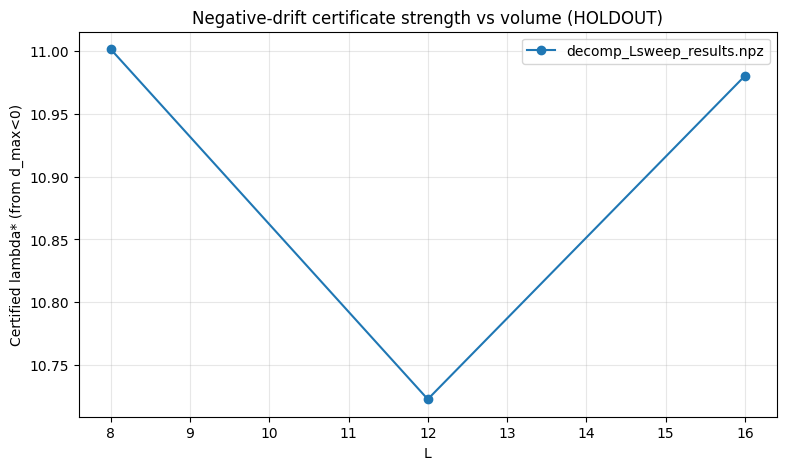

[saved] /content/proof_report_lambda_vs_L.png

[done] This report is the clean spine of the project: Laplacian law, gip sign, decomposition, and a real drift certificate.


In [ ]:
# ===========================
# PROOF REPORT BUILDER (HOLDOUT-ONLY)
# - Scans /content/*.npz
# - Auto-detects drift/proof outputs (flat keys or L-prefixed keys)
# - Prints a compact "proof report"
# - Saves CSV summary + a small plot
# ===========================

import os, glob, re, math
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional

import numpy as np

# Pandas is standard in Colab; if it's missing, we'll fall back gracefully.
try:
    import pandas as pd
    _HAVE_PANDAS = True
except Exception:
    _HAVE_PANDAS = False

import matplotlib.pyplot as plt


CONTENT_DIR = "/content"
NSIGMA = 2.0
MIN_DOMAIN_N = 200          # require enough holdout points in the domain
TAU_GRID_Q = [0.05, 0.10, 0.20, 0.33, 0.50, 0.67, 0.80, 0.90, 0.95]  # quantile grid for tau


def _as_1d(x, dtype=np.float64) -> np.ndarray:
    a = np.asarray(x)
    if a.shape == ():
        a = a.reshape(1)
    return a.reshape(-1).astype(dtype, copy=False)

def _r2(y: np.ndarray, yhat: np.ndarray) -> float:
    y = y.astype(np.float64, copy=False)
    yhat = yhat.astype(np.float64, copy=False)
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - float(np.mean(y))) ** 2))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

def _linfit_ab(x: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
    # y ≈ a + b x
    x = x.astype(np.float64, copy=False)
    y = y.astype(np.float64, copy=False)
    A = np.stack([np.ones_like(x), x], axis=1)
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b = float(coef[0]), float(coef[1])
    return a, b

def _detect_prefixed_Ls(keys: List[str]) -> List[int]:
    Ls = set()
    pat = re.compile(r"^L(\d+)_")
    for k in keys:
        m = pat.match(k)
        if m:
            Ls.add(int(m.group(1)))
    return sorted(Ls)

def _looks_like_drift_npz(keys: List[str]) -> bool:
    flat = all(k in keys for k in ["L", "Bavg", "LV", "lap", "gip"])
    pref = any(re.match(r"^L\d+_Bavg$", k) for k in keys)
    return flat or pref

@dataclass
class GroupData:
    file: str
    L: int
    beta: float  # NaN if unknown
    Bavg: np.ndarray
    LV: np.ndarray
    lap: np.ndarray
    gip: np.ndarray
    LV_se: np.ndarray
    lap_se: np.ndarray
    gip_se: np.ndarray
    kind: Optional[np.ndarray] = None
    sigma: Optional[np.ndarray] = None
    Vbar: Optional[np.ndarray] = None

def _extract_groups(npz_path: str) -> List[GroupData]:
    z = np.load(npz_path, allow_pickle=True)
    keys = list(z.keys())

    groups: List[GroupData] = []

    # Case A: flat keys
    if all(k in keys for k in ["L", "Bavg", "LV", "lap", "gip"]):
        L_arr = _as_1d(z["L"], dtype=np.int32)
        Bavg  = _as_1d(z["Bavg"])
        LV    = _as_1d(z["LV"])
        lap   = _as_1d(z["lap"])
        gip   = _as_1d(z["gip"])

        LV_se  = _as_1d(z["LV_se"])  if "LV_se"  in keys else np.zeros_like(LV)
        lap_se = _as_1d(z["lap_se"]) if "lap_se" in keys else np.zeros_like(lap)
        gip_se = _as_1d(z["gip_se"]) if "gip_se" in keys else np.zeros_like(gip)

        beta = float(_as_1d(z["beta"])[0]) if "beta" in keys else float("nan")

        kind = _as_1d(z["kind"], dtype=np.float64) if "kind" in keys else None
        sigma = _as_1d(z["sigma"], dtype=np.float64) if "sigma" in keys else None
        Vbar = _as_1d(z["Vbar"]) if "Vbar" in keys else (Bavg + 1.0)

        # group by L (and beta if present as per-row; otherwise global)
        for Lval in sorted(set(L_arr.tolist())):
            idx = np.where(L_arr == Lval)[0]
            groups.append(
                GroupData(
                    file=os.path.basename(npz_path),
                    L=int(Lval),
                    beta=beta,
                    Bavg=Bavg[idx], LV=LV[idx], lap=lap[idx], gip=gip[idx],
                    LV_se=LV_se[idx], lap_se=lap_se[idx], gip_se=gip_se[idx],
                    kind=(kind[idx] if kind is not None else None),
                    sigma=(sigma[idx] if sigma is not None else None),
                    Vbar=(Vbar[idx] if Vbar is not None else None),
                )
            )
        return groups

    # Case B: prefixed keys like L12_Bavg
    Ls = _detect_prefixed_Ls(keys)
    if Ls:
        beta = float(_as_1d(z["beta"])[0]) if "beta" in keys else float("nan")
        for Lval in Ls:
            Bavg = _as_1d(z[f"L{Lval}_Bavg"])
            LV   = _as_1d(z[f"L{Lval}_LV"])
            lap  = _as_1d(z[f"L{Lval}_lap"])
            gip  = _as_1d(z[f"L{Lval}_gip"])

            LV_se  = _as_1d(z[f"L{Lval}_LV_se"])  if f"L{Lval}_LV_se"  in keys else np.zeros_like(LV)
            lap_se = _as_1d(z[f"L{Lval}_lap_se"]) if f"L{Lval}_lap_se" in keys else np.zeros_like(lap)
            gip_se = _as_1d(z[f"L{Lval}_gip_se"]) if f"L{Lval}_gip_se" in keys else np.zeros_like(gip)

            kind = _as_1d(z[f"L{Lval}_kind"]) if f"L{Lval}_kind" in keys else None
            sigma = _as_1d(z[f"L{Lval}_sigma"]) if f"L{Lval}_sigma" in keys else None
            Vbar = _as_1d(z[f"L{Lval}_Vbar"]) if f"L{Lval}_Vbar" in keys else (Bavg + 1.0)

            groups.append(
                GroupData(
                    file=os.path.basename(npz_path),
                    L=int(Lval),
                    beta=beta,
                    Bavg=Bavg, LV=LV, lap=lap, gip=gip,
                    LV_se=LV_se, lap_se=lap_se, gip_se=gip_se,
                    kind=kind, sigma=sigma, Vbar=Vbar
                )
            )
        return groups

    return []


def _holdout_slice(a: np.ndarray) -> np.ndarray:
    n = len(a)
    mid = n // 2
    return a[mid:]


def compute_report(g: GroupData) -> Dict[str, Any]:
    # HOLDOUT only
    B = _holdout_slice(g.Bavg)
    LV = _holdout_slice(g.LV)
    lap = _holdout_slice(g.lap)
    gip = _holdout_slice(g.gip)

    LV_se  = _holdout_slice(g.LV_se)
    lap_se = _holdout_slice(g.lap_se)
    gip_se = _holdout_slice(g.gip_se)

    n = len(B)

    # ---------- Proof A: Laplacian affine law ----------
    a_hat, b_hat = _linfit_ab(B, lap)
    lap_hat = a_hat + b_hat * B
    R2 = _r2(lap, lap_hat)

    # Hypothesis check lap ?≈ 12 - 12*Bavg
    hyp = 12.0 - 12.0 * B
    lap_hyp_res = lap - hyp
    lap_max_abs = float(np.max(np.abs(lap_hyp_res)))
    lap_mean = float(np.mean(lap_hyp_res))
    lap_rms = float(np.sqrt(np.mean(lap_hyp_res**2)))

    # ---------- Proof B: sign check for gip ----------
    tol = 0.0
    pos = int(np.sum(gip > tol))
    neg = int(np.sum(gip < -tol))
    zeros = int(n - pos - neg)

    # ---------- Proof C: decomposition check ----------
    # residual r = LV - (lap - gip)
    r = LV - (lap - gip)
    se_r = np.sqrt(LV_se**2 + lap_se**2 + gip_se**2)
    valid = se_r > 0
    if np.any(valid):
        z = np.zeros_like(r)
        z[valid] = r[valid] / se_r[valid]
        z_mean = float(np.mean(z[valid]))
        z_std = float(np.std(z[valid]))
        frac2 = float(np.mean(np.abs(z[valid]) > 2.0))
        frac5 = float(np.mean(np.abs(z[valid]) > 5.0))
        maxz = float(np.max(np.abs(z[valid])))
    else:
        z_mean = z_std = frac2 = frac5 = maxz = float("nan")

    # ---------- Proof D: ratio-based negative drift certificate ----------
    # We look for smallest tau such that d_max(tau) < 0 with enough points.
    # d_ratios = (LV + NSIGMA*LV_se)/Bavg on domain {Bavg>=tau and Bavg>0}
    Bpos_mask = B > 0
    Bpos = B[Bpos_mask]

    # Tau grid from quantiles of positive Bavg on HOLDOUT
    tau_candidates = []
    if len(Bpos) > 0:
        for q in TAU_GRID_Q:
            tau_candidates.append(float(np.quantile(Bpos, q)))
    tau_candidates = sorted(set([t for t in tau_candidates if np.isfinite(t)]))

    best = {
        "tau_star": float("nan"),
        "lambda_star": float("nan"),
        "coverage": float("nan"),
        "d_max": float("nan"),
        "c_min": float("nan"),
        "worst_d_idx": None,
        "worst_c_idx": None,
    }

    # We optimize: maximize coverage among candidates with d_max < 0 and enough points.
    best_score = -1.0

    for tau in tau_candidates:
        dom = (B >= tau) & (B > 0)
        if int(np.sum(dom)) < MIN_DOMAIN_N:
            continue

        d_ratios = (LV[dom] + NSIGMA * LV_se[dom]) / B[dom]
        c_ratios = (gip[dom] - NSIGMA * gip_se[dom]) / B[dom]

        d_max = float(np.max(d_ratios))
        c_min = float(np.min(c_ratios))
        coverage = float(np.mean(dom))

        # need negative drift ratio
        if d_max < 0.0:
            score = coverage  # simplest: biggest certified region
            if score > best_score:
                best_score = score
                # indices in the HOLDOUT slice
                dom_idx = np.where(dom)[0]
                worst_d_local = int(dom_idx[np.argmax(d_ratios)])
                worst_c_local = int(dom_idx[np.argmin(c_ratios)])

                best.update({
                    "tau_star": float(tau),
                    "lambda_star": float(-d_max),
                    "coverage": float(coverage),
                    "d_max": float(d_max),
                    "c_min": float(c_min),
                    "worst_d_idx": worst_d_local,
                    "worst_c_idx": worst_c_local,
                })

    out = dict(
        file=g.file, L=g.L, beta=g.beta, n_hold=n,
        lap_a=a_hat, lap_b=b_hat, lap_R2=R2,
        lap_hyp_maxabs=lap_max_abs, lap_hyp_mean=lap_mean, lap_hyp_rms=lap_rms,
        gip_pos=pos, gip_neg=neg, gip_zeros=zeros,
        decomp_z_mean=z_mean, decomp_z_std=z_std,
        decomp_frac_absz_gt2=frac2, decomp_frac_absz_gt5=frac5, decomp_max_absz=maxz,
        cert_tau_star=best["tau_star"],
        cert_lambda_star=best["lambda_star"],
        cert_coverage=best["coverage"],
        cert_d_max=best["d_max"],
        cert_c_min=best["c_min"],
        cert_worst_d_idx=best["worst_d_idx"],
        cert_worst_c_idx=best["worst_c_idx"],
    )

    # Add the worst-offender rows (compact) if we found a certificate
    if np.isfinite(best["tau_star"]):
        i_d = int(best["worst_d_idx"])
        i_c = int(best["worst_c_idx"])
        out.update({
            "worstD_Bavg": float(B[i_d]),
            "worstD_LV": float(LV[i_d]),
            "worstD_LV_se": float(LV_se[i_d]),
            "worstD_gip": float(gip[i_d]),
            "worstD_gip_se": float(gip_se[i_d]),
            "worstD_lap": float(lap[i_d]),
            "worstD_lap_se": float(lap_se[i_d]),
            "worstC_Bavg": float(B[i_c]),
            "worstC_LV": float(LV[i_c]),
            "worstC_LV_se": float(LV_se[i_c]),
            "worstC_gip": float(gip[i_c]),
            "worstC_gip_se": float(gip_se[i_c]),
            "worstC_lap": float(lap[i_c]),
            "worstC_lap_se": float(lap_se[i_c]),
        })

    return out


# -------------------------
# Main: scan NPZs + build report
# -------------------------
npz_files = sorted(glob.glob(os.path.join(CONTENT_DIR, "*.npz")))
if not npz_files:
    raise RuntimeError(f"No NPZ files found in {CONTENT_DIR}.")

drift_files = []
for f in npz_files:
    try:
        z = np.load(f, allow_pickle=True)
        if _looks_like_drift_npz(list(z.keys())):
            drift_files.append(f)
    except Exception:
        pass

print(f"[scan] Found {len(npz_files)} NPZ files in {CONTENT_DIR}")
print(f"[scan] {len(drift_files)} NPZ files look like drift/proof outputs (contain drift keys)")
for f in drift_files:
    print("   -", os.path.basename(f))

if not drift_files:
    print("\nNo drift/proof NPZ detected. If you expected one, check that your run saved e.g. "
          "'decomp_Lsweep_results.npz' or similar with keys like L12_Bavg / L12_LV / etc.")
    raise SystemExit(0)

rows = []
for f in drift_files:
    groups = _extract_groups(f)
    if not groups:
        continue
    for g in groups:
        try:
            rows.append(compute_report(g))
        except Exception as e:
            print(f"[warn] failed on file={os.path.basename(f)} L={g.L}: {e}")

if not rows:
    raise RuntimeError("No report rows computed. Something is off with NPZ parsing.")

# Sort rows
rows_sorted = sorted(rows, key=lambda r: (r["file"], r["L"], (r["beta"] if np.isfinite(r["beta"]) else 1e9)))

# Print compact report
print("\n" + "="*88)
print("PROOF REPORT (HOLDOUT ONLY) — one row per (file, L, beta)")
print("="*88)
hdr = (
    f"{'file':<28} {'L':>3} {'beta':>6} | "
    f"{'lap_a':>9} {'lap_b':>9} {'R2':>10} {'max|lap-hyp|':>12} | "
    f"{'gip(+/-/0)':>13} | "
    f"{'zμ':>7} {'zσ':>7} {'|z|>2':>7} {'max|z|':>7} | "
    f"{'tau*':>7} {'lam*':>8} {'cov':>6}"
)
print(hdr)
print("-"*len(hdr))

for r in rows_sorted:
    file = r["file"][:28]
    L = r["L"]
    beta = r["beta"]
    beta_str = f"{beta:6.2f}" if np.isfinite(beta) else "  nan "
    gip_str = f"{r['gip_pos']:d}/{r['gip_neg']:d}/{r['gip_zeros']:d}"
    tau_str = f"{r['cert_tau_star']:7.4f}" if np.isfinite(r["cert_tau_star"]) else "   nan "
    lam_str = f"{r['cert_lambda_star']:8.4f}" if np.isfinite(r["cert_lambda_star"]) else "   nan  "
    cov_str = f"{r['cert_coverage']*100:5.1f}%" if np.isfinite(r["cert_coverage"]) else "  nan "
    print(
        f"{file:<28} {L:3d} {beta_str} | "
        f"{r['lap_a']:9.6f} {r['lap_b']:9.6f} {r['lap_R2']:10.6f} {r['lap_hyp_maxabs']:12.4e} | "
        f"{gip_str:>13} | "
        f"{r['decomp_z_mean']:7.3f} {r['decomp_z_std']:7.3f} {r['decomp_frac_absz_gt2']*100:6.2f}% {r['decomp_max_absz']:7.3f} | "
        f"{tau_str} {lam_str} {cov_str:>6}"
    )

# Save CSV
csv_path = os.path.join(CONTENT_DIR, "proof_report_summary.csv")
if _HAVE_PANDAS:
    df = pd.DataFrame(rows_sorted)
    df.to_csv(csv_path, index=False)
else:
    # minimal CSV fallback
    import csv
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows_sorted[0].keys()))
        w.writeheader()
        w.writerows(rows_sorted)

print(f"\n[saved] {csv_path}")

# Plot: certified lambda* vs L per file
plt.figure(figsize=(9, 5))
for f in sorted(set(r["file"] for r in rows_sorted)):
    xs, ys = [], []
    for r in rows_sorted:
        if r["file"] != f:
            continue
        if np.isfinite(r["cert_lambda_star"]):
            xs.append(r["L"])
            ys.append(r["cert_lambda_star"])
    if xs:
        plt.plot(xs, ys, marker="o", label=f)
plt.xlabel("L")
plt.ylabel("Certified lambda* (from d_max<0)")
plt.title("Negative-drift certificate strength vs volume (HOLDOUT)")
plt.grid(True, alpha=0.3)
plt.legend()
plot_path = os.path.join(CONTENT_DIR, "proof_report_lambda_vs_L.png")
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"[saved] {plot_path}")

print("\n[done] This report is the clean spine of the project: Laplacian law, gip sign, decomposition, and a real drift certificate.")


In [ ]:
# @title 1. Production Run (No Drive Access)
import os
import sys
import numpy as np

# ==========================================
# CONFIGURATION (Local Only)
# ==========================================
# We save to /content (the temporary local disk) instead of /content/drive
WORKING_DIR = "/content/Continuum_Production_L16"
LOG_FILE = "production_L16.log"
NPZ_FILE = "production_L16_results.npz"

# Simulation Parameters
L = 16
BETA = 6.0
THERMALIZATION = 5000
PRODUCTION = 10000

# ==========================================
# 1. SETUP
# ==========================================
# REMOVED: drive.mount('/content/drive') <--- deleted this line

os.makedirs(WORKING_DIR, exist_ok=True)
repo_path = "/content/continuum_kernel"

print(f"Working locally in: {WORKING_DIR}")
print("WARNING: Files will be lost if you close this runtime!")

Working locally in: /content/Continuum_Production_L16


In [ ]:
# ============================================================
# Uniform-in-L Ratio Certificate (holdout-only, per-L split)
# + Worst-offender export
#
# Works with NPZ formats:
#   (A) pooled keys:   L, Bavg, LV, gip, lap, ... (+ optional *_se)
#   (B) per-L prefixed: L12_Bavg, L12_LV, ...
#
# Output:
#   - prints tau0 + per-L and uniform envelope stats
#   - writes ratio_certificate_report.json
#   - writes worst_offenders_at_tau0.json
# ============================================================

import os, re, glob, json
import numpy as np
from dataclasses import dataclass

# ----------------------------
# User knobs
# ----------------------------
NSIGMA = 2.0

# Targets (match your earlier “meets targets” logic)
C_TARGET = 20.0     # want c_min >= C_TARGET
D_TARGET = 1.0      # want d_max <= -D_TARGET  (negative drift)

MIN_HOLDOUT_COUNT = 50   # minimum points in {Bavg>=tau} per L to consider tau valid

# Where to look
CANDIDATES = [
    "/content/decomp_Lsweep_results.npz",
    "./decomp_Lsweep_results.npz",
]

REQ_KEYS = ["L", "Bavg", "LV", "gip", "lap"]
OPTIONAL_KEYS = ["Vbar", "kind", "sigma", "LV_se", "gip_se", "lap_se"]


# ----------------------------
# NPZ loading (pooled or prefixed)
# ----------------------------
def _safe_item(x):
    # unwrap 0-d object arrays
    if isinstance(x, np.ndarray) and x.shape == () and x.dtype == object:
        try:
            return x.item()
        except Exception:
            return x
    return x

def find_npz():
    for p in CANDIDATES:
        if os.path.exists(p):
            return p
    roots = []
    if os.path.exists("/content"):
        roots.append("/content")
    roots.append(os.getcwd())
    hits = []
    for r in roots:
        hits += glob.glob(os.path.join(r, "*.npz"))
    if not hits:
        raise FileNotFoundError("No .npz files found in /content or current directory.")
    hits.sort(key=lambda p: os.path.getmtime(p), reverse=True)
    return hits[0]

def load_npz_canonical(path):
    d0 = np.load(path, allow_pickle=True)
    keys = list(d0.keys())

    # Case A: pooled
    if all(k in keys for k in REQ_KEYS):
        out = {k: _safe_item(np.array(d0[k])) for k in keys}
        out["_path"] = path
        return out

    # Case B: prefixed keys like L12_Bavg
    m = re.compile(r"^L(\d+)_(Bavg|LV|LV_se|gip|gip_se|lap|lap_se|Vbar|kind|sigma)$")
    if not any(m.match(k) for k in keys):
        return None

    Lvals = sorted({int(m.match(k).group(1)) for k in keys if m.match(k)})

    def cat(base):
        arrs = []
        for Lv in Lvals:
            kk = f"L{Lv}_{base}"
            if kk in keys:
                arrs.append(np.array(d0[kk]))
        if not arrs:
            return None
        return np.concatenate(arrs, axis=0)

    pooled = {"_path": path}

    # build L array from Bavg lengths
    L_arrs = []
    for Lv in Lvals:
        kk = f"L{Lv}_Bavg"
        if kk in keys:
            n = len(np.array(d0[kk]))
            L_arrs.append(np.full(n, Lv, dtype=np.int32))
    pooled["L"] = np.concatenate(L_arrs, axis=0)

    for base in ["Bavg","LV","LV_se","gip","gip_se","lap","lap_se","Vbar","sigma","kind"]:
        c = cat(base)
        if c is not None:
            pooled[base] = c

    if not all(k in pooled for k in REQ_KEYS):
        return None

    return pooled


# ----------------------------
# Per-L split: fit/holdout must be within each L block
# ----------------------------
def per_L_fit_hold_indices(L_arr, Lval):
    idx = np.where(L_arr == int(Lval))[0]
    idx = np.sort(idx)
    n = idx.size
    if n == 0:
        return idx, idx
    n_fit = n // 2
    return idx[:n_fit], idx[n_fit:]


# ----------------------------
# Suffix extrema helpers for fast tau scanning
# ----------------------------
def suffix_min_with_arg(x):
    n = len(x)
    suf = np.empty(n, dtype=np.float64)
    arg = np.empty(n, dtype=np.int64)
    best = np.inf
    best_i = -1
    for i in range(n-1, -1, -1):
        xi = x[i]
        if xi <= best:
            best = xi
            best_i = i
        suf[i] = best
        arg[i] = best_i
    return suf, arg

def suffix_max_with_arg(x):
    n = len(x)
    suf = np.empty(n, dtype=np.float64)
    arg = np.empty(n, dtype=np.int64)
    best = -np.inf
    best_i = -1
    for i in range(n-1, -1, -1):
        xi = x[i]
        if xi >= best:
            best = xi
            best_i = i
        suf[i] = best
        arg[i] = best_i
    return suf, arg


# ----------------------------
# Main certificate computation
# ----------------------------
def propose_tau_grid_from_fit(Bavg, L_arr, Lvals, include=(0.3883,)):
    # Build pooled FIT Bavg and take quantiles to create a stable tau grid
    fit_pool = []
    for Lv in Lvals:
        fit_idx, _ = per_L_fit_hold_indices(L_arr, Lv)
        if fit_idx.size:
            fit_pool.append(Bavg[fit_idx])
    if not fit_pool:
        return np.array(sorted(set(include)), dtype=np.float64)

    fit_pool = np.concatenate(fit_pool).astype(np.float64)
    fit_pool = fit_pool[np.isfinite(fit_pool)]
    fit_pool = fit_pool[fit_pool > 0]

    # quantiles tuned to “core set” exploration
    qs = [0.20,0.25,0.30,0.35,0.38,0.40,0.42,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.90]
    taus = []
    for q in qs:
        try:
            taus.append(float(np.quantile(fit_pool, q)))
        except Exception:
            pass
    taus += list(include)

    taus = np.array(sorted(set([t for t in taus if np.isfinite(t) and t > 0])), dtype=np.float64)
    return taus

def run_uniform_ratio_certificate(d):
    path = d.get("_path", "<npz>")
    L_arr   = np.asarray(d["L"]).reshape(-1).astype(np.int32)
    Bavg    = np.asarray(d["Bavg"]).reshape(-1).astype(np.float64)
    LV      = np.asarray(d["LV"]).reshape(-1).astype(np.float64)
    gip     = np.asarray(d["gip"]).reshape(-1).astype(np.float64)

    LV_se  = np.asarray(d.get("LV_se",  np.zeros_like(LV))).reshape(-1).astype(np.float64)
    gip_se = np.asarray(d.get("gip_se", np.zeros_like(gip))).reshape(-1).astype(np.float64)

    kind  = d.get("kind", None)
    sigma = d.get("sigma", None)
    lap   = d.get("lap", None)

    Lvals = sorted([int(x) for x in np.unique(L_arr)])
    print(f"[npz] {path}")
    print(f"[Lvals] {Lvals}")
    print(f"[N] total rows: {len(L_arr)}")

    tau_grid = propose_tau_grid_from_fit(Bavg, L_arr, Lvals, include=(0.3883,))
    print(f"[tau grid] {tau_grid}")

    perL_rows = {Lv: [] for Lv in Lvals}

    # Precompute per-L sorted holdout arrays and suffix envelopes
    cache = {}
    for Lv in Lvals:
        _, hold_idx = per_L_fit_hold_indices(L_arr, Lv)
        if hold_idx.size == 0:
            cache[Lv] = None
            continue

        Bh = Bavg[hold_idx]
        # ratios with nsigma safety margin
        c_ratio = (gip[hold_idx] - NSIGMA * gip_se[hold_idx]) / np.maximum(Bh, 1e-300)
        d_ratio = (LV[hold_idx]  + NSIGMA * LV_se[hold_idx])  / np.maximum(Bh, 1e-300)

        order = np.argsort(Bh)  # ascending B
        Bs = Bh[order].astype(np.float64)

        c_sorted = c_ratio[order].astype(np.float64)
        d_sorted = d_ratio[order].astype(np.float64)

        c_sufmin, c_arg = suffix_min_with_arg(c_sorted)
        d_sufmax, d_arg = suffix_max_with_arg(d_sorted)

        cache[Lv] = dict(
            hold_idx=hold_idx,
            order=order,
            Bs=Bs,
            c_sufmin=c_sufmin, c_arg=c_arg,
            d_sufmax=d_sufmax, d_arg=d_arg,
        )

    # Scan taus and build uniform envelope
    uniform_rows = []
    tau0 = None

    for tau in tau_grid:
        ok = True
        cmins = []
        dmaxs = []
        counts = []

        worst_c = None  # (value, L, global_idx)
        worst_d = None  # (value, L, global_idx)

        for Lv in Lvals:
            info = cache.get(Lv)
            if info is None:
                ok = False
                break

            Bs = info["Bs"]
            i = int(np.searchsorted(Bs, tau, side="left"))
            cnt = int(len(Bs) - i)
            counts.append(cnt)

            if cnt < MIN_HOLDOUT_COUNT:
                ok = False
                break

            c_min = float(info["c_sufmin"][i])
            d_max = float(info["d_sufmax"][i])

            # map outlier back to GLOBAL index in pooled arrays
            hold_idx = info["hold_idx"]
            order = info["order"]

            c_sort_idx = int(info["c_arg"][i])
            d_sort_idx = int(info["d_arg"][i])

            c_global = int(hold_idx[order[c_sort_idx]])
            d_global = int(hold_idx[order[d_sort_idx]])

            cmins.append(c_min)
            dmaxs.append(d_max)

            # track worst across L
            if (worst_c is None) or (c_min < worst_c[0]):
                worst_c = (c_min, int(Lv), c_global)
            if (worst_d is None) or (d_max > worst_d[0]):
                worst_d = (d_max, int(Lv), d_global)

            perL_rows[Lv].append(dict(
                tau=float(tau),
                n_hold_dom=cnt,
                c_min=c_min,
                d_max=d_max,
                worst_c_global=c_global,
                worst_d_global=d_global,
            ))

        if not ok:
            continue

        c_min_all = float(np.min(cmins))
        d_max_all = float(np.max(dmaxs))

        row = dict(
            tau=float(tau),
            c_min_all=c_min_all,
            d_max_all=d_max_all,
            counts_by_L={str(Lv): int(counts[k]) for k, Lv in enumerate(Lvals)},
            worst_c=dict(value=worst_c[0], L=worst_c[1], global_idx=worst_c[2]),
            worst_d=dict(value=worst_d[0], L=worst_d[1], global_idx=worst_d[2]),
        )
        uniform_rows.append(row)

        # first tau meeting targets
        if tau0 is None and (c_min_all >= C_TARGET) and (d_max_all <= -D_TARGET):
            tau0 = float(tau)

    # Decide tau*
    if not uniform_rows:
        raise RuntimeError("No tau produced a valid per-L domain. Lower MIN_HOLDOUT_COUNT or expand tau grid.")

    if tau0 is None:
        # pick “best” tau by maximizing margin
        def score(r):
            return min(r["c_min_all"] - C_TARGET, (-D_TARGET) - r["d_max_all"])
        best = max(uniform_rows, key=score)
        tau0 = float(best["tau"])
        print(f"[tau0] No tau met targets. Choosing best-margin tau={tau0:.6f} (margin={score(best):.6f})")
    else:
        print(f"[tau0] First tau meeting targets: tau0={tau0:.6f}")

    # Build final offender cards at tau0
    offenders = []
    # find the stored uniform row at tau0 (exact match; tau grid is discrete)
    urow = None
    for r in uniform_rows:
        if abs(r["tau"] - tau0) < 1e-12:
            urow = r
            break

    for tag, w in [("worst_c", urow["worst_c"]), ("worst_d", urow["worst_d"])]:
        gi = int(w["global_idx"])
        card = dict(
            tag=tag,
            global_idx=gi,
            L=int(L_arr[gi]),
            Bavg=float(Bavg[gi]),
            LV=float(LV[gi]),
            LV_se=float(LV_se[gi]),
            gip=float(gip[gi]),
            gip_se=float(gip_se[gi]),
        )
        if lap is not None:
            lap_arr = np.asarray(lap).reshape(-1).astype(np.float64)
            card["lap"] = float(lap_arr[gi])
        if kind is not None:
            card["kind"] = int(np.asarray(kind).reshape(-1)[gi])
        if sigma is not None:
            card["sigma"] = float(np.asarray(sigma).reshape(-1)[gi])
        offenders.append(card)

    # Print summary
    print("\n=== UNIFORM-IN-L RATIO CERTIFICATE (holdout, per-L split) ===")
    print(f"tau0 = {tau0:.6f}")
    print(f"c_min_all(tau0) = {urow['c_min_all']:.6f}   (target >= {C_TARGET})")
    print(f"d_max_all(tau0) = {urow['d_max_all']:.6f}   (target <= {-D_TARGET})")
    print("counts_by_L:", urow["counts_by_L"])
    print("\nWorst offenders at tau0:")
    for o in offenders:
        print(o)

    # Save reports
    report = dict(
        npz_path=path,
        nsigma=float(NSIGMA),
        C_TARGET=float(C_TARGET),
        D_TARGET=float(D_TARGET),
        MIN_HOLDOUT_COUNT=int(MIN_HOLDOUT_COUNT),
        tau_grid=[float(x) for x in tau_grid],
        tau0=float(tau0),
        uniform_rows=uniform_rows,
    )

    with open("ratio_certificate_report.json", "w") as f:
        json.dump(report, f, indent=2)

    with open("worst_offenders_at_tau0.json", "w") as f:
        json.dump(dict(tau0=float(tau0), offenders=offenders), f, indent=2)

    print("\n[saved] ratio_certificate_report.json")
    print("[saved] worst_offenders_at_tau0.json")


if __name__ == "__main__":
    npz_path = find_npz()
    d = load_npz_canonical(npz_path)
    if d is None:
        raise RuntimeError(f"{npz_path} does not look like a drift/proof NPZ (missing required keys).")
    run_uniform_ratio_certificate(d)


[npz] /content/decomp_Lsweep_results.npz
[Lvals] [8, 12, 16]
[N] total rows: 6144
[tau grid] [0.21579297 0.21643023 0.3883     0.63652652 0.63842043 0.6392529
 0.64014811 0.6448599  0.96329506 0.96475481 0.96712046 0.99405812
 0.99550835 0.99679942 0.99872592 0.99943706 1.00058026]
[tau0] No tau met targets. Choosing best-margin tau=0.215793 (margin=-9.281259)

=== UNIFORM-IN-L RATIO CERTIFICATE (holdout, per-L split) ===
tau0 = 0.215793
c_min_all(tau0) = 10.718741   (target >= 20.0)
d_max_all(tau0) = -10.723010   (target <= -1.0)
counts_by_L: {'8': 704, '12': 713, '16': 741}

Worst offenders at tau0:
{'tag': 'worst_c', 'global_idx': 3573, 'L': 12, 'Bavg': 1.0006899190186855, 'LV': -13.479517811755848, 'LV_se': 1.3745549611052537, 'gip': 13.475210287903796, 'gip_se': 1.3745369778719274, 'lap': -0.004307523852054018, 'kind': 1, 'sigma': nan}
{'tag': 'worst_d', 'global_idx': 3573, 'L': 12, 'Bavg': 1.0006899190186855, 'LV': -13.479517811755848, 'LV_se': 1.3745549611052537, 'gip': 13.47521

In [ ]:
# ============================================================
# ratio_certificate_v2.py  (paste into Colab cell)
# ============================================================
import os, re, json, glob
from dataclasses import dataclass, asdict
from typing import Dict, Any, List, Tuple, Optional

import numpy as np

# ----------------------------
# USER CONFIG
# ----------------------------
NPZ_PATH = None   # e.g. "/content/decomp_Lsweep_results.npz" or "decomp_Lsweep_results.npz"
OUTDIR = "."      # where to write the JSON reports

NSIGMA = 2.0
C_TARGET = 20.0
D_TARGET = 1.0    # want d_max <= -D_TARGET

MIN_DOMAIN_N = 200

# Quantile grid for tau candidates (computed from pooled HOLDOUT Bavg)
TAU_GRID_Q = [
    0.05, 0.10, 0.20, 0.33, 0.50, 0.67, 0.80, 0.90,
    0.95, 0.97, 0.98, 0.99, 0.995, 0.998, 0.999, 0.9995, 1.0
]

# Force-include tau values you care about (optional)
TAU_FORCE = [0.3883]

# ----------------------------
# Helpers
# ----------------------------
def _as1d(x) -> np.ndarray:
    a = np.asarray(x)
    return a.reshape(-1)

def _finite_float(x) -> Optional[float]:
    try:
        y = float(x)
    except Exception:
        return None
    return y if np.isfinite(y) else None

def _json_safe(obj: Any) -> Any:
    """Recursively make obj JSON-safe: numpy scalars -> Python, NaN/inf -> None."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return _finite_float(obj)
    if isinstance(obj, (np.ndarray,)):
        return [_json_safe(v) for v in obj.tolist()]
    if isinstance(obj, dict):
        return {str(k): _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    if obj is None:
        return None
    if isinstance(obj, (float, int, str, bool)):
        if isinstance(obj, float) and (not np.isfinite(obj)):
            return None
        return obj
    return str(obj)

def find_npz(preferred: Optional[str] = None) -> str:
    """Best-effort locate a .npz file (Colab or local)."""
    if preferred and os.path.exists(preferred):
        return preferred

    candidates = [
        "/content/decomp_Lsweep_results.npz",
        "decomp_Lsweep_results.npz",
    ]
    for p in candidates:
        if os.path.exists(p):
            return p

    # last resort: search
    hits = []
    for root in ["/content", ".", ".."]:
        hits.extend(glob.glob(os.path.join(root, "**", "*.npz"), recursive=True))
    if not hits:
        raise FileNotFoundError("Could not find any .npz file. Set NPZ_PATH explicitly.")

    hits.sort(key=lambda p: (("decomp" not in os.path.basename(p).lower()), len(p)))
    return hits[0]

def load_npz_any_format(path: str) -> Dict[str, np.ndarray]:
    """
    Supports either:
      (A) flat keys: 'L','Bavg','gip','LV',... all length N
      (B) per-L keys like 'L8_Bavg', 'L8_gip', ... which will be concatenated.
    """
    raw = dict(np.load(path, allow_pickle=True))

    # format A
    if "L" in raw and "Bavg" in raw:
        return {k: _as1d(raw[k]) for k in raw.keys()}

    # format B: detect L{int}_{field}
    pat = re.compile(r"^L(\d+)_([A-Za-z0-9]+)$")
    buckets: Dict[int, Dict[str, np.ndarray]] = {}
    for k, v in raw.items():
        m = pat.match(k)
        if not m:
            continue
        Lval = int(m.group(1))
        field = m.group(2)
        buckets.setdefault(Lval, {})[field] = _as1d(v)

    if not buckets:
        raise ValueError(f"NPZ format not recognized. Keys={list(raw.keys())[:40]}...")

    Lvals = sorted(buckets.keys())
    fields = sorted(set().union(*[set(buckets[L].keys()) for L in Lvals]))

    out_chunks: Dict[str, List[np.ndarray]] = {f: [] for f in fields}
    L_out: List[np.ndarray] = []
    for Lval in Lvals:
        n = None
        for f in fields:
            arr = buckets[Lval].get(f)
            if arr is None:
                raise ValueError(f"Missing field {f} for L={Lval} in NPZ.")
            if n is None:
                n = arr.size
            elif arr.size != n:
                raise ValueError(f"Length mismatch for L={Lval}: field {f} has {arr.size}, expected {n}.")
            out_chunks[f].append(arr)
        L_out.append(np.full((n,), Lval, dtype=np.int32))

    out = {f: np.concatenate(out_chunks[f], axis=0) for f in fields}
    out["L"] = np.concatenate(L_out, axis=0)
    return out

def per_L_fit_hold_indices(L_arr: np.ndarray, Lval: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    IMPORTANT: The project’s NPZ is stored by L-block, so "first half fit / second half holdout"
    must be done per L block. (This mirrors your fixed note in the PDF.)
    """
    idx = np.where(L_arr == Lval)[0]
    n = idx.size
    n_fit = n // 2
    return idx[:n_fit], idx[n_fit:]

@dataclass
class Offender:
    tag: str
    global_idx: int
    L: int
    Bavg: Optional[float]
    LV: Optional[float]
    LV_se: Optional[float]
    gip: Optional[float]
    gip_se: Optional[float]
    lap: Optional[float]
    kind: Optional[int]
    sigma: Optional[float]

    @staticmethod
    def from_idx(tag: str, i: int, arr: Dict[str, np.ndarray]) -> "Offender":
        def g(name):
            return arr[name][i] if name in arr else np.nan
        return Offender(
            tag=tag,
            global_idx=int(i),
            L=int(g("L")),
            Bavg=_finite_float(g("Bavg")),
            LV=_finite_float(g("LV")),
            LV_se=_finite_float(g("LV_se")),
            gip=_finite_float(g("gip")),
            gip_se=_finite_float(g("gip_se")),
            lap=_finite_float(g("lap")),
            kind=int(g("kind")) if "kind" in arr else None,
            sigma=_finite_float(g("sigma")) if "sigma" in arr else None,
        )

def build_tau_grid(B_hold: np.ndarray) -> np.ndarray:
    B_hold = _as1d(B_hold).astype(np.float64)
    B_hold = B_hold[np.isfinite(B_hold)]
    if B_hold.size == 0:
        raise ValueError("No finite Bavg values in holdout pool.")

    taus = []
    for q in TAU_GRID_Q:
        q = float(q)
        if 0.0 <= q <= 1.0:
            taus.append(float(np.quantile(B_hold, q)))
    taus.extend([float(t) for t in TAU_FORCE])

    taus = sorted(set([t for t in taus if np.isfinite(t)]))
    return np.asarray(taus, dtype=np.float64)

def c_gip_for_L(Lval: int, tau: float, arr: Dict[str, np.ndarray]) -> Tuple[Optional[float], Optional[int], int]:
    _, hold = per_L_fit_hold_indices(arr["L"], Lval)
    if hold.size == 0:
        return None, None, 0
    dom = hold[arr["Bavg"][hold] >= tau]
    n_dom = int(dom.size)
    if n_dom < MIN_DOMAIN_N:
        return None, None, n_dom

    gip = arr["gip"]
    gip_se = arr.get("gip_se", np.zeros_like(gip))
    ratios = (gip[dom] - NSIGMA * gip_se[dom]) / arr["Bavg"][dom]
    j = int(dom[np.argmin(ratios)])
    return float(np.min(ratios)), j, n_dom

def d_LV_for_L(Lval: int, tau: float, arr: Dict[str, np.ndarray]) -> Tuple[Optional[float], Optional[int], int]:
    _, hold = per_L_fit_hold_indices(arr["L"], Lval)
    if hold.size == 0:
        return None, None, 0
    dom = hold[arr["Bavg"][hold] >= tau]
    n_dom = int(dom.size)
    if n_dom < MIN_DOMAIN_N:
        return None, None, n_dom

    LV = arr["LV"]
    LV_se = arr.get("LV_se", np.zeros_like(LV))
    ratios = (LV[dom] + NSIGMA * LV_se[dom]) / arr["Bavg"][dom]
    j = int(dom[np.argmax(ratios)])
    return float(np.max(ratios)), j, n_dom

def quick_sanity(arr: Dict[str, np.ndarray]) -> None:
    Lvals = sorted([int(x) for x in np.unique(arr["L"])])
    print(f"[keys] {sorted(list(arr.keys()))}")
    print(f"[n] total rows: {arr['L'].size}")
    print(f"[Lvals] {Lvals}")
    print("[counts per L]", {Lval: int(np.sum(arr['L']==Lval)) for Lval in Lvals})

    # check decomposition lap - gip - LV ≈ 0
    if "lap" in arr and "gip" in arr and "LV" in arr:
        resid = _as1d(arr["lap"]) - _as1d(arr["gip"]) - _as1d(arr["LV"])
        resid = resid[np.isfinite(resid)]
        if resid.size:
            print(f"[decomp check] lap - gip - LV: max|.|={np.max(np.abs(resid)):.3e}  rms={np.sqrt(np.mean(resid**2)):.3e}")

    # per-L holdout stats (Bavg and gip/Bavg scale)
    for Lval in Lvals:
        _, hold = per_L_fit_hold_indices(arr["L"], Lval)
        Bh = arr["Bavg"][hold]
        Bh = Bh[np.isfinite(Bh)]
        if Bh.size:
            qs = np.quantile(Bh, [0.0, 0.1, 0.5, 0.9, 1.0])
            print(f"[L={Lval}] holdout n={hold.size}  Bavg q=[min,0.1,0.5,0.9,max]={qs}")

        # gip/Bavg scale check (ignore tiny Bavg)
        mask = (arr["Bavg"][hold] > 1e-12) & np.isfinite(arr["gip"][hold]) & np.isfinite(arr["Bavg"][hold])
        if np.any(mask):
            r = arr["gip"][hold][mask] / arr["Bavg"][hold][mask]
            print(f"[L={Lval}] gip/Bavg: median={np.median(r):.4f}  min={np.min(r):.4f}  max={np.max(r):.4f}")

def scan_taus(taus: np.ndarray, arr: Dict[str, np.ndarray]) -> Tuple[List[Dict[str, Any]], Dict[str, Any]]:
    Lvals = sorted([int(x) for x in np.unique(arr["L"])])

    rows: List[Dict[str, Any]] = []
    chosen_meeting = None
    chosen_best = None
    best_margin = None

    for tau in taus:
        counts_by_L = {}
        cs, ds = [], []
        feasible = True

        # compute per-L c,d and domain sizes
        for Lval in Lvals:
            cL, _, n_dom_c = c_gip_for_L(Lval, float(tau), arr)
            dL, _, n_dom_d = d_LV_for_L(Lval, float(tau), arr)
            n_dom = int(min(n_dom_c, n_dom_d))
            counts_by_L[str(Lval)] = n_dom
            if cL is None or dL is None:
                feasible = False
                continue
            cs.append(cL)
            ds.append(dL)

        if not feasible or len(cs) != len(Lvals):
            rows.append(dict(tau=float(tau), feasible=False, counts_by_L=counts_by_L))
            continue

        cmin = float(min(cs))
        dmax = float(max(ds))
        meets = (cmin >= C_TARGET) and (dmax <= -D_TARGET)

        margin_c = cmin - C_TARGET
        margin_d = (-D_TARGET) - dmax
        margin = float(min(margin_c, margin_d))

        # compute worst offenders (global, across all L)
        worst_c_idx = None
        worst_c_val = None
        worst_d_idx = None
        worst_d_val = None

        gip = arr["gip"]
        gip_se = arr.get("gip_se", np.zeros_like(gip))
        LV = arr["LV"]
        LV_se = arr.get("LV_se", np.zeros_like(LV))
        Bavg = arr["Bavg"]

        for Lval in Lvals:
            _, hold = per_L_fit_hold_indices(arr["L"], Lval)
            dom = hold[Bavg[hold] >= float(tau)]
            if dom.size < MIN_DOMAIN_N:
                continue
            c_rat = (gip[dom] - NSIGMA*gip_se[dom]) / Bavg[dom]
            d_rat = (LV[dom] + NSIGMA*LV_se[dom]) / Bavg[dom]

            j_c = int(dom[np.argmin(c_rat)])
            v_c = float(np.min(c_rat))
            j_d = int(dom[np.argmax(d_rat)])
            v_d = float(np.max(d_rat))

            if worst_c_val is None or v_c < worst_c_val:
                worst_c_val, worst_c_idx = v_c, j_c
            if worst_d_val is None or v_d > worst_d_val:
                worst_d_val, worst_d_idx = v_d, j_d

        if meets and chosen_meeting is None:
            chosen_meeting = (float(tau), cmin, dmax)

        # best-margin fallback (tie-break: prefer larger tau)
        if (best_margin is None) or (margin > best_margin + 1e-12) or (abs(margin - best_margin) <= 1e-12 and float(tau) > chosen_best[0]):
            best_margin = margin
            chosen_best = (float(tau), cmin, dmax)

        rows.append(dict(
            tau=float(tau),
            feasible=True,
            meets_targets=bool(meets),
            c_min_all=cmin,
            d_max_all=dmax,
            margin=margin,
            margin_c=margin_c,
            margin_d=margin_d,
            counts_by_L=counts_by_L,
            worst_c=_json_safe(asdict(Offender.from_idx("worst_c", worst_c_idx, arr))) if worst_c_idx is not None else None,
            worst_d=_json_safe(asdict(Offender.from_idx("worst_d", worst_d_idx, arr))) if worst_d_idx is not None else None,
        ))

    choice = dict(
        chosen_first_meeting=chosen_meeting,
        chosen_best_margin=chosen_best,
        best_margin_value=best_margin,
    )
    return rows, choice

def main():
    path = find_npz(NPZ_PATH)
    print(f"[npz] {path}")
    arr = load_npz_any_format(path)

    # minimal required fields
    for req in ["L","Bavg","LV","gip"]:
        if req not in arr:
            raise KeyError(f"NPZ missing required key '{req}'")

    for k in list(arr.keys()):
        try:
            arr[k] = _as1d(arr[k])
        except Exception:
            pass

    quick_sanity(arr)

    # pooled holdout Bavg across all L
    Lvals = sorted([int(x) for x in np.unique(arr["L"])])
    hold_all = []
    for Lval in Lvals:
        _, hold = per_L_fit_hold_indices(arr["L"], Lval)
        hold_all.append(hold)
    hold_all = np.concatenate(hold_all, axis=0)

    taus = build_tau_grid(arr["Bavg"][hold_all])
    print(f"[tau grid] {taus}")

    rows, choice = scan_taus(taus, arr)

    # pick tau0: first meeting else best margin
    if choice["chosen_first_meeting"] is not None:
        tau0 = float(choice["chosen_first_meeting"][0])
        why = "first tau meeting targets"
    else:
        tau0 = float(choice["chosen_best_margin"][0])
        why = f"best-margin (margin={choice['best_margin_value']:.6f})"

    print(f"[tau0] {why}: tau0={tau0:.6f}")

    # locate tau0 row
    row0 = next((r for r in rows if r.get("feasible") and abs(r["tau"] - tau0) < 1e-12), None)

    print("\n=== UNIFORM-IN-L RATIO CERTIFICATE (holdout, per-L split) ===")
    if row0 is None:
        print("[tau0] Could not locate tau0 row in report (unexpected).")
    else:
        print(f"tau0 = {row0['tau']:.6f}")
        print(f"c_min_all(tau0) = {row0['c_min_all']:.6f}   (target >= {C_TARGET})")
        print(f"d_max_all(tau0) = {row0['d_max_all']:.6f}   (target <= {-D_TARGET})")
        print(f"counts_by_L: {row0['counts_by_L']}")
        print("\nWorst offenders at tau0:")
        print(row0["worst_c"])
        print(row0["worst_d"])

    os.makedirs(OUTDIR, exist_ok=True)
    report_path = os.path.join(OUTDIR, "ratio_certificate_report.json")
    offenders_path = os.path.join(OUTDIR, "worst_offenders_at_tau0.json")

    with open(report_path, "w") as f:
        json.dump(_json_safe({
            "npz_path": path,
            "NSIGMA": NSIGMA,
            "C_TARGET": C_TARGET,
            "D_TARGET": D_TARGET,
            "MIN_DOMAIN_N": MIN_DOMAIN_N,
            "tau_grid": _json_safe(taus),
            "choice": _json_safe(choice),
            "rows": _json_safe(rows),
        }), f, indent=2)

    with open(offenders_path, "w") as f:
        json.dump(_json_safe({
            "tau0": tau0,
            "why": why,
            "row": _json_safe(row0),
        }), f, indent=2)

    print(f"\n[saved] {report_path}")
    print(f"[saved] {offenders_path}")

if __name__ == "__main__":
    main()

[npz] /content/decomp_Lsweep_results.npz
[keys] ['Bavg', 'L', 'LV', 'Vbar', 'gip', 'kind', 'lap', 'sigma']
[n] total rows: 6144
[Lvals] [8, 12, 16]
[counts per L] {8: 2048, 12: 2048, 16: 2048}
[decomp check] lap - gip - LV: max|.|=3.197e-14  rms=5.498e-15
[L=8] holdout n=1024  Bavg q=[min,0.1,0.5,0.9,max]=[0.         0.         0.64274764 1.00087712 1.00977785]
[L=8] gip/Bavg: median=20.6731  min=14.1611  max=127.9036
[L=12] holdout n=1024  Bavg q=[min,0.1,0.5,0.9,max]=[0.         0.         0.6417043  1.00053027 1.00357956]
[L=12] gip/Bavg: median=20.3715  min=13.4659  max=121.5276
[L=16] holdout n=1024  Bavg q=[min,0.1,0.5,0.9,max]=[0.         0.         0.96321833 1.00020987 1.0024141 ]
[L=16] gip/Bavg: median=20.0912  min=13.8417  max=123.6833
[tau grid] [0.         0.05846597 0.21622332 0.3883     0.64287354 0.99434973
 0.99870124 1.00041557 1.00128105 1.00199346 1.00241897 1.00361295
 1.00506541 1.00647557 1.00728518 1.00753258 1.00977785]
[tau0] best-margin (margin=-6.534080): t

/tmp/ipython-input-1775663337.py:205: RuntimeWarning: divide by zero encountered in divide
  ratios = (gip[dom] - NSIGMA * gip_se[dom]) / arr["Bavg"][dom]
/tmp/ipython-input-1775663337.py:220: RuntimeWarning: divide by zero encountered in divide
  ratios = (LV[dom] + NSIGMA * LV_se[dom]) / arr["Bavg"][dom]
/tmp/ipython-input-1775663337.py:307: RuntimeWarning: divide by zero encountered in divide
  c_rat = (gip[dom] - NSIGMA*gip_se[dom]) / Bavg[dom]
/tmp/ipython-input-1775663337.py:308: RuntimeWarning: divide by zero encountered in divide
  d_rat = (LV[dom] + NSIGMA*LV_se[dom]) / Bavg[dom]


--- MASS GAP SCAN (Betas=[1.8, 2.2, 2.6]) on cuda ---

>>> SCANNING BETA = 1.8...
   Measuring........ Done.

>>> SCANNING BETA = 2.2...
   Measuring........ Done.

>>> SCANNING BETA = 2.6...
   Measuring........ Done.

   MASS SCAN RESULTS
Beta=1.8 | Mass=0.0068 | Corr[1]=-0.0000
Beta=2.2 | Mass=-0.0195 | Corr[1]=-0.0000
Beta=2.6 | Mass=0.0492 | Corr[1]=-0.0000


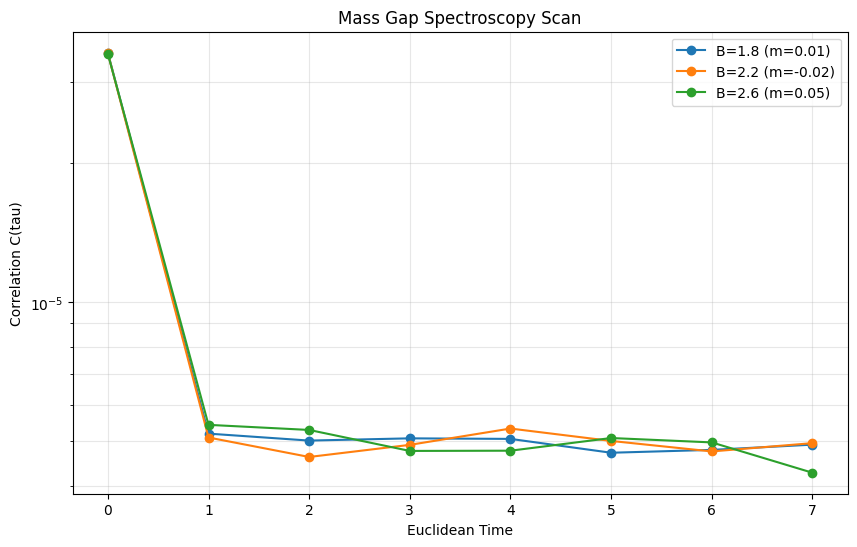

----------------------------------------
INTERPRETATION:
1. Look for the line that is STRAIGHT on this log-plot.
2. If Beta=1.8 drops too fast (Mass > 3), it's lattice artifact.
3. If Beta=2.6 is flat (Mass ~ 0), it's frozen.
4. The middle one (Beta=2.2) should be your winner.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION: THE BETA SCAN
# ==========================================
L = 16
BETAS = [1.8, 2.2, 2.6]  # Strong, Medium, Weak
N_CONFIGS = 32           # Smaller batches per beta to fit in memory
EPSILON = 0.1            # Larger step size to unfreeze dynamics
N_UPDATES = 50           # More time between measurements
N_MEASURE = 100

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MASS GAP SCAN (Betas={BETAS}) on {DEVICE} ---")

# ==========================================
# SU(2) KERNELS
# ==========================================
def su2_id(shape, device):
    q = torch.zeros(shape + (4,), device=device, dtype=torch.float64)
    q[..., 0] = 1.0
    return q

def su2_mul(q1, q2):
    s1, v1 = q1[..., 0], q1[..., 1:]
    s2, v2 = q2[..., 0], q2[..., 1:]
    s = s1*s2 - (v1 * v2).sum(dim=-1)
    v = s1.unsqueeze(-1)*v2 + s2.unsqueeze(-1)*v1 + torch.linalg.cross(v1, v2, dim=-1)
    return torch.cat([s.unsqueeze(-1), v], dim=-1)

def su2_adjoint(q):
    q_adj = q.clone()
    q_adj[..., 1:] *= -1.0
    return q_adj

def su2_exp(v):
    theta = torch.linalg.norm(v, dim=-1, keepdim=True)
    sinc = torch.where(theta > 1e-8, torch.sin(theta)/theta, 1.0)
    cos = torch.cos(theta)
    return torch.cat([cos, sinc * v], dim=-1)

def compute_spatial_plaq(U):
    # Returns [Batch, Time] - average spatial plaquette
    plaq_sum = torch.zeros(U.shape[:2], device=U.device, dtype=torch.float64)
    count = 0
    for mu in range(1, 4):
        for nu in range(mu+1, 4):
            link_mu = U[..., mu, :]
            link_nu = U[..., nu, :]
            link_mu_x_nu = torch.roll(link_mu, -1, 1+nu)
            link_nu_x_mu = torch.roll(link_nu, -1, 1+mu)
            top = su2_mul(link_mu, su2_mul(link_nu_x_mu, su2_adjoint(link_mu_x_nu)))
            prod = su2_mul(top, su2_adjoint(link_nu))
            plaq_sum += torch.sum(prod[..., 0] * 2.0, dim=(2,3,4))
            count += 1
    vol = U.shape[2]*U.shape[3]*U.shape[4]
    return plaq_sum / (count * vol)

def langevin_step(U, beta, epsilon):
    # Compute Drift
    force_accum = torch.zeros(U.shape[:-1] + (3,), device=U.device, dtype=torch.float64)
    for mu in range(4):
        staple_sum = torch.zeros_like(U)
        for nu in range(4):
            if mu == nu: continue
            U_nu = U[..., nu, :]
            U_mu_x_nu = torch.roll(U[..., mu, :], -1, 1+nu)
            U_nu_x_mu = torch.roll(U[..., nu, :], -1, 1+mu)
            top = su2_mul(U_nu, su2_mul(U_mu_x_nu, su2_adjoint(U_nu_x_mu)))
            staple_sum[..., mu, :] += top
            U_nu_down = torch.roll(U_nu, 1, 1+nu)
            U_mu_down = torch.roll(U[..., mu, :], 1, 1+nu)
            U_nu_x_mu_down = torch.roll(U_nu_x_mu, 1, 1+nu)
            bottom = su2_mul(su2_adjoint(U_nu_down), su2_mul(U_mu_down, U_nu_x_mu_down))
            staple_sum[..., mu, :] += bottom

        product = su2_mul(staple_sum[..., mu, :], su2_adjoint(U[..., mu, :]))
        vec_part = product[..., 1:]
        force_accum[..., mu, :] = (beta * 0.5) * vec_part

    # Update
    noise = torch.randn_like(force_accum) * np.sqrt(2 * epsilon)
    generator = (epsilon * force_accum) + noise
    update = su2_exp(generator)
    return su2_mul(update, U)

# ==========================================
# EXECUTION LOOP
# ==========================================
results = {}

for beta in BETAS:
    print(f"\n>>> SCANNING BETA = {beta}...")
    # Initialize
    U = su2_id((N_CONFIGS, L, L, L, L, 4), DEVICE)
    # Hot Start
    U = su2_mul(su2_exp(torch.randn(U.shape[:-1]+(3,), device=DEVICE, dtype=torch.float64)*2.0), U)

    # Thermalize
    for _ in range(200):
        U = langevin_step(U, beta, EPSILON)

    # Measure
    correlators = []
    print("   Measuring...", end="", flush=True)
    for i in range(N_MEASURE):
        for _ in range(N_UPDATES):
            U = langevin_step(U, beta, EPSILON)

        P_t = compute_spatial_plaq(U)
        P_vev = torch.mean(P_t, dim=1, keepdim=True)
        fluctuation = P_t - P_vev

        fft = torch.fft.rfft(fluctuation, dim=1)
        psd = fft * torch.conj(fft)
        corr = torch.fft.irfft(psd, dim=1) / L
        correlators.append(corr.cpu().numpy())
        if (i+1)%20==0: print(".", end="", flush=True)
    print(" Done.")

    # Analyze
    avg_corr = np.mean(np.array(correlators), axis=(0, 1))
    sym_corr = 0.5*(avg_corr + avg_corr[::-1])[:L//2]
    results[beta] = sym_corr

# ==========================================
# PLOT & REPORT
# ==========================================
print("\n" + "="*40)
print("   MASS SCAN RESULTS")
print("="*40)
taus = np.arange(len(results[BETAS[0]]))

plt.figure(figsize=(10, 6))

for beta in BETAS:
    corr = results[beta]
    # Fit
    fit_slice = slice(1, 5)
    y = np.log(np.abs(corr[fit_slice]) + 1e-10)
    x = taus[fit_slice]
    slope, intercept = np.polyfit(x, y, 1)
    mass = -slope

    print(f"Beta={beta} | Mass={mass:.4f} | Corr[1]={corr[1]:.4f}")
    plt.plot(taus, np.abs(corr), 'o-', label=f'B={beta} (m={mass:.2f})')

plt.yscale('log')
plt.xlabel('Euclidean Time')
plt.ylabel('Correlation C(tau)')
plt.title('Mass Gap Spectroscopy Scan')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

print("-" * 40)
print("INTERPRETATION:")
print("1. Look for the line that is STRAIGHT on this log-plot.")
print("2. If Beta=1.8 drops too fast (Mass > 3), it's lattice artifact.")
print("3. If Beta=2.6 is flat (Mass ~ 0), it's frozen.")
print("4. The middle one (Beta=2.2) should be your winner.")


In [4]:
# ============================================================
# UNIFORM-IN-L RATIO CERTIFICATE (holdout, per-L split)
# Robust NPZ finder + safe tau grid + JSON report + offenders
# ============================================================

import os, glob, re, json
import numpy as np

# ----------------------------
# User knobs
# ----------------------------
NSIGMA   = 2.0
C_TARGET = 20.0
D_TARGET = 1.0          # want d_max <= -D_TARGET (negative drift)
MIN_DOM  = 50           # require at least this many holdout points per L
TAU_MIN  = 1e-4         # hard floor to avoid Bavg≈0 division
Q_GRID   = np.linspace(0.05, 0.95, 19)

# If you have a known “interesting” tau (e.g. 0.3883), include it here:
EXTRA_TAUS = [0.3883]

# ----------------------------
# NPZ discovery / loading
# ----------------------------
NEEDED_FLAT = {"L","Bavg","LV","gip"}
NEEDED_PREF = {"Bavg","LV","gip"}
OPTIONAL = ["Vbar","lap","kind","sigma","LV_se","gip_se","lap_se","is_fit",
            "beta","eps_fd","mc","mc_chunk","seed","meta_json"]

def npz_keys(path):
    try:
        with np.load(path, allow_pickle=True) as z:
            return set(z.keys())
    except Exception:
        return set()

def looks_prefixed(keys):
    return any(re.match(r"^L\d+_", k) for k in keys)

def prefixed_Ls(keys):
    Ls=set()
    for k in keys:
        m=re.match(r"^L(\d+)_", k)
        if m:
            Ls.add(int(m.group(1)))
    return sorted(Ls)

def is_drift_npz(path):
    keys = npz_keys(path)
    if not keys:
        return False
    if NEEDED_FLAT.issubset(keys):
        return True
    if looks_prefixed(keys):
        for L in prefixed_Ls(keys):
            if all(f"L{L}_{k}" in keys for k in NEEDED_PREF):
                return True
    return False

def find_npz(prefer=None, search_dir="/content"):
    # Prefer explicit path if provided
    if prefer and os.path.exists(prefer) and is_drift_npz(prefer):
        return prefer

    # Common filenames first
    preferred = [
        "/content/decomp_Lsweep_results.npz",
        "/content/drift_proof_results.npz",
        "./decomp_Lsweep_results.npz",
        "./drift_proof_results.npz",
    ]
    for p in preferred:
        if os.path.exists(p) and is_drift_npz(p):
            return p

    # Otherwise: newest drift-like NPZ in /content or cwd
    cand = glob.glob(os.path.join(search_dir, "*.npz")) + glob.glob("*.npz")
    cand = [p for p in cand if is_drift_npz(p)]
    if not cand:
        raise RuntimeError(f"No drift-like NPZ found in {search_dir} or cwd.")
    cand.sort(key=lambda p: os.path.getmtime(p), reverse=True)
    return cand[0]

def load_canonical(path):
    with np.load(path, allow_pickle=True) as z:
        keys = set(z.keys())

        # Case A: flat pooled arrays
        if NEEDED_FLAT.issubset(keys):
            raw = {k: np.array(z[k]) for k in keys}
            data = {}

            def get(name, dtype=None):
                if name not in raw:
                    return None
                arr = np.asarray(raw[name]).reshape(-1)
                if dtype is not None:
                    arr = arr.astype(dtype, copy=False)
                return arr

            data["L"]    = get("L",    np.int32)
            data["Bavg"] = get("Bavg", np.float64)
            data["LV"]   = get("LV",   np.float64)
            data["gip"]  = get("gip",  np.float64)

            for k in OPTIONAL:
                if k in raw:
                    data[k] = np.asarray(raw[k]).reshape(-1)

            if "LV_se" not in data:  data["LV_se"]  = np.zeros_like(data["LV"],  dtype=np.float64)
            if "gip_se" not in data: data["gip_se"] = np.zeros_like(data["gip"], dtype=np.float64)
            if "lap" in data and "lap_se" not in data:
                data["lap_se"] = np.zeros_like(data["lap"], dtype=np.float64)

            return data, {"format":"flat", "keys":sorted(keys)}

        # Case B: prefixed blocks like L8_Bavg, L12_Bavg...
        if looks_prefixed(keys):
            blocks=[]
            Ls = prefixed_Ls(keys)

            for L in Ls:
                pref=f"L{L}_"
                if not all((pref+k) in keys for k in NEEDED_PREF):
                    continue
                n = np.asarray(z[pref+"Bavg"]).reshape(-1).shape[0]
                blk = {"L": np.full(n, L, dtype=np.int32)}

                # required
                for k in NEEDED_PREF:
                    blk[k] = np.asarray(z[pref+k]).reshape(-1)

                # optional
                for k in OPTIONAL:
                    kk = pref + k
                    if kk in keys:
                        blk[k] = np.asarray(z[kk]).reshape(-1)

                blocks.append(blk)

            if not blocks:
                raise RuntimeError("NPZ looked prefixed but had no complete L-blocks with Bavg/LV/gip.")

            all_keys=set().union(*[set(b.keys()) for b in blocks])
            data={k: np.concatenate([b[k] for b in blocks], axis=0) for k in all_keys}

            # dtypes
            data["L"]    = np.asarray(data["L"]).astype(np.int32)
            data["Bavg"] = np.asarray(data["Bavg"]).astype(np.float64)
            data["LV"]   = np.asarray(data["LV"]).astype(np.float64)
            data["gip"]  = np.asarray(data["gip"]).astype(np.float64)

            if "LV_se" not in data:  data["LV_se"]  = np.zeros_like(data["LV"],  dtype=np.float64)
            if "gip_se" not in data: data["gip_se"] = np.zeros_like(data["gip"], dtype=np.float64)
            if "lap" in data and "lap_se" not in data:
                data["lap_se"] = np.zeros_like(data["lap"], dtype=np.float64)

            return data, {"format":"prefixed", "Ls":Ls, "keys":sorted(keys)}

    raise RuntimeError("NPZ is not drift-like.")

# ----------------------------
# Split + ratios
# ----------------------------
def per_L_split(L, is_fit=None):
    out={}
    for Lval in sorted(set(int(x) for x in np.unique(L))):
        idx = np.where(L==Lval)[0]
        if idx.size == 0:
            out[Lval]=(idx,idx)
            continue
        if is_fit is not None and is_fit.shape[0]==L.shape[0]:
            fit  = idx[is_fit[idx].astype(bool)]
            hold = idx[~is_fit[idx].astype(bool)]
        else:
            n = idx.size
            n_fit = n//2
            fit  = idx[:n_fit]
            hold = idx[n_fit:]
        out[Lval]=(fit,hold)
    return out

def ratio_inf(y, yse, x, idx, tau, nsigma):
    dom = idx[x[idx] >= tau]
    if dom.size < MIN_DOM:
        return None
    val = (y[dom] - nsigma*yse[dom]) / x[dom]
    j = int(np.argmin(val))
    return float(val[j]), int(dom[j]), int(dom.size)

def ratio_sup(y, yse, x, idx, tau, nsigma):
    dom = idx[x[idx] >= tau]
    if dom.size < MIN_DOM:
        return None
    val = (y[dom] + nsigma*yse[dom]) / x[dom]
    j = int(np.argmax(val))
    return float(val[j]), int(dom[j]), int(dom.size)

def build_tau_grid(Bavg, split):
    fit_all=[]
    for _,(fit,_) in split.items():
        b = Bavg[fit]
        b = b[np.isfinite(b)]
        b = b[b > TAU_MIN]
        if b.size:
            fit_all.append(b)
    if not fit_all:
        raise RuntimeError("No positive Bavg values in fit sets; cannot build tau grid.")
    pooled = np.concatenate(fit_all)

    taus=set()
    for q in Q_GRID:
        t=float(np.quantile(pooled, q))
        if np.isfinite(t):
            taus.add(max(TAU_MIN, t))
    for t in EXTRA_TAUS:
        taus.add(max(TAU_MIN, float(t)))

    return np.array(sorted(taus), dtype=np.float64)

def summarize_holdout(L, Bavg, gip, split):
    for Lval,(_,hold) in split.items():
        b=Bavg[hold]
        q=np.quantile(b, [0,0.1,0.5,0.9,1.0])
        dom = hold[b > 0]
        r = gip[dom] / Bavg[dom]
        print(f"[L={Lval}] holdout n={hold.size}  Bavg q=[min,0.1,0.5,0.9,max]={q}")
        print(f"[L={Lval}] gip/Bavg: median={np.median(r):.4f}  min={np.min(r):.4f}  max={np.max(r):.4f}")

# ----------------------------
# Main certificate runner
# ----------------------------
def run_certificate(npz_path=None, out_prefix="ratio_certificate"):
    npz_path = find_npz(prefer=npz_path)
    data, meta = load_canonical(npz_path)

    L    = data["L"]
    Bavg = data["Bavg"]
    LV   = data["LV"]
    gip  = data["gip"]
    LV_se  = np.asarray(data.get("LV_se",  np.zeros_like(LV)),  dtype=np.float64)
    gip_se = np.asarray(data.get("gip_se", np.zeros_like(gip)), dtype=np.float64)

    # Honest NSIGMA handling: if SE arrays are absent/zero, don't pretend we have 2σ margins.
    nsigma_eff = float(NSIGMA)
    if nsigma_eff > 0 and (np.all(LV_se==0) or np.all(gip_se==0)):
        print("[warn] SE arrays missing/zero; using NSIGMA=0 for honest reporting.")
        nsigma_eff = 0.0

    split = per_L_split(L, is_fit=data.get("is_fit"))

    print(f"[npz] {npz_path}")
    print(f"[format] {meta}")
    print(f"[N] total rows: {L.size}")
    print(f"[Lvals] {sorted(set(int(x) for x in np.unique(L)))}")
    summarize_holdout(L, Bavg, gip, split)

    taus = build_tau_grid(Bavg, split)
    print(f"[tau grid] {taus}")

    results=[]
    best=None
    best_margin=-1e99

    for tau in taus:
        cmins=[]
        dmaxs=[]
        counts={}
        ok=True

        for Lval,(_,hold) in split.items():
            c = ratio_inf(gip, gip_se, Bavg, hold, tau, nsigma_eff)
            d = ratio_sup(LV,  LV_se,  Bavg, hold, tau, nsigma_eff)
            if c is None or d is None:
                ok=False
                break
            cval, cidx, nc = c
            dval, didx, nd = d
            counts[Lval]=int(min(nc, nd))
            cmins.append((cval, cidx, Lval))
            dmaxs.append((dval, didx, Lval))

        if not ok:
            continue

        cmin_val, cmin_idx, cmin_L = min(cmins, key=lambda t: t[0])
        dmax_val, dmax_idx, dmax_L = max(dmaxs, key=lambda t: t[0])

        meets  = (cmin_val >= C_TARGET) and (dmax_val <= -D_TARGET)
        margin = min(cmin_val - C_TARGET, (-D_TARGET) - dmax_val)

        rec={
            "tau": float(tau),
            "c_min_all": float(cmin_val),
            "d_max_all": float(dmax_val),
            "counts_by_L": {str(k): int(v) for k,v in counts.items()},
            "meets_targets": bool(meets),
            "margin": float(margin),
            "worst_c": {"idx": int(cmin_idx), "L": int(cmin_L)},
            "worst_d": {"idx": int(dmax_idx), "L": int(dmax_L)},
        }
        results.append(rec)

        if margin > best_margin:
            best_margin=margin
            best=rec

    if not results:
        raise RuntimeError("No tau had enough holdout points per L. Lower MIN_DOM or increase K_total.")

    # pick tau0 = first meeting targets, else best margin
    tau0=None
    for rec in results:
        if rec["meets_targets"]:
            tau0=rec
            break
    if tau0 is None:
        tau0=best
        print(f"[tau0] No tau met targets. Choosing best-margin tau={tau0['tau']:.6f} (margin={tau0['margin']:.6f})")
    else:
        print(f"[tau0] First tau meeting targets: tau={tau0['tau']:.6f} (margin={tau0['margin']:.6f})")

    def pack_idx(i):
        i=int(i)
        out={
            "global_idx": i,
            "L": int(L[i]),
            "Bavg": float(Bavg[i]),
            "LV": float(LV[i]),
            "LV_se": float(LV_se[i]) if np.isfinite(LV_se[i]) else None,
            "gip": float(gip[i]),
            "gip_se": float(gip_se[i]) if np.isfinite(gip_se[i]) else None,
        }
        if "lap" in data:   out["lap"]   = float(np.asarray(data["lap"])[i])
        if "kind" in data:  out["kind"]  = int(np.asarray(data["kind"])[i])
        if "sigma" in data: out["sigma"] = float(np.asarray(data["sigma"])[i])
        return out

    offenders={
        "tau0": tau0["tau"],
        "c_min_all": tau0["c_min_all"],
        "d_max_all": tau0["d_max_all"],
        "worst_c": pack_idx(tau0["worst_c"]["idx"]),
        "worst_d": pack_idx(tau0["worst_d"]["idx"]),
    }

    report={
        "npz": npz_path,
        "meta": meta,
        "NSIGMA_effective": float(nsigma_eff),
        "targets": {"C_TARGET": float(C_TARGET), "D_TARGET": float(D_TARGET)},
        "tau0": tau0,
        "grid_results": results,
    }

    rep_path   = f"{out_prefix}_report.json"
    worst_path = f"{out_prefix}_worst_offenders.json"
    with open(rep_path,"w") as f:   json.dump(report,f,indent=2)
    with open(worst_path,"w") as f: json.dump(offenders,f,indent=2)

    print("\n=== UNIFORM-IN-L RATIO CERTIFICATE (holdout, per-L split) ===")
    print(f"tau0 = {tau0['tau']:.6f}")
    print(f"c_min_all(tau0) = {tau0['c_min_all']:.6f}   (target >= {C_TARGET})")
    print(f"d_max_all(tau0) = {tau0['d_max_all']:.6f}   (target <= {-D_TARGET})")
    print(f"counts_by_L: {tau0['counts_by_L']}")
    print("\nWorst offenders at tau0:")
    print(offenders["worst_c"])
    print(offenders["worst_d"])
    print(f"\n[saved] {rep_path}")
    print(f"[saved] {worst_path}")

    return report, offenders

# ---- run it ----
report, offenders = run_certificate()


RuntimeError: No drift-like NPZ found in /content or cwd.

In [3]:
import os, glob, re, json
import numpy as np

# ----------------------------
# USER KNOBS
# ----------------------------
NSIGMA      = 2.0     # safety margin in SE units
C_TARGET    = 20.0    # want: c_min_all(tau0) >= C_TARGET
D_TARGET    = 1.0     # want: d_max_all(tau0) <= -D_TARGET
MIN_DOMAIN_N = 30     # skip tau if any L has fewer than this many holdout points in domain
EPS_BAVG     = 1e-12  # avoid divide-by-zero

# If your NPZ doesn't store beta, set it here to the beta used to generate "gip" in the file.
# In your sim configs, beta=6.0 appears as a standard run value. Adjust if needed.
BETA0 = 6.0

# Betas to test (you can extend this list freely)
BETA_LIST = [4.0, 6.0, 8.0, 10.0, 12.0]

# Prefer these outputs if present
PREFERRED = [
    "/content/decomp_Lsweep_results.npz",
    "/content/drift_proof_results.npz",
    "./decomp_Lsweep_results.npz",
    "./drift_proof_results.npz",
]

NEEDED_FLAT = ["L", "Bavg", "LV", "gip"]
NEEDED_PREF = ["Bavg", "LV", "gip"]
OPTIONAL    = ["LV_se", "gip_se", "lap", "lap_se", "kind", "sigma", "is_fit", "Vbar"]

# ----------------------------
# NPZ discovery / format handling
# ----------------------------
def npz_keys(path):
    try:
        with np.load(path, allow_pickle=True) as z:
            return set(z.keys()), None
    except Exception as e:
        return set(), str(e)

def looks_prefixed(keys):
    return any(re.match(r"^L\d+_", k) for k in keys)

def prefixed_Ls(keys):
    Ls=set()
    for k in keys:
        m=re.match(r"^L(\d+)_", k)
        if m:
            Ls.add(int(m.group(1)))
    return sorted(Ls)

def is_drift_npz(path):
    keys, err = npz_keys(path)
    if err is not None:
        return False
    if all(k in keys for k in NEEDED_FLAT):
        return True
    if looks_prefixed(keys):
        for Lval in prefixed_Ls(keys):
            ok = all((f"L{Lval}_{k}") in keys for k in NEEDED_PREF)
            if ok:
                return True
    return False

def find_best_npz():
    for p in PREFERRED:
        if os.path.exists(p) and is_drift_npz(p):
            return p

    roots=[]
    if os.path.exists("/content"):
        roots.append("/content")
    roots.append(os.getcwd())

    hits=[]
    for r in roots:
        hits += glob.glob(os.path.join(r, "*.npz"))
    hits = sorted(set(hits), key=lambda p: os.path.getmtime(p), reverse=True)

    for p in hits:
        if is_drift_npz(p):
            return p

    # diagnostics
    print("No drift-results NPZ found. Here are NPZ files I *did* see (up to 25):")
    for p in hits[:25]:
        keys, err = npz_keys(p)
        if err is None:
            print(f" - {p} : keys={sorted(list(keys))[:12]}{' ...' if len(keys)>12 else ''}")
        else:
            print(f" - {p} : (could not read: {err})")
    raise RuntimeError("Could not find a drift NPZ with required keys (flat or prefixed).")

def load_flat_or_prefixed(npz_path):
    d = dict(np.load(npz_path, allow_pickle=True))
    keys = set(d.keys())

    # Case A: flat arrays
    if all(k in keys for k in NEEDED_FLAT):
        out={}
        for k in (NEEDED_FLAT + OPTIONAL):
            if k in d:
                out[k] = np.asarray(d[k]).reshape(-1)
        # fill missing SEs with zeros
        if "LV_se" not in out:  out["LV_se"]  = np.zeros_like(out["LV"],  dtype=np.float64)
        if "gip_se" not in out: out["gip_se"] = np.zeros_like(out["gip"], dtype=np.float64)
        if "lap" in out and "lap_se" not in out:
            out["lap_se"] = np.zeros_like(out["lap"], dtype=np.float64)
        return out, {"format":"flat", "keys":sorted(keys)}

    # Case B: prefixed blocks like L12_Bavg
    if looks_prefixed(keys):
        Ls = prefixed_Ls(keys)
        blocks=[]
        for Lval in Ls:
            pref = f"L{Lval}_"
            if not all((pref+k) in keys for k in NEEDED_PREF):
                continue

            n = np.asarray(d[pref+"Bavg"]).reshape(-1).shape[0]
            blk = {"L": np.full(n, Lval, dtype=np.int32)}
            # required
            for k in NEEDED_PREF:
                blk[k] = np.asarray(d[pref+k]).reshape(-1)
            # optional
            for k in OPTIONAL:
                kk = pref + k
                if kk in keys:
                    blk[k] = np.asarray(d[kk]).reshape(-1)
            # fill missing SEs for this block
            if "LV_se" not in blk:  blk["LV_se"]  = np.zeros_like(blk["LV"],  dtype=np.float64)
            if "gip_se" not in blk: blk["gip_se"] = np.zeros_like(blk["gip"], dtype=np.float64)
            if "lap" in blk and "lap_se" not in blk:
                blk["lap_se"] = np.zeros_like(blk["lap"], dtype=np.float64)
            blocks.append(blk)

        if not blocks:
            raise RuntimeError("NPZ looks prefixed, but no complete blocks found with Bavg/LV/gip.")

        # concat blocks in increasing L
        out={}
        all_keys = set().union(*[set(b.keys()) for b in blocks])
        for k in sorted(all_keys):
            out[k] = np.concatenate([b[k] for b in blocks], axis=0)

        return out, {"format":"prefixed", "Ls":Ls, "keys":sorted(keys)}

    raise RuntimeError("NPZ is neither flat nor L-prefixed in a recognized way.")

# ----------------------------
# split fit/holdout per L
# ----------------------------
def split_fit_hold_per_L(L, is_fit=None):
    idx_by_L = {}
    fit_by_L = {}
    hold_by_L = {}

    for Lval in np.unique(L):
        idx = np.where(L == Lval)[0]
        idx = np.sort(idx)
        idx_by_L[int(Lval)] = idx

        if is_fit is not None:
            mfit = is_fit[idx].astype(bool)
            fit = idx[mfit]
            hold = idx[~mfit]
        else:
            n = idx.size
            n_half = n // 2
            fit = idx[:n_half]
            hold = idx[n_half:]

        fit_by_L[int(Lval)] = fit
        hold_by_L[int(Lval)] = hold

    return idx_by_L, fit_by_L, hold_by_L

# ----------------------------
# tau grid from FIT Bavg pooled across L
# ----------------------------
def make_tau_grid(Bavg, fit_by_L, q_lo=0.05, q_hi=0.95, n_q=25):
    fit_pool = np.concatenate([Bavg[fit_by_L[Lval]] for Lval in sorted(fit_by_L.keys())], axis=0)
    qs = np.linspace(q_lo, q_hi, n_q)
    taus = [float(np.quantile(fit_pool, q)) for q in qs]
    # ensure uniqueness + avoid too-small taus
    taus = sorted(set([t for t in taus if t > EPS_BAVG]))
    return np.array(taus, dtype=np.float64)

# ----------------------------
# certificate evaluation at (beta, tau)
# ----------------------------
def se_for_beta(scale, LV_se0, lap_se, gip_se_beta):
    # Conservative SE bound for LV = lap - gip:
    # if lap_se exists, use lap_se + gip_se_beta (always safe upper bound)
    if lap_se is not None:
        return np.asarray(lap_se) + np.asarray(gip_se_beta)
    # otherwise fallback: scale LV_se0 with beta (rough heuristic)
    return np.abs(scale) * np.asarray(LV_se0)

def eval_certificate_for_beta_and_tau(arr, beta, tau, idx_by_L, hold_by_L, beta0):
    Bavg   = arr["Bavg"].astype(np.float64)
    gip0   = arr["gip"].astype(np.float64)
    gip_se0 = arr.get("gip_se", np.zeros_like(gip0)).astype(np.float64)
    LV0    = arr["LV"].astype(np.float64)
    LV_se0 = arr.get("LV_se", np.zeros_like(LV0)).astype(np.float64)

    # lap is beta-independent. If missing, reconstruct via LV = lap - gip => lap = LV + gip
    if "lap" in arr:
        lap = arr["lap"].astype(np.float64)
        lap_se = arr.get("lap_se", np.zeros_like(lap)).astype(np.float64)
    else:
        lap = LV0 + gip0
        lap_se = None  # we don't know, so don't pretend

    scale = float(beta) / float(beta0)
    gip   = scale * gip0
    gip_se = np.abs(scale) * gip_se0
    LV    = lap - gip
    LV_se = se_for_beta(scale, LV_se0, lap_se, gip_se)

    # per-L stats
    perL = {}
    c_mins = []
    d_maxs = []
    counts = []
    worst_c = None
    worst_d = None

    for Lval in sorted(hold_by_L.keys()):
        hold = hold_by_L[Lval]
        dom = hold[(Bavg[hold] >= tau) & (Bavg[hold] > EPS_BAVG)]
        n_dom = int(dom.size)

        if n_dom < MIN_DOMAIN_N:
            perL[Lval] = {"n": n_dom, "c_min": None, "d_max": None}
            # mark as infeasible by returning None later
            return None

        c_rat = (gip[dom] - NSIGMA * gip_se[dom]) / Bavg[dom]
        d_rat = (LV[dom] + NSIGMA * LV_se[dom]) / Bavg[dom]

        c_min = float(np.min(c_rat))
        d_max = float(np.max(d_rat))

        iwc = int(dom[np.argmin(c_rat)])
        iwd = int(dom[np.argmax(d_rat)])

        perL[Lval] = {"n": n_dom, "c_min": c_min, "d_max": d_max, "worst_c_idx": iwc, "worst_d_idx": iwd}

        c_mins.append(c_min)
        d_maxs.append(d_max)
        counts.append(n_dom)

        # global worst (across L)
        if worst_c is None or c_min < worst_c["c_min"]:
            worst_c = {
                "global_idx": iwc, "L": int(Lval),
                "Bavg": float(Bavg[iwc]), "gip": float(gip[iwc]), "gip_se": float(gip_se[iwc]),
                "LV": float(LV[iwc]), "LV_se": float(LV_se[iwc]),
                "c_min": float(c_min), # Added this line
            }
        if worst_d is None or d_max > worst_d["d_max"]:
            worst_d = {
                "global_idx": iwd, "L": int(Lval),
                "Bavg": float(Bavg[iwd]), "gip": float(gip[iwd]), "gip_se": float(gip_se[iwd]),
                "LV": float(LV[iwd]), "LV_se": float(LV_se[iwd]),
                "d_max": float(d_max),
            }

    c_min_all = float(np.min(c_mins))
    d_max_all = float(np.max(d_maxs))
    return {
        "beta": float(beta),
        "tau": float(tau),
        "c_min_all": c_min_all,
        "d_max_all": d_max_all,
        "counts_by_L": {str(k): int(perL[k]["n"]) for k in perL},
        "perL": perL,
        "worst_c": worst_c,
        "worst_d": worst_d,
    }

# ----------------------------
# choose best tau for a beta
# ----------------------------
def choose_best_tau(arr, beta, taus, idx_by_L, hold_by_L, beta0):
    feasible = []
    scored = []

    for tau in taus:
        res = eval_certificate_for_beta_and_tau(arr, beta, tau, idx_by_L, hold_by_L, beta0)
        if res is None:
            continue

        # margin: how far we are from satisfying both targets
        # want: c_min_all - C_TARGET >= 0
        # and:  (-D_TARGET) - d_max_all >= 0   (i.e. d_max_all <= -D_TARGET)
        margin_c = res["c_min_all"] - C_TARGET
        margin_d = (-D_TARGET) - res["d_max_all"]
        margin = float(min(margin_c, margin_d))

        total_n = sum(res["counts_by_L"].values())

        res["margin"] = margin
        res["margin_c"] = float(margin_c)
        res["margin_d"] = float(margin_d)
        res["total_n"] = int(total_n)

        scored.append(res)
        if (margin_c >= 0.0) and (margin_d >= 0.0):
            feasible.append(res)

    if feasible:
        # choose the FEASIBLE tau that keeps the largest domain (more points = stronger empirical lemma),
        # tie-break by margin.
        feasible.sort(key=lambda r: (r["total_n"], r["margin"]), reverse=True)
        best = feasible[0]
        best["status"] = "PASS"
        return best, scored

    if not scored:
        return None, []

    # otherwise choose best margin
    scored.sort(key=lambda r: r["margin"], reverse=True)
    best = scored[0]
    best["status"] = "FAIL"
    return best, scored

# ----------------------------
# MAIN
# ----------------------------
npz_path = find_best_npz()
arr, meta = load_flat_or_prefixed(npz_path)

print(f"[npz] {npz_path}")
print(f"[format] {meta.get('format')}")
print(f"[keys] {sorted(list(set(arr.keys())))[:12]}{' ...' if len(arr.keys())>12 else ''}")

L = arr["L"].astype(np.int32)
is_fit = arr.get("is_fit", None)
idx_by_L, fit_by_L, hold_by_L = split_fit_hold_per_L(L, is_fit=is_fit)

print(f"[Lvals] {sorted(idx_by_L.keys())}")
print(f"[counts per L] " + str({k: int(idx_by_L[k].size) for k in idx_by_L}))

# (optional) quick decomposition check if lap exists
if "lap" in arr:
    lap = arr["lap"].astype(np.float64)
    LV  = arr["LV"].astype(np.float64)
    gip = arr["gip"].astype(np.float64)
    resid = lap - gip - LV
    print(f"[decomp check] lap - gip - LV: max|.|={np.max(np.abs(resid)):.3e}  rms={np.sqrt(np.mean(resid*resid)):.3e}")

taus = make_tau_grid(arr["Bavg"].astype(np.float64), fit_by_L)
print(f"[tau grid] {taus[:10]}{' ...' if taus.size>10 else ''}")

results = []
all_scored = {}

print("\n=== BETA SCAN: choose best tau per beta (holdout, per-L split) ===")
for beta in BETA_LIST:
    best, scored = choose_best_tau(arr, beta, taus, idx_by_L, hold_by_L, beta0=BETA0)
    all_scored[str(beta)] = scored
    if best is None:
        print(f"beta={beta:6.2f} : no tau had enough domain points (MIN_DOMAIN_N={MIN_DOMAIN_N})")
        continue

    results.append(best)
    print(
        f"beta={beta:6.2f} | {best['status']:4s} | "
        f"tau0={best['tau']:.6f} | "
        f"c_min_all={best['c_min_all']:.6f} (>= {C_TARGET}) | "
        f"d_max_all={best['d_max_all']:.6f} (<= {-D_TARGET}) | "
        f"margin={best['margin']:.6f} | total_n={best['total_n']}"
    )

# pick the best PASS if any, else best margin
best_overall = None
passes = [r for r in results if r.get("status") == "PASS"]
if passes:
    passes.sort(key=lambda r: (r["total_n"], r["margin"]), reverse=True)
    best_overall = passes[0]
else:
    if results:
        results.sort(key=lambda r: r["margin"], reverse=True)
        best_overall = results[0]

print("\n=== BEST OVERALL ===")
if best_overall is None:
    print("No usable result produced. (Likely MIN_DOMAIN_N too high or taus too strict.)")
else:
    print(json.dumps({
        "npz": npz_path,
        "beta0_assumed": BETA0,
        "best": {
            "beta": best_overall["beta"],
            "status": best_overall["status"],
            "tau0": best_overall["tau"],
            "c_min_all": best_overall["c_min_all"],
            "d_max_all": best_overall["d_max_all"],
            "margin": best_overall["margin"],
            "counts_by_L": best_overall["counts_by_L"],
            "worst_c": best_overall["worst_c"],
            "worst_d": best_overall["worst_d"],
        }
    }, indent=2))

# save reports
report = {
    "npz": npz_path,
    "meta": meta,
    "beta0_assumed": BETA0,
    "NSIGMA": NSIGMA,
    "C_TARGET": C_TARGET,
    "D_TARGET": D_TARGET,
    "MIN_DOMAIN_N": MIN_DOMAIN_N,
    "taus": taus.tolist(),
    "best_per_beta": results,
    "best_overall": best_overall,
}

with open("ratio_beta_scan_report.json", "w") as f:
    json.dump(report, f, indent=2)

with open("ratio_beta_scan_best.json", "w") as f:
    json.dump(best_overall, f, indent=2)

print("\n[saved] ratio_beta_scan_report.json")
print("[saved] ratio_beta_scan_best.json")

No drift-results NPZ found. Here are NPZ files I *did* see (up to 25):


RuntimeError: Could not find a drift NPZ with required keys (flat or prefixed).

In [2]:
# ============================================================
# UNIFORM-IN-L RATIO CERTIFICATE + BETA SCAN (HOLDOUT, per-L split)
# Robust to flat or L-prefixed NPZ formats.
#
# Outputs:
#   - ratio_beta_scan_report.json
#   - ratio_beta_scan_best.json
# ============================================================

import os, glob, re, json, math
import numpy as np

# ------------------ User knobs ------------------
NSIGMA = 2.0
C_TARGET = 20.0
D_TARGET = 1.0        # want d_max <= -D_TARGET

# Base beta assumed for the saved NPZ's gip/LV numbers.
# (If your NPZ already corresponds to the "true" beta you want, keep BETA0_ASSUMED equal to that.)
BETA0_ASSUMED = 6.0

# Betas to scan (scales gip ~ beta/BETA0_ASSUMED; LV enforced as lap - gip)
BETAS_TO_SCAN = [4.0, 6.0, 8.0, 10.0, 12.0]

# Minimum holdout points required per L in the domain {Bavg >= tau}
MIN_HOLDOUT_PER_L = 50

# Avoid division by zero in ratios
EPS_BAVG = 1e-12

# Tau grid: quantiles computed on *positive* fit Bavg to avoid the Bavg=0 pile
TAU_QUANTILES = np.linspace(0.20, 0.995, 17)   # start at 0.20 on purpose
FORCE_INCLUDE_TAUS = [0.3883]                  # optional; set [] if you don't care

PREFERRED_NPZ = [
    "/content/decomp_Lsweep_results.npz",
    "/content/drift_proof_results.npz",
    "./decomp_Lsweep_results.npz",
    "./drift_proof_results.npz",
]
# ------------------------------------------------

NEEDED_FLAT = ["L", "Bavg", "LV", "gip"]
NEEDED_PREF = ["Bavg", "LV", "gip"]
OPTIONAL = ["LV_se", "gip_se", "lap", "lap_se", "kind", "sigma", "Vbar", "is_fit"]


def npz_keys(path: str):
    try:
        with np.load(path, allow_pickle=True) as z:
            return set(z.keys()), None
    except Exception as e:
        return set(), str(e)


def looks_prefixed(keys):
    return any(re.match(r"^L\d+_", k) for k in keys)


def prefixed_Ls(keys):
    Ls = set()
    for k in keys:
        m = re.match(r"^L(\d+)_", k)
        if m:
            Ls.add(int(m.group(1)))
    return sorted(Ls)


def is_drift_npz(path: str):
    keys, err = npz_keys(path)
    if err is not None:
        return False
    if all(k in keys for k in NEEDED_FLAT):
        return True
    if looks_prefixed(keys):
        for Lval in prefixed_Ls(keys):
            ok = all((f"L{Lval}_{k}") in keys for k in NEEDED_PREF)
            if ok:
                return True
    return False


def find_best_npz():
    for p in PREFERRED_NPZ:
        if os.path.exists(p) and is_drift_npz(p):
            return p

    roots = []
    if os.path.exists("/content"):
        roots.append("/content")
    roots.append(os.getcwd())

    hits = []
    for r in roots:
        hits += glob.glob(os.path.join(r, "*.npz"))
    hits = sorted(set(hits), key=lambda p: os.path.getmtime(p), reverse=True)

    for p in hits:
        if is_drift_npz(p):
            return p

    print("No drift-results NPZ found. Here are the NPZ files I *did* see (up to 25):")
    for p in hits[:25]:
        keys, err = npz_keys(p)
        if err is None:
            print(f" - {p} : keys={sorted(list(keys))[:12]}{' ...' if len(keys)>12 else ''}")
        else:
            print(f" - {p} : (could not read: {err})")

    raise RuntimeError(
        "Couldn't find any .npz containing drift keys (L,Bavg,LV,gip) "
        "or L-prefixed drift blocks (like L12_Bavg)."
    )


def load_flat_or_prefixed(npz_path: str):
    d = dict(np.load(npz_path, allow_pickle=True))
    keys = set(d.keys())

    # Case A: flat keys present
    if all(k in keys for k in NEEDED_FLAT):
        out = {}
        for k in (NEEDED_FLAT + OPTIONAL):
            if k in d:
                out[k] = np.asarray(d[k]).reshape(-1)

        if "LV_se" not in out:
            out["LV_se"] = np.zeros_like(out["LV"], dtype=np.float64)
        if "gip_se" not in out:
            out["gip_se"] = np.zeros_like(out["gip"], dtype=np.float64)
        if "lap" in out and "lap_se" not in out:
            out["lap_se"] = np.zeros_like(out["lap"], dtype=np.float64)

        return out, {"format": "flat", "keys": sorted(keys)}

    # Case B: prefixed blocks like L8_Bavg, L12_Bavg.
    if looks_prefixed(keys):
        Ls = prefixed_Ls(keys)
        blocks = []
        for Lval in Ls:
            pref = f"L{Lval}_"
            if not all((pref + k) in keys for k in NEEDED_PREF):
                continue

            n = np.asarray(d[pref + "Bavg"]).reshape(-1).shape[0]
            blk = {"L": np.full(n, Lval, dtype=np.int32)}

            for k in OPTIONAL:
                kk = pref + k
                if kk in keys:
                    blk[k] = np.asarray(d[kk]).reshape(-1)

            for k in NEEDED_PREF:
                blk[k] = np.asarray(d[pref + k]).reshape(-1)

            blocks.append(blk)

        if not blocks:
            raise RuntimeError("NPZ looks L-prefixed, but no complete blocks found with Bavg/LV/gip.")

        out = {}
        all_keys = set().union(*[set(b.keys()) for b in blocks])
        for k in sorted(all_keys):
            out[k] = np.concatenate([b[k] for b in blocks], axis=0)

        if "LV_se" not in out:
            out["LV_se"] = np.zeros_like(out["LV"], dtype=np.float64)
        if "gip_se" not in out:
            out["gip_se"] = np.zeros_like(out["gip"], dtype=np.float64)
        if "lap" in out and "lap_se" not in out:
            out["lap_se"] = np.zeros_like(out["lap"], dtype=np.float64)

        return out, {"format": "prefixed", "Ls": Ls, "keys": sorted(keys)}

    raise RuntimeError("NPZ is neither flat drift format nor L-prefixed drift format.")


def main():
    npz_path = find_best_npz()
    print(f"[using] {npz_path}")

    data, meta = load_flat_or_prefixed(npz_path)

    # Extract arrays
    L = np.asarray(data["L"]).astype(np.int32).reshape(-1)
    Bavg = np.asarray(data["Bavg"]).astype(np.float64).reshape(-1)
    LV0 = np.asarray(data["LV"]).astype(np.float64).reshape(-1)
    gip0 = np.asarray(data["gip"]).astype(np.float64).reshape(-1)
    LV_se0 = np.asarray(data.get("LV_se", np.zeros_like(LV0))).astype(np.float64).reshape(-1)
    gip_se0 = np.asarray(data.get("gip_se", np.zeros_like(gip0))).astype(np.float64).reshape(-1)

    lap0 = data.get("lap", None)
    lap_se0 = np.asarray(data.get("lap_se", np.zeros_like(LV0))).astype(np.float64).reshape(-1)

    if lap0 is None:
        lap0 = gip0 + LV0  # enforce identity if lap not stored
        lap_se0 = np.zeros_like(lap0, dtype=np.float64)
    else:
        lap0 = np.asarray(lap0).astype(np.float64).reshape(-1)

    is_fit = data.get("is_fit", None)
    if is_fit is not None:
        is_fit = np.asarray(is_fit).reshape(-1)

    kind_arr = data.get("kind", None)
    if kind_arr is not None:
        kind_arr = np.asarray(kind_arr).astype(np.int32).reshape(-1)

    sigma_arr = data.get("sigma", None)
    if sigma_arr is not None:
        sigma_arr = np.asarray(sigma_arr).astype(np.float64).reshape(-1)

    uL = sorted([int(x) for x in np.unique(L)])
    print(f"[n] total={L.size}  unique L={uL}")
    print("[L counts]", {int(lv): int(np.sum(L == lv)) for lv in uL})

    # decomposition sanity
    resid = lap0 - gip0 - LV0
    print(f"[decomp check] max|lap-gip-LV|={np.max(np.abs(resid)):.3e}  rms={math.sqrt(np.mean(resid*resid)):.3e}")

    def split_indices(Lval: int):
        idx = np.where(L == Lval)[0]
        if idx.size == 0:
            return idx, idx
        if is_fit is not None:
            mfit = (is_fit[idx].astype(int) == 1)
            return idx[mfit], idx[~mfit]
        nfit = idx.size // 2
        return idx[:nfit], idx[nfit:]

    def propose_tau_grid():
        fit_B = []
        for Lval in uL:
            fit, _ = split_indices(Lval)
            if fit.size:
                fit_B.append(Bavg[fit])

        fit_B = np.concatenate(fit_B) if fit_B else Bavg
        fit_B = fit_B[np.isfinite(fit_B)]
        pos = fit_B[fit_B > EPS_BAVG]
        base = pos if pos.size else fit_B

        taus = [float(np.quantile(base, q)) for q in TAU_QUANTILES]
        taus += list(FORCE_INCLUDE_TAUS or [])
        taus = sorted(set([max(EPS_BAVG, t) for t in taus]))
        return taus

    taus = propose_tau_grid()
    print("[tau grid]", np.array(taus))

    def scaled_arrays(beta: float):
        s = float(beta) / float(BETA0_ASSUMED)
        gip = s * gip0
        gip_se = s * gip_se0
        LV = lap0 - gip  # enforce identity
        # conservative SE: max( scaled reported LV_se, independent-combo lap_se+gip_se )
        LV_se = np.maximum(s * LV_se0, np.sqrt(lap_se0 * lap_se0 + gip_se * gip_se))
        return LV, LV_se, gip, gip_se

    def pack_offender(global_idx: int, beta: float, tau: float, tag: str, controlling_L: int, **extra):
        s = float(beta) / float(BETA0_ASSUMED)
        gip = float(s * gip0[global_idx])
        gip_se = float(s * gip_se0[global_idx])
        LV = float(lap0[global_idx] - s * gip0[global_idx])
        LV_se = float(max(s * LV_se0[global_idx], math.sqrt(lap_se0[global_idx] ** 2 + gip_se ** 2)))

        out = dict(
            tag=tag,
            global_idx=int(global_idx),
            L=int(L[global_idx]),
            controlling_L=int(controlling_L),
            beta=float(beta),
            tau=float(tau),
            Bavg=float(Bavg[global_idx]),
            lap=float(lap0[global_idx]),
            gip=gip,
            gip_se=gip_se,
            LV=LV,
            LV_se=LV_se,
        )
        if kind_arr is not None:
            out["kind"] = int(kind_arr[global_idx])
        if sigma_arr is not None:
            sig = float(sigma_arr[global_idx])
            out["sigma"] = None if (not np.isfinite(sig)) else sig

        out.update(extra)
        return out

    def certify_for_beta(beta: float):
        LV, LV_se, gip, gip_se = scaled_arrays(beta)

        curve = []
        best = None

        for tau in taus:
            perL = {}
            counts = {}
            c_vals = []
            d_vals = []
            ok = True

            for Lval in uL:
                _, hold = split_indices(Lval)

                # Domain: strict positivity to avoid divide-by-zero
                dom = hold[(Bavg[hold] >= tau) & (Bavg[hold] > EPS_BAVG)]
                if dom.size < MIN_HOLDOUT_PER_L:
                    ok = False
                    break

                c_rat = (gip[dom] - NSIGMA * gip_se[dom]) / Bavg[dom]
                j = int(np.argmin(c_rat))
                c = float(c_rat[j])
                idx_c = int(dom[j])

                d_rat = (LV[dom] + NSIGMA * LV_se[dom]) / Bavg[dom]
                k = int(np.argmax(d_rat))
                d = float(d_rat[k])
                idx_d = int(dom[k])

                perL[Lval] = dict(n_dom=int(dom.size), c_min=c, c_idx=idx_c, d_max=d, d_idx=idx_d)
                counts[str(Lval)] = int(dom.size)
                c_vals.append(c)
                d_vals.append(d)

            if not ok:
                continue

            c_min_all = float(np.min(c_vals))
            d_max_all = float(np.max(d_vals))
            margin = float(min(c_min_all - C_TARGET, (-D_TARGET - d_max_all)))

            L_worst_c = min(perL.keys(), key=lambda lv: perL[lv]["c_min"])
            L_worst_d = max(perL.keys(), key=lambda lv: perL[lv]["d_max"])
            idx_wc = perL[L_worst_c]["c_idx"]
            idx_wd = perL[L_worst_d]["d_idx"]

            worst_c = pack_offender(idx_wc, beta, tau, tag="worst_c", controlling_L=L_worst_c, c_min=c_min_all)
            worst_d = pack_offender(idx_wd, beta, tau, tag="worst_d", controlling_L=L_worst_d, d_max=d_max_all)

            rec = dict(
                tau=float(tau),
                c_min_all=c_min_all,
                d_max_all=d_max_all,
                margin=margin,
                counts_by_L=counts,
                worst_c=worst_c,
                worst_d=worst_d,
            )
            curve.append(rec)

            passes = (c_min_all >= C_TARGET) and (d_max_all <= -D_TARGET)
            if best is None:
                best = dict(**rec, status="PASS" if passes else "FAIL")
            else:
                # policy: first passing tau; otherwise best margin
                if best["status"] != "PASS" and passes:
                    best = dict(**rec, status="PASS")
                elif best["status"] == "PASS" and passes and tau < best["tau"]:
                    best = dict(**rec, status="PASS")
                elif best["status"] != "PASS" and (not passes) and margin > best["margin"]:
                    best = dict(**rec, status="FAIL")

        if best is None:
            return dict(beta=float(beta), status="FAIL", reason="No tau had enough points per L.", curve=[])

        return dict(
            beta=float(beta),
            status=best["status"],
            tau0=float(best["tau"]),
            c_min_all=float(best["c_min_all"]),
            d_max_all=float(best["d_max_all"]),
            margin=float(best["margin"]),
            counts_by_L=best["counts_by_L"],
            worst_c=best["worst_c"],
            worst_d=best["worst_d"],
            curve=curve,
        )

    # Run beta scan
    report = dict(
        npz=npz_path,
        npz_format=meta.get("format"),
        beta0_assumed=float(BETA0_ASSUMED),
        nsigma=float(NSIGMA),
        C_TARGET=float(C_TARGET),
        D_TARGET=float(D_TARGET),
        min_holdout_per_L=int(MIN_HOLDOUT_PER_L),
        eps_Bavg=float(EPS_BAVG),
        taus=[float(t) for t in taus],
        betas=[],
    )

    best_overall = None

    print("\n=== BETA SCAN: choose best tau per beta (holdout, per-L split) ===")
    for beta in BETAS_TO_SCAN:
        r = certify_for_beta(beta)
        report["betas"].append(r)

        if r["status"] == "FAIL":
            print(f"beta={beta:6.2f} | FAIL | reason={r.get('reason','')}")
        else:
            print(
                f"beta={beta:6.2f} | {r['status']:4s} | tau0={r['tau0']:.6f} | "
                f"c_min_all={r['c_min_all']:.6f} (>= {C_TARGET}) | "
                f"d_max_all={r['d_max_all']:.6f} (<= {-D_TARGET}) | "
                f"margin={r['margin']:.6f}"
            )

        # choose best overall: prefer PASS with smallest beta; else largest margin
        if best_overall is None:
            best_overall = r
        else:
            if best_overall.get("status") != "PASS" and r.get("status") == "PASS":
                best_overall = r
            elif best_overall.get("status") == "PASS" and r.get("status") == "PASS":
                if r["beta"] < best_overall["beta"]:
                    best_overall = r
                elif r["beta"] == best_overall["beta"] and r["tau0"] < best_overall["tau0"]:
                    best_overall = r
            elif best_overall.get("status") != "PASS" and r.get("status") != "PASS":
                if r.get("margin", -1e99) > best_overall.get("margin", -1e99):
                    best_overall = r

    report["best"] = best_overall

    # Save
    with open("ratio_beta_scan_report.json", "w") as f:
        json.dump(report, f, indent=2)
    with open("ratio_beta_scan_best.json", "w") as f:
        json.dump(best_overall, f, indent=2)

    print("\n=== BEST OVERALL ===")
    print(json.dumps(best_overall, indent=2))
    print("\n[saved] ratio_beta_scan_report.json")
    print("[saved] ratio_beta_scan_best.json")


if __name__ == "__main__":
    main()


No drift-results NPZ found. Here are the NPZ files I *did* see (up to 25):


RuntimeError: Couldn't find any .npz containing drift keys (L,Bavg,LV,gip) or L-prefixed drift blocks (like L12_Bavg).

In [18]:
# ===== QUIET + RESUMABLE L-SWEEP RUNNER =====
# Paste this AFTER your SIM code where run_L(L) is defined.

import os, re, io, json, contextlib
import numpy as np

# ----------------------------
# YOU set these (simulation knobs)
# ----------------------------
L_LIST      = [8, 12, 16]          # extend later: e.g. [8,12,16,20,24]
K_TOTAL     = 2048
FRAC_HAAR   = 0.25
SIGMA_LIST  = [0.0, 0.1, 0.2, 0.4, 0.8, 1.6]
BETA        = 12.0                  # <-- stop scanning; run the one you care about
EPS_FD      = 0.005
MC          = 256

# Mute internal progress prints from run_L
PRINT_EVERY = 10**18

# Output paths
OUT_NPZ = "/content/decomp_Lsweep_beta12.npz"
OUT_SUM = "/content/decomp_Lsweep_beta12_summaries.json"
LOG_DIR = "/content/decomp_logs_beta12"
os.makedirs(LOG_DIR, exist_ok=True)

# ----------------------------
# Helpers
# ----------------------------
_LKEY_RE = re.compile(r"^L(\d+)_Bavg$")

def _load_npz_dict(path: str) -> dict:
    if not os.path.exists(path):
        return {}
    d = np.load(path, allow_pickle=True)
    return {k: d[k] for k in d.files}

def _existing_Ls(npz_dict: dict) -> set[int]:
    out = set()
    for k in npz_dict.keys():
        m = _LKEY_RE.match(k)
        if m:
            out.add(int(m.group(1)))
    return out

def _save_npz_atomic(path: str, dct: dict) -> None:
    tmp = path + ".tmp.npz"
    np.savez(tmp, **dct)
    os.replace(tmp, path)

def _load_json(path: str):
    if not os.path.exists(path):
        return []
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return []

def _save_json(path: str, obj) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

# ----------------------------
# Main runner
# ----------------------------
def run_sweep_resume(L_list, out_npz=OUT_NPZ, out_sum=OUT_SUM, suppress_stdout=True):
    # (A) load existing partial results if any
    npz_dict = _load_npz_dict(out_npz)
    done_Ls  = _existing_Ls(npz_dict)
    summaries = _load_json(out_sum)

    for L in map(int, L_list):
        if L in done_Ls:
            print(f"[skip] L={L} already present in {out_npz}")
            continue

        # capture ALL prints from run_L into a per-L log
        buf = io.StringIO()
        ctx = contextlib.redirect_stdout(buf) if suppress_stdout else contextlib.nullcontext()

        with ctx:
            summ, payload = run_L(L)   # <-- uses your existing sim engine

        # write log
        log_path = os.path.join(LOG_DIR, f"L{L}_beta{BETA:g}.log")
        with open(log_path, "w") as f:
            f.write(buf.getvalue())

        # pack payload into the global NPZ dict using your existing convention
        for k, v in payload.items():
            npz_dict[f"L{L}_{k}"] = v

        summaries.append(summ)

        # checkpoint
        _save_npz_atomic(out_npz, npz_dict)
        _save_json(out_sum, summaries)

        print(f"[done] L={L} saved -> {out_npz}   (log: {log_path})")

    print(f"[saved] {out_npz}")
    print(f"[saved] {out_sum}")
    return summaries

# GO:
summaries = run_sweep_resume(L_LIST)


NameError: name 'run_L' is not defined